# CH2 지자체대응역량 최종패널 EDA

**데이터**: `data/CH2/3. 지자체/CH2_지자체대응역량_최종패널.csv`
**분석 단위**: 시군구 × 연도 패널 (2016~2023, 250개 시군구 × 8개년, 30개 변수)

이 노트북은 특정 변수를 미리 핵심 변수로 가정하지 않고, 패널에 포함된 전체 변수를 객관적으로
탐색한 뒤 마지막 16단계에서 실제 EDA 결과를 근거로 각 변수의 역할(최종 지수 후보 / 정책 해석용 /
결과변수 / 데이터 품질 변수 / 진단용 / 제외 권고)을 판단한다.

## 0단계. 공통 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")

# 한글 폰트 설정 (Windows 기본 맑은 고딕)
for cand in ["Malgun Gothic", "NanumGothic", "Gulim"]:
    if any(cand.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = cand
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH = r"../../data/CH2/3. 지자체/CH2_지자체대응역량_최종패널.csv"
df = pd.read_csv(DATA_PATH, dtype={"year": str, "sigungu_cd": str})
df["year"] = df["year"].astype(int)  # 정렬/플롯 편의를 위해 정수로 변환 (sigungu_cd는 문자열 유지)

print("데이터 shape:", df.shape)
df.head()

데이터 shape: (2000, 30)


,year,sigungu_cd,sigungu_nm,sido,sigungu_full_nm,resource_local_budget,surveillance_local_budget,movement_local_budget,included_local_budget,direct_local_budget,broad_local_budget,budget_observed,pine_area_ha_2024,pine_area_observed,resource_budget_per_pine_ha,surveillance_budget_per_pine_ha,movement_budget_per_pine_ha,surveillance_share,movement_share_broad_budget,budget_missing_reason,pine_area_positive,log_resource_budget_per_pine_ha,log_surveillance_budget_per_pine_ha,log_movement_budget_per_pine_ha,movement_share_included_budget,prev_infected_sites,current_infected_sites,recurrent_sites_300m,recurrence_rate_300m,new_site_share_300m
0,2016,11110,종로구,서울특별시,서울특별시 종로구,"112,266,000.0000",0.0000,0.0000,"112,266,000.0000",0.0000,"112,266,000.0000",1,229.8135,1,"488,509.2295",0.0000,0.0000,0.0000,0.0000,observed,1,13.0991,0.0000,0.0000,0.0000,NaN,0,NaN,NaN,NaN
1,2016,11140,중구,서울특별시,서울특별시 중구,"45,970,000.0000",0.0000,0.0000,"45,970,000.0000",0.0000,"45,970,000.0000",1,5.8758,1,"7,823,642.8720",0.0000,0.0000,0.0000,0.0000,observed,1,15.8727,0.0000,0.0000,0.0000,NaN,0,NaN,NaN,NaN
2,2016,11170,용산구,서울특별시,서울특별시 용산구,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,97.8213,1,0.0000,0.0000,0.0000,NaN,NaN,observed,1,0.0000,0.0000,0.0000,NaN,NaN,0,NaN,NaN,NaN
3,2016,11200,성동구,서울특별시,서울특별시 성동구,"40,141,000.0000",0.0000,0.0000,"40,141,000.0000",0.0000,"40,141,000.0000",1,2.6452,1,"15,175,042.0000",0.0000,0.0000,0.0000,0.0000,observed,1,16.5352,0.0000,0.0000,0.0000,NaN,0,NaN,NaN,NaN
4,2016,11215,광진구,서울특별시,서울특별시 광진구,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,118.8369,1,0.0000,0.0000,0.0000,NaN,NaN,observed,1,0.0000,0.0000,0.0000,NaN,NaN,0,NaN,NaN,NaN


In [2]:
# 분석 전반에서 재사용할 변수 그룹 정의
ID_COLS = ["year", "sigungu_cd", "sigungu_nm", "sido", "sigungu_full_nm"]
FLAG_COLS = ["budget_observed", "pine_area_observed", "pine_area_positive"]
RAW_BUDGET_COLS = ["resource_local_budget", "surveillance_local_budget", "movement_local_budget",
                   "included_local_budget", "direct_local_budget", "broad_local_budget"]
PER_HA_COLS = ["resource_budget_per_pine_ha", "surveillance_budget_per_pine_ha", "movement_budget_per_pine_ha"]
LOG_COLS = ["log_resource_budget_per_pine_ha", "log_surveillance_budget_per_pine_ha", "log_movement_budget_per_pine_ha"]
SHARE_COLS = ["surveillance_share", "movement_share_included_budget", "movement_share_broad_budget"]
OCCUR_COLS = ["prev_infected_sites", "current_infected_sites", "recurrent_sites_300m",
              "recurrence_rate_300m", "new_site_share_300m"]
AREA_COLS = ["pine_area_ha_2024"]
CAT_COLS = ["budget_missing_reason"]

NUMERIC_COLS = RAW_BUDGET_COLS + PER_HA_COLS + LOG_COLS + SHARE_COLS + OCCUR_COLS + AREA_COLS + FLAG_COLS
print(f"수치형 변수 {len(NUMERIC_COLS)}개:", NUMERIC_COLS)

수치형 변수 24개: ['resource_local_budget', 'surveillance_local_budget', 'movement_local_budget', 'included_local_budget', 'direct_local_budget', 'broad_local_budget', 'resource_budget_per_pine_ha', 'surveillance_budget_per_pine_ha', 'movement_budget_per_pine_ha', 'log_resource_budget_per_pine_ha', 'log_surveillance_budget_per_pine_ha', 'log_movement_budget_per_pine_ha', 'surveillance_share', 'movement_share_included_budget', 'movement_share_broad_budget', 'prev_infected_sites', 'current_infected_sites', 'recurrent_sites_300m', 'recurrence_rate_300m', 'new_site_share_300m', 'pine_area_ha_2024', 'budget_observed', 'pine_area_observed', 'pine_area_positive']


## 1단계. 데이터 로드 및 기본 구조 확인

**분석 목적**: 패널의 물리적 구조(행·열 수, 변수 구성, 자료형, 연도 범위, 균형패널 여부, 키 무결성)를
확인해 이후 모든 분석의 전제가 되는 기초 사실을 검증한다.

In [3]:
print("=== 행·열 수 ===")
print(df.shape)

print("\n=== 전체 변수명 ===")
print(list(df.columns))

print("\n=== 변수 자료형 ===")
display(df.dtypes.to_frame("dtype"))

=== 행·열 수 ===
(2000, 30)

=== 전체 변수명 ===
['year', 'sigungu_cd', 'sigungu_nm', 'sido', 'sigungu_full_nm', 'resource_local_budget', 'surveillance_local_budget', 'movement_local_budget', 'included_local_budget', 'direct_local_budget', 'broad_local_budget', 'budget_observed', 'pine_area_ha_2024', 'pine_area_observed', 'resource_budget_per_pine_ha', 'surveillance_budget_per_pine_ha', 'movement_budget_per_pine_ha', 'surveillance_share', 'movement_share_broad_budget', 'budget_missing_reason', 'pine_area_positive', 'log_resource_budget_per_pine_ha', 'log_surveillance_budget_per_pine_ha', 'log_movement_budget_per_pine_ha', 'movement_share_included_budget', 'prev_infected_sites', 'current_infected_sites', 'recurrent_sites_300m', 'recurrence_rate_300m', 'new_site_share_300m']

=== 변수 자료형 ===


,dtype
year,int64
sigungu_cd,str
sigungu_nm,str
sido,str
sigungu_full_nm,str
resource_local_budget,float64
surveillance_local_budget,float64
movement_local_budget,float64
included_local_budget,float64
direct_local_budget,float64


In [4]:
print("연도 범위:", df["year"].min(), "~", df["year"].max())
print("전체 시군구 수(고유 sigungu_cd):", df["sigungu_cd"].nunique())

sgg_per_year = df.groupby("year")["sigungu_cd"].nunique().to_frame("시군구수")
print("\n연도별 시군구 수:")
display(sgg_per_year)

dup_key = df.duplicated(["year", "sigungu_cd"]).sum()
print("\nyear x sigungu_cd 중복 행 수:", dup_key)

연도 범위: 2016 ~ 2023
전체 시군구 수(고유 sigungu_cd): 250

연도별 시군구 수:


,시군구수
year,
2016,250
2017,250
2018,250
2019,250
2020,250
2021,250
2022,250
2023,250



year x sigungu_cd 중복 행 수: 0


In [5]:
# 균형패널 여부: 모든 시군구가 동일한 연도수(8개)를 갖는지
sgg_year_count = df.groupby("sigungu_cd")["year"].nunique()
n_years_total = df["year"].nunique()
balanced = bool((sgg_year_count == n_years_total).all())
print("균형패널 여부:", balanced)
print(f"연도수={n_years_total}, 시군구별 관측연도수 분포:")
display(sgg_year_count.value_counts().to_frame("시군구수"))

균형패널 여부: True
연도수=8, 시군구별 관측연도수 분포:


,시군구수
year,
8,250


In [6]:
# 시군구 코드-명칭 불일치 확인
code_to_name = df.groupby("sigungu_cd")["sigungu_nm"].nunique()
name_to_code = df.groupby("sigungu_nm")["sigungu_cd"].nunique()
print("코드 1개당 명칭 종류 수 > 1인 코드 수:", int((code_to_name > 1).sum()))
print("명칭 1개당 코드 종류 수 > 1인 명칭 수:", int((name_to_code > 1).sum()))

if (code_to_name > 1).any():
    bad_codes = code_to_name[code_to_name > 1].index
    display(df[df["sigungu_cd"].isin(bad_codes)][["sigungu_cd", "sigungu_nm"]].drop_duplicates())
else:
    print("-> 코드-명칭 1:1 대응, 불일치 없음")

코드 1개당 명칭 종류 수 > 1인 코드 수: 0
명칭 1개당 코드 종류 수 > 1인 명칭 수: 7
-> 코드-명칭 1:1 대응, 불일치 없음


**결과에서 확인해야 할 사항**
- 행 수가 시군구 수 × 연도 수(250 × 8 = 2,000)와 정확히 일치하는지
- `year x sigungu_cd` 중복이 0인지
- 모든 시군구가 8개 연도 모두 관측되는 균형패널인지
- `sigungu_cd` 1개에 `sigungu_nm`이 2개 이상 붙는 경우(행정구역 개편 등)가 있는지

**결과 해석 기준**
- 중복이 0이 아니면 이후 병합/집계 단계에서 이중계산이 발생하므로 반드시 원인 규명 후 진행
- 불균형패널이면 between/within 분산 분해(15단계), 연도별 비교(8단계) 해석 시 시군구별 관측치 수 차이를 감안해야 함
- 코드-명칭 불일치가 있으면 지역명 기준 시각화·보고서에서 동일 지역이 다른 이름으로 중복 표기될 위험이 있음

**다음 단계에 미치는 영향**
- 여기서 확인된 패널 구조(행·열 수, 균형 여부)는 2~16단계 전체 분석의 전제가 된다.
- 불일치가 발견되면 이후 지역별 비교(9단계)·패널 분산 분해(15단계) 전에 반드시 정리해야 한다.

## 2단계. 전체 변수 기술통계

**분석 목적**: 사전에 특정 변수를 핵심으로 가정하지 않고, 30개 변수 중 수치형 변수 전체에 대해
동일한 기준(결측률, 분포, 왜도, 0비율, 고유값수)으로 기술통계를 산출해 이후 단계에서 다뤄야 할
변수별 특성을 객관적으로 파악한다.

In [7]:
def describe_all(cols):
    rows = []
    for c in cols:
        s = df[c]
        n_obs = int(s.notna().sum())
        n_na = int(s.isna().sum())
        na_rate = n_na / len(df)
        qs = s.quantile([0, 0.25, 0.5, 0.75, 1.0])
        zero_cnt = int((s == 0).sum())
        zero_rate = zero_cnt / n_obs if n_obs else np.nan
        rows.append([
            c, n_obs, n_na, na_rate, s.mean(), s.std(),
            qs.get(0.0), qs.get(0.25), qs.get(0.5), qs.get(0.75), qs.get(1.0),
            s.skew(), zero_cnt, zero_rate, int(s.nunique(dropna=True)),
        ])
    out = pd.DataFrame(rows, columns=[
        "변수", "관측치수", "결측수", "결측률", "평균", "표준편차",
        "최솟값", "Q1", "중앙값", "Q3", "최댓값", "왜도", "0개수", "0비율", "고유값수",
    ])
    return out

desc_df = describe_all(NUMERIC_COLS)
display(desc_df)

,변수,관측치수,결측수,결측률,평균,표준편차,최솟값,Q1,중앙값,Q3,최댓값,왜도,0개수,0비율,고유값수
0,resource_local_budget,1710,290,0.1450,"423,950,340.7743","1,036,627,190.2686",0.0000,"34,118,000.0000","118,249,500.0000","387,946,177.5000","11,441,016,000.0000",6.3582,166,0.0971,1540
1,surveillance_local_budget,1710,290,0.1450,"45,365,383.4234","90,206,542.6433",0.0000,0.0000,"23,120,000.0000","54,768,500.0000","1,218,217,000.0000",7.4683,643,0.3760,666
2,movement_local_budget,1710,290,0.1450,"11,215,554.9708","25,989,086.6693",0.0000,0.0000,0.0000,"10,115,000.0000","248,834,000.0000",3.8924,1242,0.7263,176
3,included_local_budget,1710,290,0.1450,"480,531,279.1684","1,066,407,733.6411",0.0000,"62,922,244.0000","168,414,000.0000","467,636,750.0000","11,441,016,000.0000",6.0866,158,0.0924,1550
4,direct_local_budget,1710,290,0.1450,"198,688,090.9649","604,252,006.9618",0.0000,0.0000,"11,904,500.0000","131,373,000.0000","10,512,690,778.0000",7.8495,745,0.4357,846
5,broad_local_budget,1710,290,0.1450,"434,006,049.5462","1,036,186,163.0767",0.0000,"35,787,000.0000","127,411,000.0000","420,167,246.5000","11,441,016,000.0000",6.3308,166,0.0971,1538
6,resource_budget_per_pine_ha,1686,314,0.1570,"616,291.8069","2,651,030.3590",0.0000,"10,988.0669","39,711.3218","171,374.6274","29,853,708.0300",7.5853,142,0.0842,1543
7,surveillance_budget_per_pine_ha,1686,314,0.1570,"98,923.5938","500,183.7388",0.0000,0.0000,"3,856.1164","20,686.9679","9,341,831.6140",13.5624,619,0.3671,1063
8,movement_budget_per_pine_ha,1686,314,0.1570,"15,568.6126","88,866.8387",0.0000,0.0000,0.0000,"1,242.6474","1,347,908.3000",8.8047,1218,0.7224,469
9,log_resource_budget_per_pine_ha,1686,314,0.1570,10.1239,3.6224,0.0000,9.3047,10.5894,12.0516,17.2118,-1.5286,142,0.0842,1543


In [8]:
# 값이 거의 일정한(변별력 없는) 변수 확인: 고유값 2개 이하 또는 표준편차 0
near_constant = desc_df[(desc_df["고유값수"] <= 2) | (desc_df["표준편차"].fillna(0) == 0)]
print("값이 거의 일정한(변별력이 낮은) 변수:")
display(near_constant[["변수", "고유값수", "표준편차", "0비율"]])

값이 거의 일정한(변별력이 낮은) 변수:


,변수,고유값수,표준편차,0비율
21,budget_observed,2,0.3522,0.1450
22,pine_area_observed,1,0.0000,0.0000
23,pine_area_positive,2,0.1089,0.0120


In [9]:
# 왜도가 큰 변수(우측 비대칭 후보) 상위 목록
print("왜도 상위 10개 변수 (우측 비대칭이 클수록 로그변환/이상치 처리 필요성 높음):")
display(desc_df.sort_values("왜도", ascending=False)[["변수", "왜도", "0비율", "결측률"]].head(10))

왜도 상위 10개 변수 (우측 비대칭이 클수록 로그변환/이상치 처리 필요성 높음):


,변수,왜도,0비율,결측률
7,surveillance_budget_per_pine_ha,13.5624,0.3671,0.1570
8,movement_budget_per_pine_ha,8.8047,0.7224,0.1570
17,recurrent_sites_300m,8.6124,0.6491,0.1250
16,current_infected_sites,8.5043,0.5340,0.0000
15,prev_infected_sites,8.1112,0.5171,0.1250
4,direct_local_budget,7.8495,0.4357,0.1450
6,resource_budget_per_pine_ha,7.5853,0.0842,0.1570
1,surveillance_local_budget,7.4683,0.3760,0.1450
0,resource_local_budget,6.3582,0.0971,0.1450
5,broad_local_budget,6.3308,0.0971,0.1450


**결과에서 확인해야 할 사항**
- 결측률이 0%인 변수(항상 관측)와 결측이 있는 변수를 구분
- `budget_observed`, `pine_area_observed`, `pine_area_positive` 등 플래그 변수의 0/1 분포
- 원예산(억 단위)과 ha당 예산(원 단위), 로그 변수, 구성비(0~1) 간 스케일 차이
- 고유값수가 2 이하인 변수는 사실상 범주형(더미)로 취급해야 함

**결과 해석 기준**
- 왜도(skewness) 절댓값이 1을 크게 넘으면 우측(또는 좌측) 비대칭이 강한 것으로 보고, 로그변환이나
  순위 기반 통계(Spearman) 사용을 고려한다.
- 0비율이 높은 변수는 평균·표준편차보다 "0 여부"와 "0이 아닐 때의 분포"를 나눠 보는 것이 정보량이 많다.
- 고유값수가 극히 적은 변수는 회귀/지수 산출 시 연속형이 아니라 더미로 다뤄야 한다.

**다음 단계에 미치는 영향**
- 여기서 파악한 결측률/왜도/0비율은 3단계(결측구조)와 4단계(단변량분포)에서 그대로 이어받아 그룹별로
  더 깊이 들여다본다.

## 3단계. 결측 구조 분석

**분석 목적**: 결측이 무작위가 아니라 특정 연도·시도·시군구에 구조적으로 집중되는지 확인하고,
"실제 0", "미관측(NA)", "분모가 없어 계산 불가능한 NA"를 명확히 구분한다.

In [10]:
print("=== 변수별 결측률 (내림차순) ===")
display(desc_df[["변수", "결측수", "결측률"]].sort_values("결측률", ascending=False))

=== 변수별 결측률 (내림차순) ===


,변수,결측수,결측률
19,new_site_share_300m,1174,0.5870
18,recurrence_rate_300m,1155,0.5775
14,movement_share_broad_budget,456,0.2280
12,surveillance_share,448,0.2240
13,movement_share_included_budget,448,0.2240
6,resource_budget_per_pine_ha,314,0.1570
10,log_surveillance_budget_per_pine_ha,314,0.1570
7,surveillance_budget_per_pine_ha,314,0.1570
9,log_resource_budget_per_pine_ha,314,0.1570
8,movement_budget_per_pine_ha,314,0.1570


In [11]:
KEY_CHECK_COLS = PER_HA_COLS + LOG_COLS + SHARE_COLS + OCCUR_COLS

print("=== 연도별 결측률 ===")
missing_by_year = df.groupby("year")[KEY_CHECK_COLS].apply(lambda g: g.isna().mean())
display(missing_by_year)

=== 연도별 결측률 ===


,resource_budget_per_pine_ha,surveillance_budget_per_pine_ha,movement_budget_per_pine_ha,log_resource_budget_per_pine_ha,log_surveillance_budget_per_pine_ha,log_movement_budget_per_pine_ha,surveillance_share,movement_share_included_budget,movement_share_broad_budget,prev_infected_sites,current_infected_sites,recurrent_sites_300m,recurrence_rate_300m,new_site_share_300m
year,,,,,,,,,,,,,,
2016,0.1600,0.1600,0.1600,0.1600,0.1600,0.1600,0.2400,0.2400,0.2400,1.0000,0.0000,1.0000,1.0000,1.0000
2017,0.1600,0.1600,0.1600,0.1600,0.1600,0.1600,0.2280,0.2280,0.2320,0.0000,0.0000,0.0000,0.5760,0.5120
2018,0.1560,0.1560,0.1560,0.1560,0.1560,0.1560,0.2200,0.2200,0.2200,0.0000,0.0000,0.0000,0.5120,0.5480
2019,0.1560,0.1560,0.1560,0.1560,0.1560,0.1560,0.2200,0.2200,0.2240,0.0000,0.0000,0.0000,0.5480,0.5120
2020,0.1560,0.1560,0.1560,0.1560,0.1560,0.1560,0.2200,0.2200,0.2280,0.0000,0.0000,0.0000,0.5120,0.4920
2021,0.1560,0.1560,0.1560,0.1560,0.1560,0.1560,0.2240,0.2240,0.2320,0.0000,0.0000,0.0000,0.4920,0.5160
2022,0.1560,0.1560,0.1560,0.1560,0.1560,0.1560,0.2200,0.2200,0.2240,0.0000,0.0000,0.0000,0.5160,0.4640
2023,0.1560,0.1560,0.1560,0.1560,0.1560,0.1560,0.2200,0.2200,0.2240,0.0000,0.0000,0.0000,0.4640,0.6520


In [12]:
print("=== 시도별 결측률 ===")
missing_by_sido = df.groupby("sido")[KEY_CHECK_COLS].apply(lambda g: g.isna().mean())
display(missing_by_sido)

=== 시도별 결측률 ===


,resource_budget_per_pine_ha,surveillance_budget_per_pine_ha,movement_budget_per_pine_ha,log_resource_budget_per_pine_ha,log_surveillance_budget_per_pine_ha,log_movement_budget_per_pine_ha,surveillance_share,movement_share_included_budget,movement_share_broad_budget,prev_infected_sites,current_infected_sites,recurrent_sites_300m,recurrence_rate_300m,new_site_share_300m
sido,,,,,,,,,,,,,,
강원특별자치도,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0417,0.1250,0.0000,0.1250,0.6944,0.6875
경기도,0.4048,0.4048,0.4048,0.4048,0.4048,0.4048,0.4583,0.4583,0.4583,0.1250,0.0000,0.1250,0.5774,0.5952
경상남도,0.2273,0.2273,0.2273,0.2273,0.2273,0.2273,0.2273,0.2273,0.2273,0.1250,0.0000,0.1250,0.1534,0.1989
경상북도,0.0870,0.0870,0.0870,0.0870,0.0870,0.0870,0.0978,0.0978,0.0978,0.1250,0.0000,0.1250,0.3152,0.3370
광주광역시,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1250,0.0000,0.1250,0.6500,0.7000
대구광역시,0.2222,0.2222,0.2222,0.2222,0.2222,0.2222,0.4444,0.4444,0.4444,0.1250,0.0000,0.1250,0.3611,0.3750
대전광역시,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1250,0.0000,0.1250,0.9000,0.8750
부산광역시,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0625,0.0625,0.0781,0.1250,0.0000,0.1250,0.5000,0.5000
서울특별시,0.0400,0.0400,0.0400,0.0400,0.0400,0.0400,0.4700,0.4700,0.4700,0.1250,0.0000,0.1250,1.0000,1.0000


In [13]:
print("=== 시군구별 결측 연도 수 (핵심변수 중 하나라도 결측인 연도 수, 상위 15개) ===")
missing_years_per_sgg = df.groupby(["sigungu_cd", "sigungu_full_nm"]).apply(
    lambda g: g[KEY_CHECK_COLS].isna().any(axis=1).sum()
).sort_values(ascending=False)
display(missing_years_per_sgg.head(15).to_frame("결측연도수"))

=== 시군구별 결측 연도 수 (핵심변수 중 하나라도 결측인 연도 수, 상위 15개) ===


,,결측연도수
sigungu_cd,sigungu_full_nm,
11110,서울특별시 종로구,8
11140,서울특별시 중구,8
11170,서울특별시 용산구,8
11200,서울특별시 성동구,8
11215,서울특별시 광진구,8
11230,서울특별시 동대문구,8
11260,서울특별시 중랑구,8
11290,서울특별시 성북구,8
11305,서울특별시 강북구,8


In [14]:
print("=== budget_missing_reason 빈도 ===")
display(df["budget_missing_reason"].value_counts(dropna=False).to_frame("행수"))

=== budget_missing_reason 빈도 ===


,행수
budget_missing_reason,
observed,1710
city_district_granularity,256
metropolitan_headquarters,24
administrative_history,10


In [15]:
# 예산 결측(면적당 예산 NA)과 소나무림 면적 결측(면적=0/양수아님)의 동시발생 여부
budget_na = df["resource_budget_per_pine_ha"].isna()
area_not_positive = df["pine_area_positive"] == 0
print("예산(ha당) 결측 x 면적 비양수 교차표:")
display(pd.crosstab(budget_na.map({True: "예산NA", False: "예산값존재"}),
                     area_not_positive.map({True: "면적비양수", False: "면적양수"})))

예산(ha당) 결측 x 면적 비양수 교차표:


pine_area_positive,면적비양수,면적양수
resource_budget_per_pine_ha,,
예산NA,24,290
예산값존재,0,1686


In [16]:
# 실제 0 / 미관측 NA / 분모없음 NA 구분
def classify_status(row, raw_col, per_ha_col):
    if row["budget_observed"] == 0:
        return "미관측(NA, budget_observed=0)"
    if pd.isna(row[per_ha_col]):
        return "분모없음(NA, pine_area_positive=0)"
    if row[raw_col] == 0:
        return "실제 0"
    return "정상값(0아님)"

for raw_col, per_ha_col in zip(
    ["resource_local_budget", "surveillance_local_budget", "movement_local_budget"], PER_HA_COLS
):
    status = df.apply(lambda r: classify_status(r, raw_col, per_ha_col), axis=1)
    print(f"\n[{per_ha_col}] 상태 분류 (0/미관측NA/분모없음NA/정상값 구분):")
    print(status.value_counts())


[resource_budget_per_pine_ha] 상태 분류 (0/미관측NA/분모없음NA/정상값 구분):
정상값(0아님)                          1544
미관측(NA, budget_observed=0)         290
실제 0                               142
분모없음(NA, pine_area_positive=0)      24
Name: count, dtype: int64

[surveillance_budget_per_pine_ha] 상태 분류 (0/미관측NA/분모없음NA/정상값 구분):
정상값(0아님)                          1067
실제 0                               619
미관측(NA, budget_observed=0)         290
분모없음(NA, pine_area_positive=0)      24
Name: count, dtype: int64

[movement_budget_per_pine_ha] 상태 분류 (0/미관측NA/분모없음NA/정상값 구분):
실제 0                              1218
정상값(0아님)                           468
미관측(NA, budget_observed=0)         290
분모없음(NA, pine_area_positive=0)      24
Name: count, dtype: int64


**결과에서 확인해야 할 사항**
- 결측이 특정 연도(제도 변경 시점)나 특정 시도(데이터 수집 체계 차이)에 몰려 있는지
- `budget_missing_reason`의 각 사유(미관측/구조적 결측 등)가 몇 건씩 있는지
- "예산이 0으로 관측된 경우"와 "예산 자체가 관측되지 않아 NA인 경우"가 서로 다른 개념임을 확인
- ha당 예산이 NA인 행이 전부 `pine_area_positive=0`(분모가 없음)에서만 발생하는지, 아니면 다른 원인도 있는지

**결과 해석 기준**
- 미관측(NA)은 "값이 0"이 아니라 "관측 자체가 안 됨"이므로 평균·분포 계산에서 반드시 제외해야 하며,
  지도 등 시각화에서도 0과 다른 범례로 표시해야 한다.
- 분모없음(NA)은 산식 자체가 정의되지 않는 구조적 결측이므로 대체값을 넣기보다 NA로 유지하는 것이 맞다.
- 결측이 특정 시도/연도에 집중된다면 그 원인(제도 시행 시점, 광역시 자료체계 등)을 policy 해석에 반영해야 한다.

**다음 단계에 미치는 영향**
- 여기서 구분한 "실제 0 / 미관측 NA / 분모없음 NA"는 4단계 이후 모든 분포·상관 분석에서 결측 처리
  방식의 기준이 된다.

## 4단계. 모든 수치형 변수의 단변량 분포 분석

**분석 목적**: 원예산, ha당 예산, 로그 예산, 구성비, 발생변수 5개 그룹으로 나누어 각 변수의 분포
형태(히스토그램·박스플롯), 분위수, 왜도, 0비율, IQR 기준 이상치 수를 그룹별로 비교한다.

In [17]:
def univariate_table(cols, group_name):
    rows = []
    for c in cols:
        s = df[c].dropna()
        if len(s) == 0:
            rows.append([c, np.nan, np.nan, np.nan, np.nan, np.nan, 0, np.nan])
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out_cnt = int(((s < lo) | (s > hi)).sum())
        rows.append([c, q1, s.median(), q3, s.skew(), (s == 0).mean(), out_cnt, out_cnt / len(s)])
    out = pd.DataFrame(rows, columns=["변수", "Q1", "중앙값", "Q3", "왜도", "0비율", "IQR이상치수", "IQR이상치비율"])
    print(f"=== {group_name}: 분위수 / 왜도 / 0비율 / IQR이상치 ===")
    display(out)
    return out


def plot_hist_box(cols, group_name, ncols=3):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows))
    axes = np.atleast_1d(axes).reshape(-1)
    for ax, c in zip(axes, cols):
        vals = df[c].dropna()
        ax.hist(vals, bins=40, color="#2f5d3a", edgecolor="white")
        ax.set_title(c, fontsize=10)
    for ax in axes[len(cols):]:
        ax.axis("off")
    fig.suptitle(f"{group_name} - 히스토그램")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(1.3 * n + 2, 4.5))
    data = [df[c].dropna().values for c in cols]
    ax.boxplot(data, tick_labels=cols)
    ax.set_title(f"{group_name} - 박스플롯")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

=== 원예산: 분위수 / 왜도 / 0비율 / IQR이상치 ===


,변수,Q1,중앙값,Q3,왜도,0비율,IQR이상치수,IQR이상치비율
0,resource_local_budget,"34,118,000.0000","118,249,500.0000","387,946,177.5000",6.3582,0.0971,175,0.1023
1,surveillance_local_budget,0.0000,"23,120,000.0000","54,768,500.0000",7.4683,0.3760,119,0.0696
2,movement_local_budget,0.0000,0.0000,"10,115,000.0000",3.8924,0.7263,293,0.1713
3,included_local_budget,"62,922,244.0000","168,414,000.0000","467,636,750.0000",6.0866,0.0924,163,0.0953
4,direct_local_budget,0.0000,"11,904,500.0000","131,373,000.0000",7.8495,0.4357,249,0.1456
5,broad_local_budget,"35,787,000.0000","127,411,000.0000","420,167,246.5000",6.3308,0.0971,166,0.0971


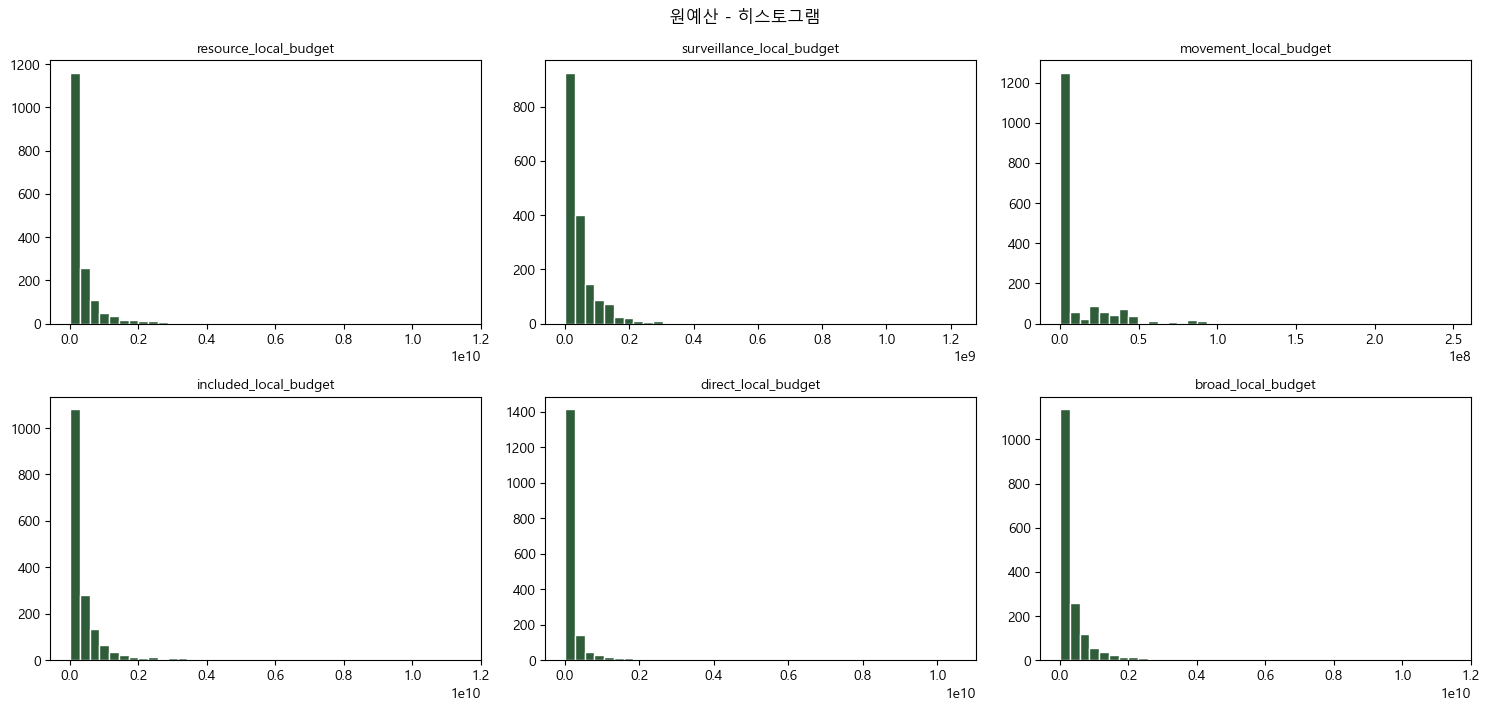

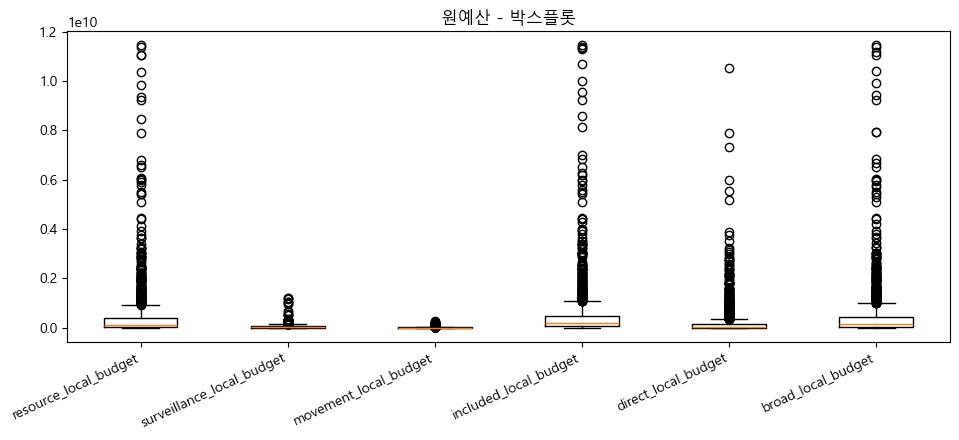

In [18]:
_ = univariate_table(RAW_BUDGET_COLS, "원예산")
plot_hist_box(RAW_BUDGET_COLS, "원예산")

=== ha당 예산: 분위수 / 왜도 / 0비율 / IQR이상치 ===


,변수,Q1,중앙값,Q3,왜도,0비율,IQR이상치수,IQR이상치비율
0,resource_budget_per_pine_ha,"10,988.0669","39,711.3218","171,374.6274",7.5853,0.0842,279,0.1655
1,surveillance_budget_per_pine_ha,0.0000,"3,856.1164","20,686.9679",13.5624,0.3671,306,0.1815
2,movement_budget_per_pine_ha,0.0000,0.0000,"1,242.6474",8.8047,0.7224,276,0.1637


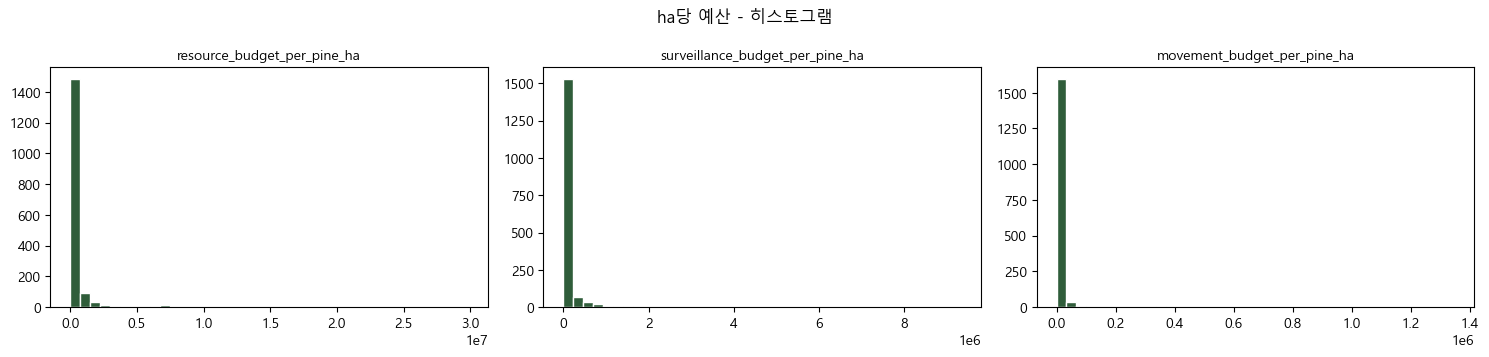

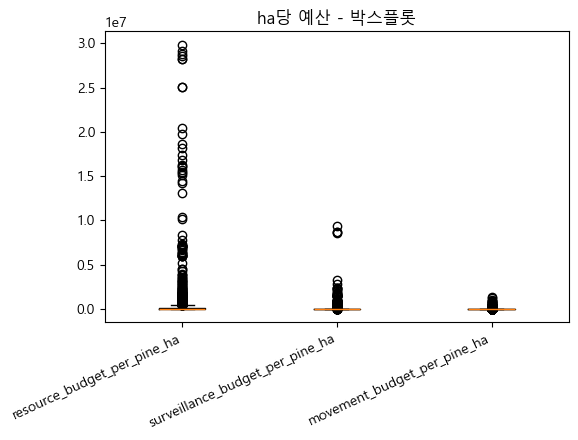

In [19]:
_ = univariate_table(PER_HA_COLS, "ha당 예산")
plot_hist_box(PER_HA_COLS, "ha당 예산")

=== 로그 ha당 예산: 분위수 / 왜도 / 0비율 / IQR이상치 ===


,변수,Q1,중앙값,Q3,왜도,0비율,IQR이상치수,IQR이상치비율
0,log_resource_budget_per_pine_ha,9.3047,10.5894,12.0516,-1.5286,0.0842,166,0.0985
1,log_surveillance_budget_per_pine_ha,0.0000,8.2577,9.9373,-0.2228,0.3671,0,0.0000
2,log_movement_budget_per_pine_ha,0.0000,0.0000,7.1257,1.1908,0.7224,0,0.0000


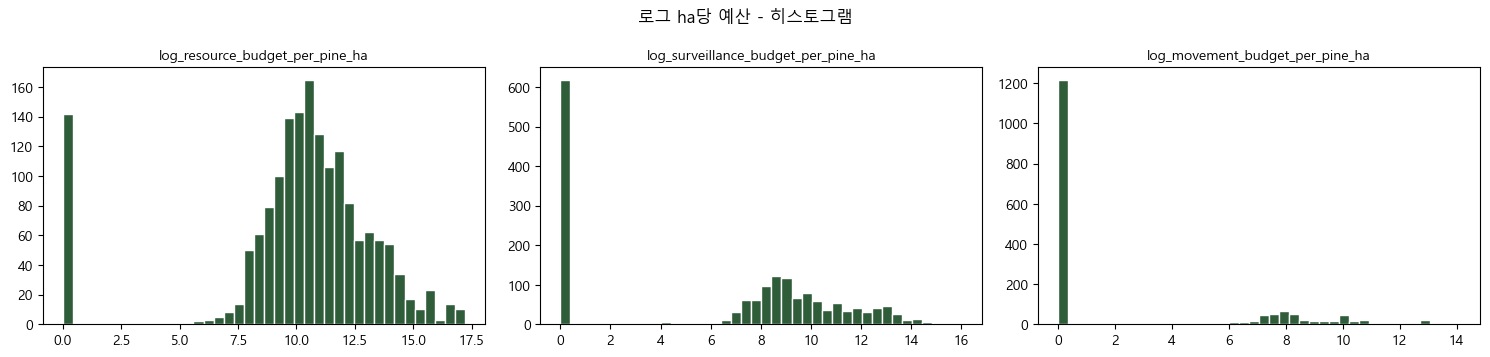

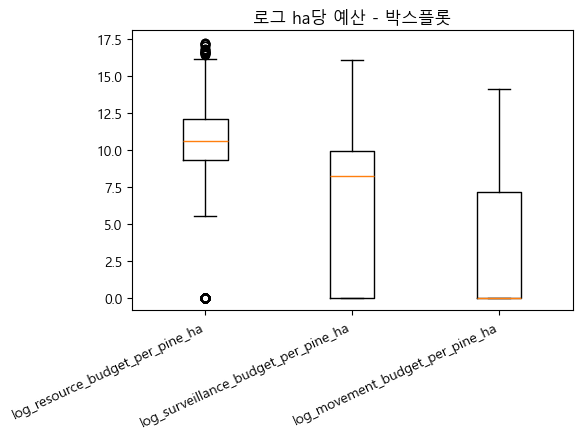

In [20]:
_ = univariate_table(LOG_COLS, "로그 ha당 예산")
plot_hist_box(LOG_COLS, "로그 ha당 예산")

=== 예산 구성비: 분위수 / 왜도 / 0비율 / IQR이상치 ===


,변수,Q1,중앙값,Q3,왜도,0비율,IQR이상치수,IQR이상치비율
0,surveillance_share,0.0000,0.1237,0.3312,1.2985,0.3125,57,0.0367
1,movement_share_included_budget,0.0000,0.0000,0.0235,4.0539,0.6985,262,0.1688
2,movement_share_broad_budget,0.0000,0.0000,0.0272,3.7907,0.6969,264,0.1710


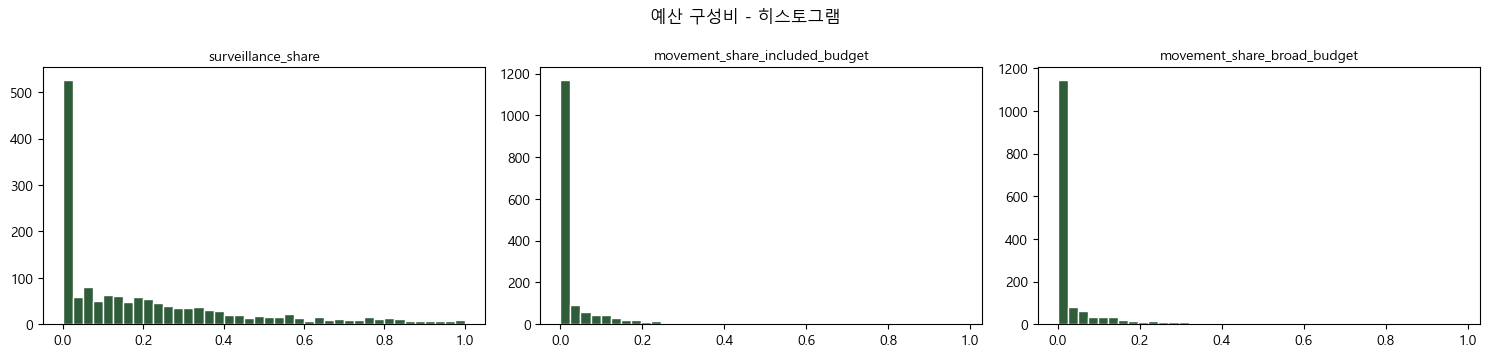

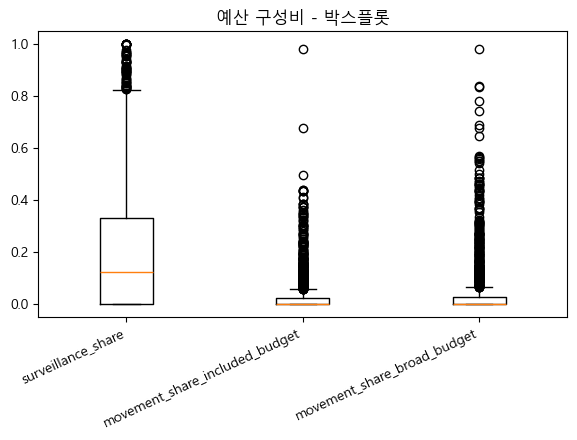

In [21]:
_ = univariate_table(SHARE_COLS, "예산 구성비")
plot_hist_box(SHARE_COLS, "예산 구성비")

=== 발생/재발생 변수: 분위수 / 왜도 / 0비율 / IQR이상치 ===


,변수,Q1,중앙값,Q3,왜도,0비율,IQR이상치수,IQR이상치비율
0,prev_infected_sites,0.0000,0.0000,71.2500,8.1112,0.5171,361,0.2063
1,current_infected_sites,0.0000,0.0000,55.2500,8.5043,0.5340,416,0.2080
2,recurrent_sites_300m,0.0000,0.0000,17.0000,8.6124,0.6491,365,0.2086
3,recurrence_rate_300m,0.0000,0.3750,0.7143,0.2349,0.2734,0,0.0000
4,new_site_share_300m,0.3334,0.6665,1.0000,-0.3580,0.0266,0,0.0000


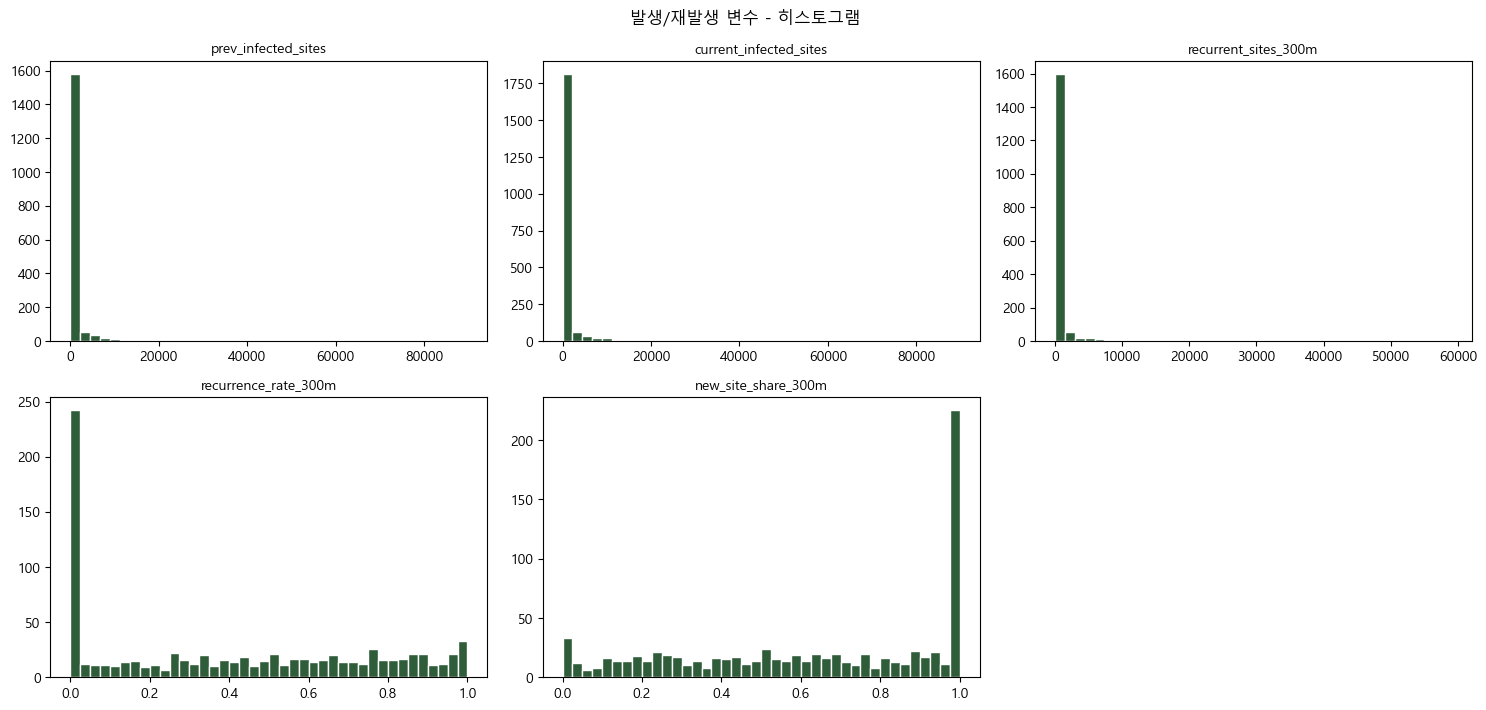

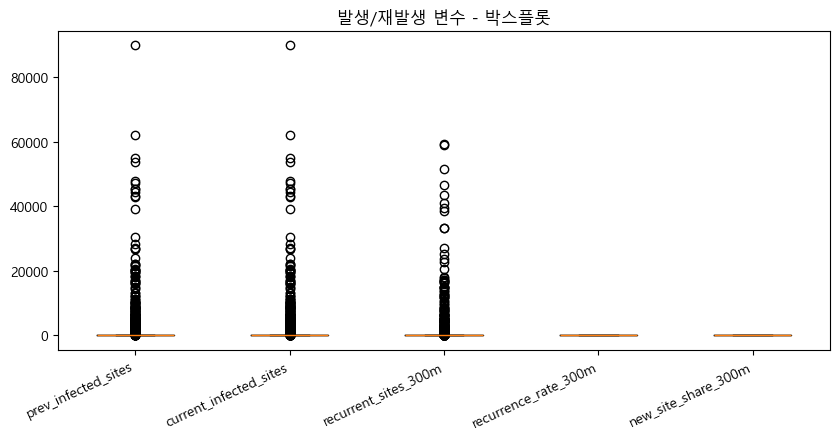

In [22]:
_ = univariate_table(OCCUR_COLS, "발생/재발생 변수")
plot_hist_box(OCCUR_COLS, "발생/재발생 변수")

**결과에서 확인해야 할 사항**
- 원예산은 극단적 우측 비대칭(왜도 매우 큼)을 보이는지, ha당 예산·로그 변수로 갈수록 완화되는지
- 구성비 변수(0~1 범위)의 0 비율이 얼마나 높은지 (특히 movement 계열)
- 발생변수(사이트 수, 비율)의 분포 형태와 0 비율

**결과 해석 기준**
- 원예산처럼 왜도가 극단적으로 크고 IQR 이상치 비율이 높은 변수는 지역 규모(시군구 면적·산림면적)
  효과가 섞여 있을 가능성이 높으므로 6단계(규모효과 분석)에서 별도로 검증해야 한다.
- 구성비 변수는 0~1로 유계(bounded)이므로 왜도·IQR 이상치 기준을 원예산과 동일하게 적용하면 과도하게
  많은 "이상치"가 잡힐 수 있어 해석에 주의가 필요하다.

**다음 단계에 미치는 영향**
- 원예산의 극단적 비대칭은 5단계 산식 검증, 6단계 규모효과 분석, 7단계 raw-log 비교로 이어진다.

## 5단계. 파생변수 산식 검증

**분석 목적**: 패널에 포함된 파생변수(구성비, 로그, ha당 예산, 재발생 변수)가 문서화된 산식대로
정확히 계산되었는지 재계산하여 검증한다. 0으로 나누는 경우와 분모가 결측인 경우는 먼저 분리하고,
오류가 발견되어도 임의로 수정하지 않고 불일치 행 수와 대표 사례만 보고한다.

In [23]:
# (1) included_local_budget = resource + surveillance + movement
calc_included = df["resource_local_budget"] + df["surveillance_local_budget"] + df["movement_local_budget"]
diff_included = (calc_included - df["included_local_budget"]).abs()
mismatch_included = diff_included > 1  # 1원 이상 차이만 불일치로 간주(부동소수 오차 배제)
print("included_local_budget 불일치 행수:", int(mismatch_included.sum()), "/", len(df))
if mismatch_included.any():
    display(df.loc[mismatch_included, ["year", "sigungu_full_nm", "resource_local_budget",
                                        "surveillance_local_budget", "movement_local_budget",
                                        "included_local_budget"]].head(10))

included_local_budget 불일치 행수: 0 / 2000


In [24]:
# (2) ha당 예산 = 원예산 / pine_area_ha_2024 (단, pine_area_positive==1인 행만 정의됨)
for raw_col, per_ha_col in zip(
    ["resource_local_budget", "surveillance_local_budget", "movement_local_budget"], PER_HA_COLS
):
    valid = (df["pine_area_positive"] == 1) & df[per_ha_col].notna()
    n_valid = int(valid.sum())
    calc = df.loc[valid, raw_col] / df.loc[valid, "pine_area_ha_2024"]
    diff = (calc - df.loc[valid, per_ha_col]).abs()
    rel_tol = 1e-6 * (df.loc[valid, per_ha_col].abs() + 1)
    mismatch = diff > rel_tol
    print(f"[{per_ha_col}] 계산가능행수={n_valid}, 산식 불일치 행수={int(mismatch.sum())}")

    # 분모가 없거나(면적 비양수) 결측인 경우는 별도 카운트
    denom_zero_or_na = (df["pine_area_positive"] == 0) | df["pine_area_ha_2024"].isna()
    print(f"   -> 분모없음/비양수로 정의상 계산불가 행수={int(denom_zero_or_na.sum())}")

[resource_budget_per_pine_ha] 계산가능행수=1686, 산식 불일치 행수=0
   -> 분모없음/비양수로 정의상 계산불가 행수=24
[surveillance_budget_per_pine_ha] 계산가능행수=1686, 산식 불일치 행수=0
   -> 분모없음/비양수로 정의상 계산불가 행수=24
[movement_budget_per_pine_ha] 계산가능행수=1686, 산식 불일치 행수=0
   -> 분모없음/비양수로 정의상 계산불가 행수=24


In [25]:
# (3) 로그변수 = log1p(ha당 예산)
for log_col, per_ha_col in zip(LOG_COLS, PER_HA_COLS):
    valid = df[per_ha_col].notna() & df[log_col].notna()
    calc = np.log1p(df.loc[valid, per_ha_col])
    diff = (calc - df.loc[valid, log_col]).abs()
    mismatch = diff > 1e-6
    print(f"[{log_col}] = log1p({per_ha_col}) 불일치 행수:", int(mismatch.sum()), "/", int(valid.sum()))

[log_resource_budget_per_pine_ha] = log1p(resource_budget_per_pine_ha) 불일치 행수: 0 / 1686
[log_surveillance_budget_per_pine_ha] = log1p(surveillance_budget_per_pine_ha) 불일치 행수: 0 / 1686
[log_movement_budget_per_pine_ha] = log1p(movement_budget_per_pine_ha) 불일치 행수: 0 / 1686


In [26]:
# (4) 구성비 변수 산식 확인
# surveillance_share = surveillance_local_budget / included_local_budget
valid = df["included_local_budget"].notna() & (df["included_local_budget"] != 0) & df["surveillance_share"].notna()
calc = df.loc[valid, "surveillance_local_budget"] / df.loc[valid, "included_local_budget"]
diff = (calc - df.loc[valid, "surveillance_share"]).abs()
print("surveillance_share 불일치 행수:", int((diff > 1e-6).sum()), "/", int(valid.sum()))
print("  included_local_budget==0 행수:", int((df['included_local_budget'] == 0).sum()),
      " / 결측 행수:", int(df['included_local_budget'].isna().sum()))

# movement_share_included_budget = movement_local_budget / included_local_budget
valid = df["included_local_budget"].notna() & (df["included_local_budget"] != 0) & df["movement_share_included_budget"].notna()
calc = df.loc[valid, "movement_local_budget"] / df.loc[valid, "included_local_budget"]
diff = (calc - df.loc[valid, "movement_share_included_budget"]).abs()
print("\nmovement_share_included_budget 불일치 행수:", int((diff > 1e-6).sum()), "/", int(valid.sum()))

# movement_share_broad_budget = movement_local_budget / broad_local_budget
valid = df["broad_local_budget"].notna() & (df["broad_local_budget"] != 0) & df["movement_share_broad_budget"].notna()
calc = df.loc[valid, "movement_local_budget"] / df.loc[valid, "broad_local_budget"]
diff = (calc - df.loc[valid, "movement_share_broad_budget"]).abs()
print("\nmovement_share_broad_budget 불일치 행수:", int((diff > 1e-6).sum()), "/", int(valid.sum()))
print("  broad_local_budget==0 행수:", int((df['broad_local_budget'] == 0).sum()),
      " / 결측 행수:", int(df['broad_local_budget'].isna().sum()))

surveillance_share 불일치 행수: 0 / 1552
  included_local_budget==0 행수: 158  / 결측 행수: 290

movement_share_included_budget 불일치 행수: 0 / 1552

movement_share_broad_budget 불일치 행수: 0 / 1544
  broad_local_budget==0 행수: 166  / 결측 행수: 290


In [27]:
# (5) 재발생 변수 정의 및 계산 가능 범위
# recurrence_rate_300m = recurrent_sites_300m / prev_infected_sites (prev_infected_sites>0 인 경우만 정의)
valid = df["prev_infected_sites"].notna() & (df["prev_infected_sites"] > 0) & df["recurrence_rate_300m"].notna()
calc = df.loc[valid, "recurrent_sites_300m"] / df.loc[valid, "prev_infected_sites"]
diff = (calc - df.loc[valid, "recurrence_rate_300m"]).abs()
print("recurrence_rate_300m 산식 불일치 행수:", int((diff > 1e-9).sum()), "/ 계산가능행수:", int(valid.sum()))

zero_denom = (df["prev_infected_sites"] == 0) & df["recurrence_rate_300m"].notna()
print("prev_infected_sites==0 인데 recurrence_rate_300m이 NA가 아닌 행수(있으면 안 됨):", int(zero_denom.sum()))

na_denom = df["prev_infected_sites"].isna() & df["recurrence_rate_300m"].notna()
print("prev_infected_sites가 NA인데 recurrence_rate_300m이 NA가 아닌 행수(있으면 안 됨):", int(na_denom.sum()))

print("\n※ new_site_share_300m의 분자(신규발생지 수)는 최종패널에 원자료로 포함되어 있지 않아")
print("   이 패널만으로는 분자를 재계산해 검증할 수 없다. 여기서는 정의(신규발생지수/당해발생지수)와")
print("   범위(0~1), 결측패턴만 검증한다.")
out_of_range = df["new_site_share_300m"].dropna()
print("new_site_share_300m 범위 이탈(0~1 밖) 행수:", int(((out_of_range < 0) | (out_of_range > 1)).sum()))
zero_cur = (df["current_infected_sites"] == 0) & df["new_site_share_300m"].notna()
print("current_infected_sites==0 인데 new_site_share_300m이 NA가 아닌 행수(있으면 안 됨):", int(zero_cur.sum()))

recurrence_rate_300m 산식 불일치 행수: 0 / 계산가능행수: 845
prev_infected_sites==0 인데 recurrence_rate_300m이 NA가 아닌 행수(있으면 안 됨): 0
prev_infected_sites가 NA인데 recurrence_rate_300m이 NA가 아닌 행수(있으면 안 됨): 0

※ new_site_share_300m의 분자(신규발생지 수)는 최종패널에 원자료로 포함되어 있지 않아
   이 패널만으로는 분자를 재계산해 검증할 수 없다. 여기서는 정의(신규발생지수/당해발생지수)와
   범위(0~1), 결측패턴만 검증한다.
new_site_share_300m 범위 이탈(0~1 밖) 행수: 0
current_infected_sites==0 인데 new_site_share_300m이 NA가 아닌 행수(있으면 안 됨): 0


**결과에서 확인해야 할 사항**
- 6개 산식(included 합계, ha당 예산 3개, 로그 3개, 구성비 3개, recurrence_rate_300m)의 불일치 행수가
  모두 0인지
- 0으로 나누는 경우(분모=0)와 분모가 결측인 경우가 몇 건씩 있으며, 그 행들이 NA로 올바르게 처리됐는지
- `new_site_share_300m`처럼 최종패널만으로는 분자를 재계산할 수 없어 "정의 검증"이 아니라 "범위·결측
  패턴 검증"에 그치는 변수가 있다는 점

**결과 해석 기준**
- 불일치 행수가 0이면 파생변수가 문서화된 산식대로 정확히 생성된 것으로 간주하고 이후 단계에서
  안심하고 사용할 수 있다.
- 불일치가 발견되면 절대 임의로 값을 고치지 말고 불일치 행의 목록과 패턴(특정 연도/시군구 집중 여부)을
  먼저 보고해야 한다.

**다음 단계에 미치는 영향**
- 산식이 검증된 변수만 6~13단계의 상관/회귀성 탐색에 신뢰성 있게 사용할 수 있다.

## 6단계. 예산 규모효과 분석

**분석 목적**: 원예산이 단순히 시군구의 소나무림 면적(규모) 차이를 반영하는 것인지, ha당 예산으로
정규화했을 때 순위가 달라지는지 확인한다.

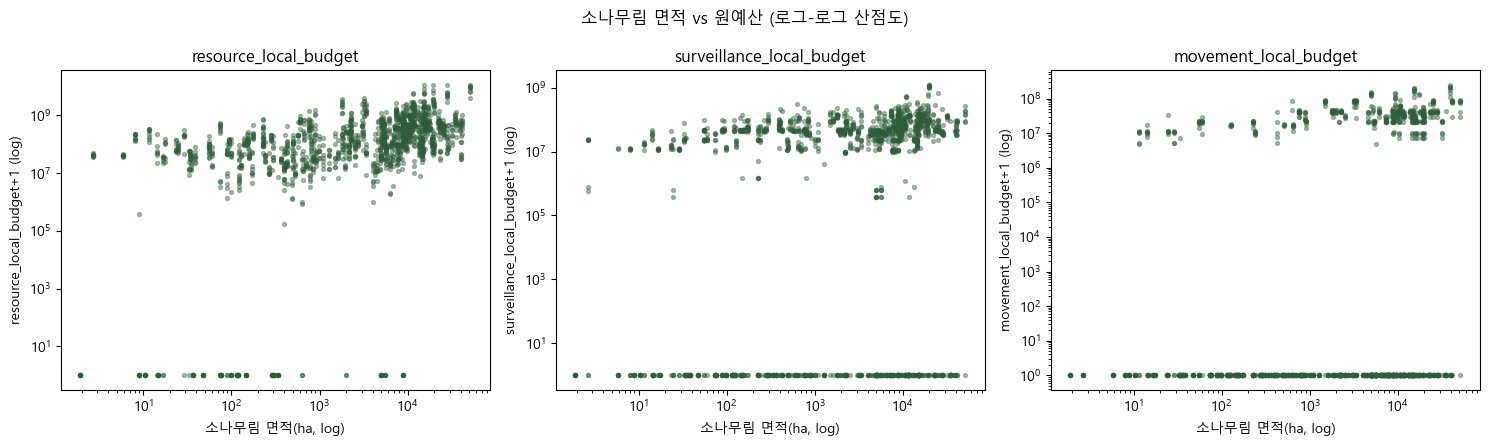

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["resource_local_budget", "surveillance_local_budget", "movement_local_budget"]):
    sub = df[["pine_area_ha_2024", col]].dropna()
    sub = sub[(sub["pine_area_ha_2024"] > 0)]
    ax.scatter(sub["pine_area_ha_2024"], sub[col] + 1, s=8, alpha=0.4, color="#2f5d3a")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("소나무림 면적(ha, log)"); ax.set_ylabel(f"{col}+1 (log)")
    ax.set_title(col)
plt.suptitle("소나무림 면적 vs 원예산 (로그-로그 산점도)")
plt.tight_layout()
plt.show()

In [29]:
rows = []
for col in RAW_BUDGET_COLS[:3]:
    sub = df[["pine_area_ha_2024", col]].dropna()
    pear_r, pear_p = stats.pearsonr(sub["pine_area_ha_2024"], sub[col])
    spear_r, spear_p = stats.spearmanr(sub["pine_area_ha_2024"], sub[col])
    rows.append([col, pear_r, pear_p, spear_r, spear_p, len(sub)])
corr_area = pd.DataFrame(rows, columns=["변수", "Pearson_r", "Pearson_p", "Spearman_rho", "Spearman_p", "n"])
print("소나무림 면적과 원예산의 상관:")
display(corr_area)

소나무림 면적과 원예산의 상관:


,변수,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,n
0,resource_local_budget,0.3995,0.0000,0.5818,0.0000,1710
1,surveillance_local_budget,0.2138,0.0000,0.2970,0.0000,1710
2,movement_local_budget,0.3129,0.0000,0.2889,0.0000,1710


In [30]:
# 소나무림 면적 분위수별 원예산 분포
df["_area_quartile"] = pd.qcut(df["pine_area_ha_2024"], 4, labels=["Q1(최소)", "Q2", "Q3", "Q4(최대)"], duplicates="drop")
print("면적 분위수별 원예산 중앙값:")
display(df.groupby("_area_quartile", observed=True)[["resource_local_budget", "surveillance_local_budget", "movement_local_budget"]].median())

면적 분위수별 원예산 중앙값:


,resource_local_budget,surveillance_local_budget,movement_local_budget
_area_quartile,,,
Q1(최소),"38,106,500.0000",0.0000,0.0000
Q2,"53,574,000.0000","31,930,500.0000",0.0000
Q3,"154,441,000.0000","32,198,000.0000",0.0000
Q4(최대),"404,348,000.0000","42,464,000.0000",0.0000


In [31]:
# 원예산 순위 vs ha당예산 순위 비교 (같은 해 안에서, 예: 2023년 기준)
YEAR_REF = 2023
sub = df[df["year"] == YEAR_REF][["sigungu_full_nm", "resource_local_budget", "resource_budget_per_pine_ha", "pine_area_ha_2024"]].dropna()
rho, p = stats.spearmanr(sub["resource_local_budget"], sub["resource_budget_per_pine_ha"])
print(f"{YEAR_REF}년 기준, 원예산 순위 vs ha당예산 순위 Spearman rho = {rho:.4f} (p={p:.4g}, n={len(sub)})")

top10_raw = sub.nlargest(10, "resource_local_budget")
top10_perha = sub.nlargest(10, "resource_budget_per_pine_ha")
print(f"\n[{YEAR_REF}] 원예산 상위 10개 시군구:")
display(top10_raw)
print(f"\n[{YEAR_REF}] ha당예산 상위 10개 시군구:")
display(top10_perha)

overlap = set(top10_raw["sigungu_full_nm"]) & set(top10_perha["sigungu_full_nm"])
print(f"\n두 상위 10개 목록의 중복 지역 수: {len(overlap)}개 ->", overlap)

2023년 기준, 원예산 순위 vs ha당예산 순위 Spearman rho = 0.4936 (p=2.348e-14, n=211)

[2023] 원예산 상위 10개 시군구:


,sigungu_full_nm,resource_local_budget,resource_budget_per_pine_ha,pine_area_ha_2024
1937,경상북도 경주시,"11,387,899,450.0000","401,867.1881","28,337.4702"
1939,경상북도 안동시,"11,073,379,000.0000","214,045.1443","51,733.8482"
1967,경상남도 밀양시,"11,034,982,778.0000","568,391.4349","19,414.4072"
1824,울산광역시 울주군,"6,044,438,000.0000","397,736.6411","15,197.0861"
1940,경상북도 구미시,"5,797,952,000.0000","505,099.2612","11,478.8368"
1866,경기도 가평군,"3,207,248,000.0000","230,533.9094","13,912.2614"
1861,경기도 광주시,"3,202,371,000.0000","1,758,104.1640","1,821.4911"
1914,전라남도 여수시,"3,016,395,000.0000","272,900.6342","11,053.0890"
1975,경상남도 하동군,"2,842,941,970.0000","189,992.7684","14,963.4220"
1969,경상남도 양산시,"2,778,287,000.0000","377,119.9975","7,367.1166"



[2023] ha당예산 상위 10개 시군구:


,sigungu_full_nm,resource_local_budget,resource_budget_per_pine_ha,pine_area_ha_2024
1766,서울특별시 구로구,"343,018,000.0000","29,853,708.0300",11.4900
1763,서울특별시 마포구,"201,741,000.0000","25,056,393.4500",8.0515
1753,서울특별시 성동구,"48,143,000.0000","18,200,145.6600",2.6452
1765,서울특별시 강서구,"302,997,000.0000","10,426,226.2000",29.0610
1771,서울특별시 서초구,"532,533,000.0000","7,184,960.5480",74.1177
1751,서울특별시 중구,"42,074,000.0000","7,160,581.9060",5.8758
1773,서울특별시 송파구,"90,400,000.0000","6,286,942.2810",14.3790
1802,인천광역시 미추홀구,"111,244,000.0000","6,280,909.6050",17.7114
1767,서울특별시 금천구,"144,011,000.0000","6,080,084.2320",23.6857
1850,경기도 군포시,"198,296,000.0000","3,560,382.4620",55.6951



두 상위 10개 목록의 중복 지역 수: 0개 -> set()


In [32]:
# 분모(면적)가 작은 지역에서 ha당 예산이 비정상적으로 커지는지
small_area_th = df["pine_area_ha_2024"].quantile(0.05)
small_area = df[(df["pine_area_ha_2024"] > 0) & (df["pine_area_ha_2024"] <= small_area_th)]
print(f"소나무림 면적 하위 5%(<= {small_area_th:.2f}ha) 시군구x연도 중 ha당예산 상위 10건:")
display(small_area.sort_values("resource_budget_per_pine_ha", ascending=False)
        [["year", "sigungu_full_nm", "pine_area_ha_2024", "resource_local_budget", "resource_budget_per_pine_ha"]].head(10))

소나무림 면적 하위 5%(<= 14.62ha) 시군구x연도 중 ha당예산 상위 10건:


,year,sigungu_full_nm,pine_area_ha_2024,resource_local_budget,resource_budget_per_pine_ha
1766,2023,서울특별시 구로구,11.4900,"343,018,000.0000","29,853,708.0300"
1263,2021,서울특별시 마포구,8.0515,"234,073,000.0000","29,072,053.6900"
1513,2022,서울특별시 마포구,8.0515,"232,229,000.0000","28,843,027.4200"
1266,2021,서울특별시 구로구,11.4900,"327,614,000.0000","28,513,059.6700"
763,2019,서울특별시 마포구,8.0515,"227,433,000.0000","28,247,360.3900"
1516,2022,서울특별시 구로구,11.4900,"323,984,000.0000","28,197,131.7600"
1763,2023,서울특별시 마포구,8.0515,"201,741,000.0000","25,056,393.4500"
1016,2020,서울특별시 구로구,11.4900,"287,598,000.0000","25,030,367.8600"
1013,2020,서울특별시 마포구,8.0515,"164,751,000.0000","20,462,205.8900"
766,2019,서울특별시 구로구,11.4900,"226,465,000.0000","19,709,811.1200"


**결과에서 확인해야 할 사항**
- 원예산과 소나무림 면적의 상관이 얼마나 강한지(양의 상관이 강하면 규모효과가 크다는 의미)
- 원예산 상위 지역과 ha당예산 상위 지역이 얼마나 겹치는지(적게 겹칠수록 정규화의 효과가 크다는 의미)
- 면적이 매우 작은 지역에서 ha당예산이 비정상적으로 튀는 사례가 있는지(작은 분모 문제)

**결과 해석 기준**
- 원예산-면적 상관이 강한데 원예산-ha당예산 순위가 크게 달라진다면, 원예산 자체는 "지자체가
  얼마나 많이 썼는가"보다 "산림이 얼마나 큰가"를 더 많이 반영하는 지표일 수 있다.
- 면적 하위 5%에서 ha당예산이 극단적으로 큰 사례가 몰려 있다면, 이는 대응역량이 실제로 높아서가
  아니라 분모가 작아 생기는 통계적 현상일 가능성을 14단계(이상치 분석)에서 별도로 검토해야 한다.

**다음 단계에 미치는 영향**
- 이 결과는 7단계(raw vs log 비교), 13단계(예산-성과 관계), 16단계(지수 변수 선정)에서 "원예산이 아닌
  ha당예산·로그변수를 지수 후보로 우선 고려해야 하는 근거"로 사용된다.

## 7단계. raw ha당 예산과 로그 변수 비교

**분석 목적**: log1p 변환이 극단값의 영향을 얼마나 완화하면서도 지역 간 상대적 정보(순위)를
유지하는지 정량적으로 평가한다.

In [33]:
rows = []
for raw_col, log_col in zip(PER_HA_COLS, LOG_COLS):
    s_raw = df[raw_col].dropna()
    s_log = df[log_col].dropna()

    q1, q3 = s_raw.quantile([0.25, 0.75]); iqr = q3 - q1
    out_raw = int(((s_raw < q1 - 1.5 * iqr) | (s_raw > q3 + 1.5 * iqr)).sum())
    q1l, q3l = s_log.quantile([0.25, 0.75]); iqrl = q3l - q1l
    out_log = int(((s_log < q1l - 1.5 * iqrl) | (s_log > q3l + 1.5 * iqrl)).sum())

    sub = df[[raw_col, log_col]].dropna()
    rho, p = stats.spearmanr(sub[raw_col], sub[log_col])

    rows.append([
        raw_col, s_raw.mean(), s_raw.median(), s_raw.skew(), s_raw.quantile(0.95), s_raw.quantile(0.99), out_raw,
        s_log.mean(), s_log.median(), s_log.skew(), out_log, rho,
    ])

compare_df = pd.DataFrame(rows, columns=[
    "변수", "원값_평균", "원값_중앙값", "원값_왜도", "원값_95pct", "원값_99pct", "원값_IQR이상치수",
    "로그_평균", "로그_중앙값", "로그_왜도", "로그_IQR이상치수", "원값-로그_순위상관(Spearman)",
])
display(compare_df)
print("\n※ log1p는 단조변환이므로 원값-로그값 순위상관은 정의상 1에 가깝다(순위 자체는 보존).")
print("   log 변환의 실질적 효과는 왜도·IQR이상치수 감소, 즉 분포 형태의 개선에 있다.")

,변수,원값_평균,원값_중앙값,원값_왜도,원값_95pct,원값_99pct,원값_IQR이상치수,로그_평균,로그_중앙값,로그_왜도,로그_IQR이상치수,원값-로그_순위상관(Spearman)
0,resource_budget_per_pine_ha,"616,291.8069","39,711.3218",7.5853,"1,894,088.0625","15,740,287.6060",279,10.1239,10.5894,-1.5286,166,1.0000
1,surveillance_budget_per_pine_ha,"98,923.5938","3,856.1164",13.5624,"473,557.9643","1,600,227.5828",306,6.1935,8.2577,-0.2228,0,1.0000
2,movement_budget_per_pine_ha,"15,568.6126",0.0000,8.8047,"37,234.8660","429,856.1261",276,2.4777,0.0000,1.1908,0,1.0000



※ log1p는 단조변환이므로 원값-로그값 순위상관은 정의상 1에 가깝다(순위 자체는 보존).
   log 변환의 실질적 효과는 왜도·IQR이상치수 감소, 즉 분포 형태의 개선에 있다.


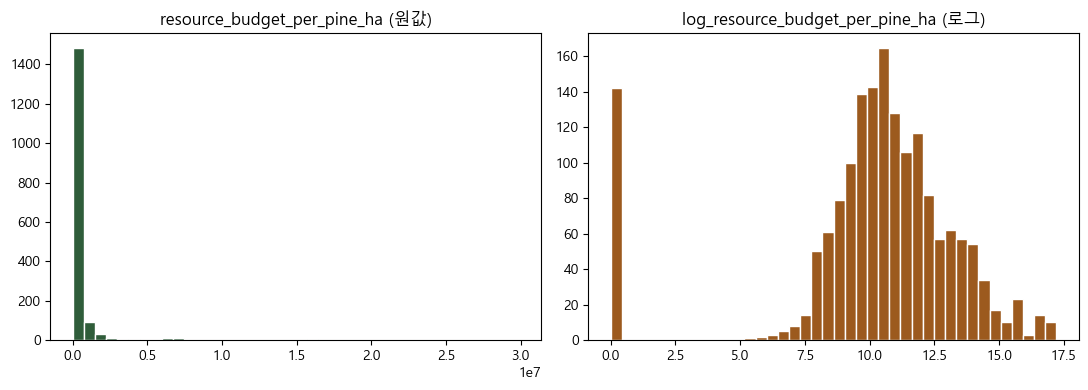

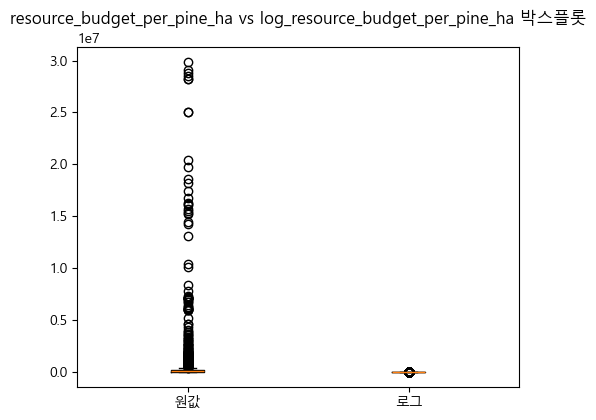

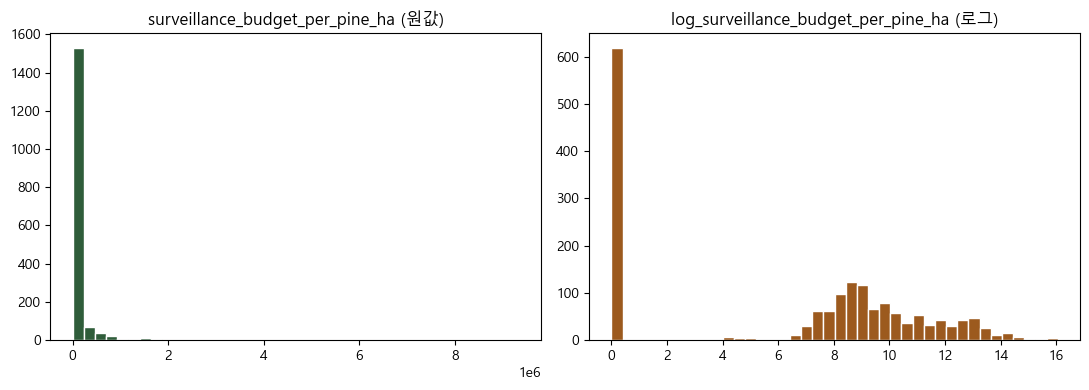

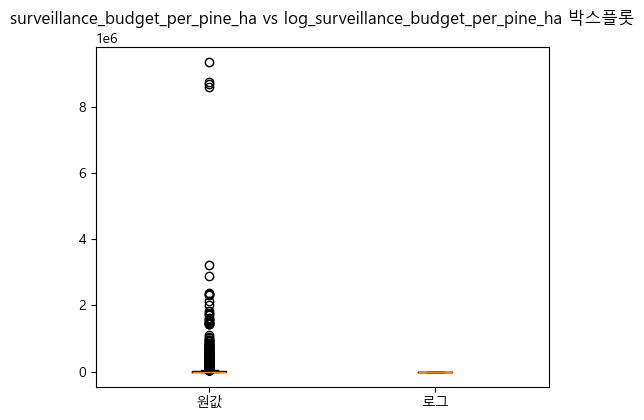

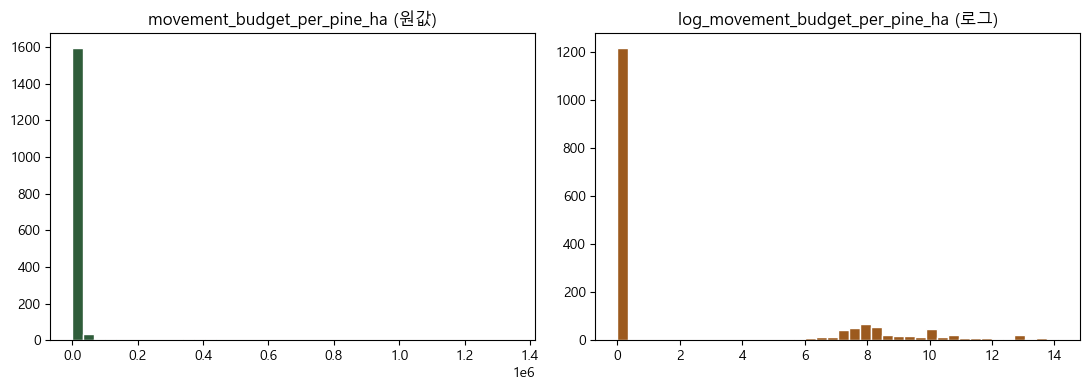

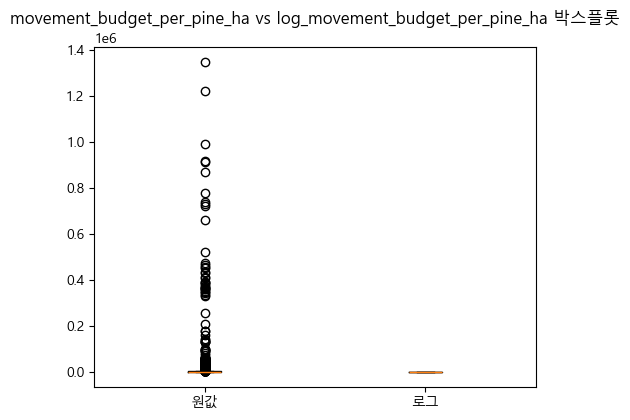

In [34]:
for raw_col, log_col in zip(PER_HA_COLS, LOG_COLS):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(df[raw_col].dropna(), bins=40, color="#2f5d3a", edgecolor="white")
    axes[0].set_title(f"{raw_col} (원값)")
    axes[1].hist(df[log_col].dropna(), bins=40, color="#9c5a1e", edgecolor="white")
    axes[1].set_title(f"{log_col} (로그)")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 4.3))
    ax.boxplot([df[raw_col].dropna(), df[log_col].dropna()], tick_labels=["원값", "로그"])
    ax.set_title(f"{raw_col} vs {log_col} 박스플롯")
    plt.tight_layout()
    plt.show()

**결과에서 확인해야 할 사항**
- 로그 변환 후 왜도가 원값 대비 얼마나 줄어드는지
- 로그 변환 후 IQR 기준 이상치 수가 얼마나 줄어드는지
- 순위상관이 1에 가까움을 확인해 "정보 손실 없이 분포만 개선"되었음을 검증

**결과 해석 기준**
- 왜도가 큰 폭으로 줄고 IQR 이상치 수가 감소하면 로그변환이 통계적으로 유효한 처리라고 판단한다.
- 순위상관이 1에 가깝다는 것은 로그변환이 "어느 지역이 높고 낮은지"의 순서 자체는 바꾸지 않는다는
  뜻이며, 이는 로그변환이 정보를 왜곡하지 않는 안전한 처리임을 시사한다.

**다음 단계에 미치는 영향**
- 왜도·이상치가 충분히 개선된 로그 변수는 8~13단계의 상관/시계열 분석과 16단계 지수 후보 선정에서
  원값보다 우선적으로 고려한다.

## 8단계. 연도별 변화 분석

**분석 목적**: 주요 변수의 연도별 추이를 확인해 뚜렷한 구조적 변화(제도 변경, 자료 기준 변경 등)가
의심되는 연도가 있는지 살펴본다.

In [35]:
YEAR_TREND_COLS = LOG_COLS + SHARE_COLS + OCCUR_COLS
year_mean = df.groupby("year")[YEAR_TREND_COLS].mean()
year_median = df.groupby("year")[YEAR_TREND_COLS].median()
print("연도별 평균:")
display(year_mean)
print("\n연도별 중앙값:")
display(year_median)

연도별 평균:


,log_resource_budget_per_pine_ha,log_surveillance_budget_per_pine_ha,log_movement_budget_per_pine_ha,surveillance_share,movement_share_included_budget,movement_share_broad_budget,prev_infected_sites,current_infected_sites,recurrent_sites_300m,recurrence_rate_300m,new_site_share_300m
year,,,,,,,,,,,
2016,9.9273,0.7663,0.0412,0.0229,0.0014,0.0024,NaN,"1,271.0400",NaN,NaN,NaN
2017,9.9492,6.8913,2.5376,0.3212,0.0228,0.0387,"1,271.0400","1,755.6800",953.5320,0.4240,0.7448
2018,10.1318,6.4856,2.7518,0.2092,0.0343,0.0425,"1,755.6800","1,333.3480","1,317.1960",0.3689,0.6187
2019,10.2064,6.9821,2.7004,0.2130,0.0323,0.0403,"1,333.3480","1,152.8320","1,018.4200",0.4094,0.6572
2020,10.1439,6.8548,2.8865,0.2212,0.0420,0.0545,"1,152.8320",957.3280,843.2600,0.3957,0.6618
2021,10.0046,7.0511,2.9113,0.2505,0.0412,0.0553,957.3280,980.9280,715.5920,0.4365,0.6071
2022,10.1952,7.2556,2.9497,0.2427,0.0394,0.0523,980.9280,"1,197.8720",673.3440,0.5470,0.5888
2023,10.4306,7.2384,3.0320,0.2160,0.0417,0.0554,"1,197.8720",471.0480,425.9200,0.2277,0.4637



연도별 중앙값:


,log_resource_budget_per_pine_ha,log_surveillance_budget_per_pine_ha,log_movement_budget_per_pine_ha,surveillance_share,movement_share_included_budget,movement_share_broad_budget,prev_infected_sites,current_infected_sites,recurrent_sites_300m,recurrence_rate_300m,new_site_share_300m
year,,,,,,,,,,,
2016,10.4063,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,NaN,NaN,NaN
2017,10.4463,8.9570,0.0000,0.2583,0.0000,0.0000,0.0000,0.0000,0.0000,0.4029,0.8207
2018,10.4201,8.2792,0.0000,0.1328,0.0000,0.0000,0.0000,0.0000,0.0000,0.3323,0.6899
2019,10.6337,8.4494,0.0000,0.1313,0.0000,0.0000,0.0000,0.0000,0.0000,0.3626,0.6933
2020,10.6353,8.3559,0.0000,0.1563,0.0000,0.0000,0.0000,1.0000,0.0000,0.3836,0.6744
2021,10.4438,8.7487,0.0000,0.2000,0.0000,0.0000,1.0000,0.0000,0.0000,0.4762,0.6154
2022,10.7500,8.6657,0.0000,0.1834,0.0000,0.0000,0.0000,1.5000,0.0000,0.6167,0.6402
2023,10.9912,8.7374,0.0000,0.1466,0.0000,0.0000,1.5000,0.0000,0.0000,0.0327,0.3865


In [36]:
year_sum = df.groupby("year")[RAW_BUDGET_COLS].sum()
print("연도별 원예산 합계:")
display(year_sum)

연도별 원예산 합계:


,resource_local_budget,surveillance_local_budget,movement_local_budget,included_local_budget,direct_local_budget,broad_local_budget
year,,,,,,
2016,"88,449,763,461.0000","717,195,000.0000","57,000,000.0000","89,223,958,461.0000","11,820,732,734.0000","89,007,293,461.0000"
2017,"79,862,053,232.0000","16,604,182,450.0000","1,960,835,000.0000","98,427,070,682.0000","39,221,730,003.0000","80,111,064,232.0000"
2018,"81,695,520,704.0000","8,435,290,757.0000","2,580,589,000.0000","92,711,400,461.0000","43,856,334,388.0000","83,680,031,704.0000"
2019,"95,420,026,792.0000","9,240,707,257.0000","2,671,920,000.0000","107,332,654,049.0000","55,028,352,692.0000","98,130,628,792.0000"
2020,"82,434,004,077.0000","9,066,467,460.0000","2,813,622,000.0000","94,314,093,537.0000","41,902,315,684.0000","85,311,942,077.0000"
2021,"70,879,585,052.0000","10,548,120,000.0000","2,870,850,000.0000","84,298,555,052.0000","31,855,729,217.0000","73,433,731,052.0000"
2022,"87,853,668,716.0000","11,269,027,000.0000","3,015,264,000.0000","102,137,959,716.0000","43,260,978,494.0000","90,900,633,716.0000"
2023,"138,360,460,690.0000","11,693,815,730.0000","3,208,519,000.0000","153,262,795,420.0000","72,810,462,338.0000","141,575,019,690.0000"


In [37]:
year_iqr = df.groupby("year")[PER_HA_COLS].apply(lambda g: g.quantile(0.75) - g.quantile(0.25))
print("연도별 ha당예산 사분위범위(IQR):")
display(year_iqr)

연도별 ha당예산 사분위범위(IQR):


,resource_budget_per_pine_ha,surveillance_budget_per_pine_ha,movement_budget_per_pine_ha
year,,,
2016,"167,651.6069",0.0000,0.0000
2017,"145,510.9495","43,374.1753",928.2636
2018,"160,832.0994","17,740.0656","1,685.2879"
2019,"167,045.3374","23,380.0160","1,579.6167"
2020,"135,248.7907","21,449.5050","1,763.7426"
2021,"129,078.8364","29,984.5897","1,915.9560"
2022,"155,845.3455","26,436.2962","1,937.7160"
2023,"224,017.4322","26,449.7911","2,633.6762"


In [38]:
zero_rate_by_year = df.groupby("year")[PER_HA_COLS + OCCUR_COLS].apply(lambda g: (g == 0).mean())
na_rate_by_year = df.groupby("year")[YEAR_TREND_COLS].apply(lambda g: g.isna().mean())
print("연도별 0비율:")
display(zero_rate_by_year)
print("\n연도별 결측률:")
display(na_rate_by_year)

연도별 0비율:


,resource_budget_per_pine_ha,surveillance_budget_per_pine_ha,movement_budget_per_pine_ha,prev_infected_sites,current_infected_sites,recurrent_sites_300m,recurrence_rate_300m,new_site_share_300m
year,,,,,,,,
2016,0.0800,0.7600,0.8360,0.0000,0.5760,0.0000,0.0000,0.0000
2017,0.0720,0.2720,0.5880,0.5760,0.5120,0.6640,0.0880,0.0000
2018,0.0640,0.2680,0.5800,0.5120,0.5480,0.6440,0.1320,0.0160
2019,0.0680,0.2360,0.5880,0.5480,0.5120,0.6520,0.1040,0.0080
2020,0.0720,0.2480,0.5760,0.5120,0.4920,0.6480,0.1360,0.0160
2021,0.0760,0.2400,0.5720,0.4920,0.5160,0.6280,0.1360,0.0160
2022,0.0680,0.2240,0.5680,0.5160,0.4640,0.6080,0.0920,0.0040
2023,0.0680,0.2280,0.5640,0.4640,0.6520,0.7000,0.2360,0.0280



연도별 결측률:


,log_resource_budget_per_pine_ha,log_surveillance_budget_per_pine_ha,log_movement_budget_per_pine_ha,surveillance_share,movement_share_included_budget,movement_share_broad_budget,prev_infected_sites,current_infected_sites,recurrent_sites_300m,recurrence_rate_300m,new_site_share_300m
year,,,,,,,,,,,
2016,0.1600,0.1600,0.1600,0.2400,0.2400,0.2400,1.0000,0.0000,1.0000,1.0000,1.0000
2017,0.1600,0.1600,0.1600,0.2280,0.2280,0.2320,0.0000,0.0000,0.0000,0.5760,0.5120
2018,0.1560,0.1560,0.1560,0.2200,0.2200,0.2200,0.0000,0.0000,0.0000,0.5120,0.5480
2019,0.1560,0.1560,0.1560,0.2200,0.2200,0.2240,0.0000,0.0000,0.0000,0.5480,0.5120
2020,0.1560,0.1560,0.1560,0.2200,0.2200,0.2280,0.0000,0.0000,0.0000,0.5120,0.4920
2021,0.1560,0.1560,0.1560,0.2240,0.2240,0.2320,0.0000,0.0000,0.0000,0.4920,0.5160
2022,0.1560,0.1560,0.1560,0.2200,0.2200,0.2240,0.0000,0.0000,0.0000,0.5160,0.4640
2023,0.1560,0.1560,0.1560,0.2200,0.2200,0.2240,0.0000,0.0000,0.0000,0.4640,0.6520


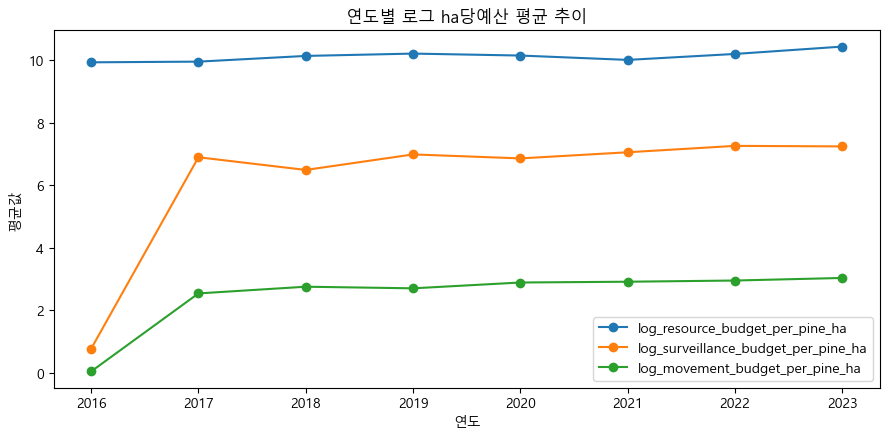

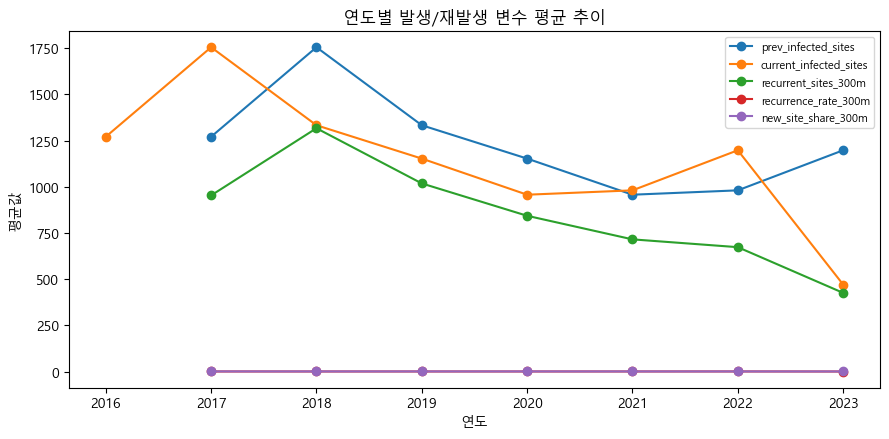

In [39]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in LOG_COLS:
    ax.plot(year_mean.index, year_mean[c], marker="o", label=c)
ax.set_title("연도별 로그 ha당예산 평균 추이")
ax.set_xlabel("연도"); ax.set_ylabel("평균값")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
for c in OCCUR_COLS:
    ax.plot(year_mean.index, year_mean[c], marker="o", label=c)
ax.set_title("연도별 발생/재발생 변수 평균 추이")
ax.set_xlabel("연도"); ax.set_ylabel("평균값")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

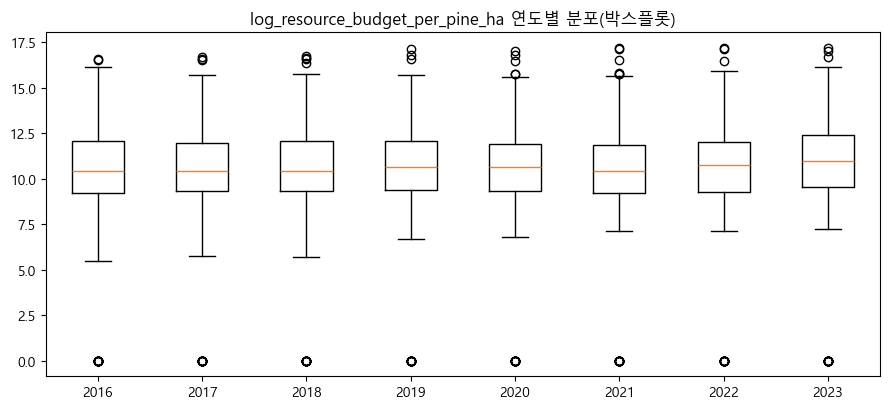

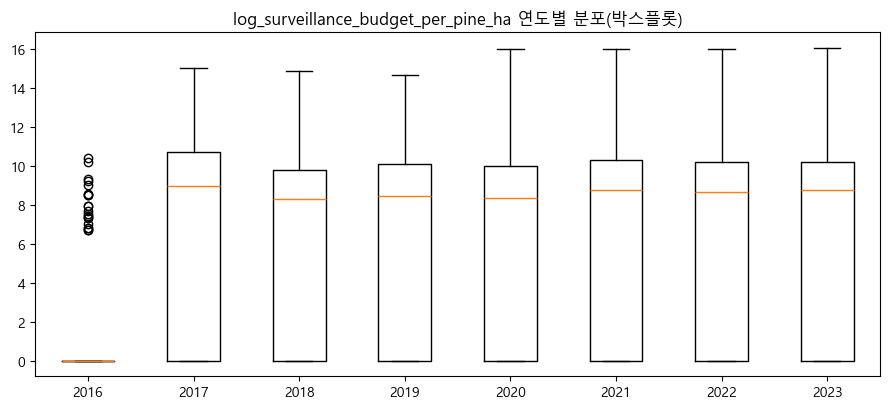

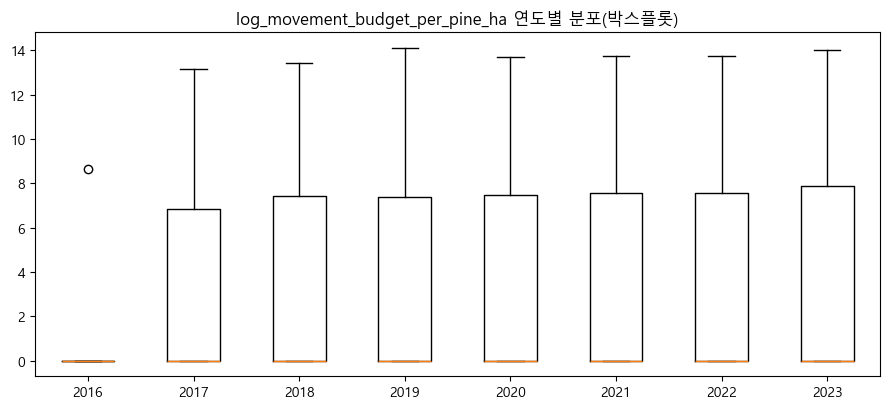

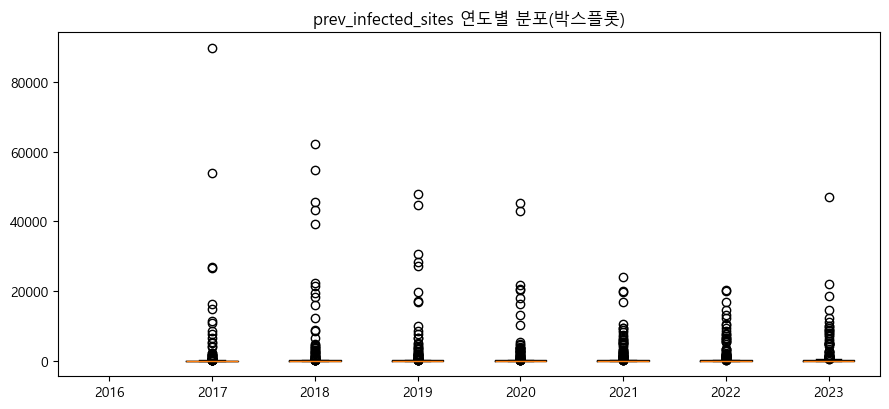

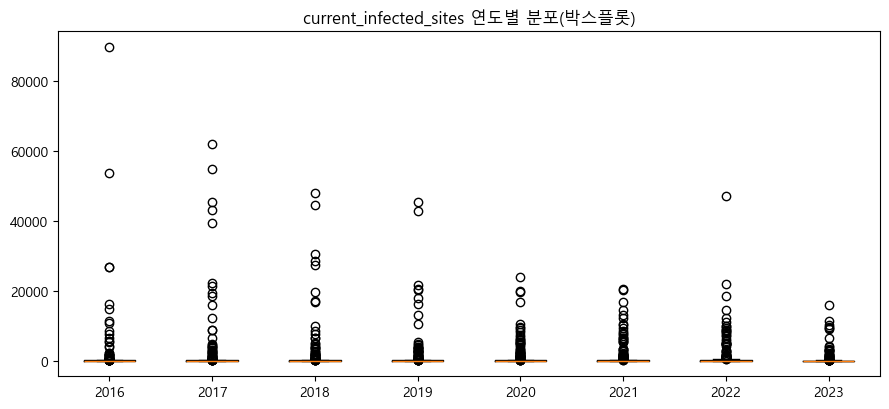

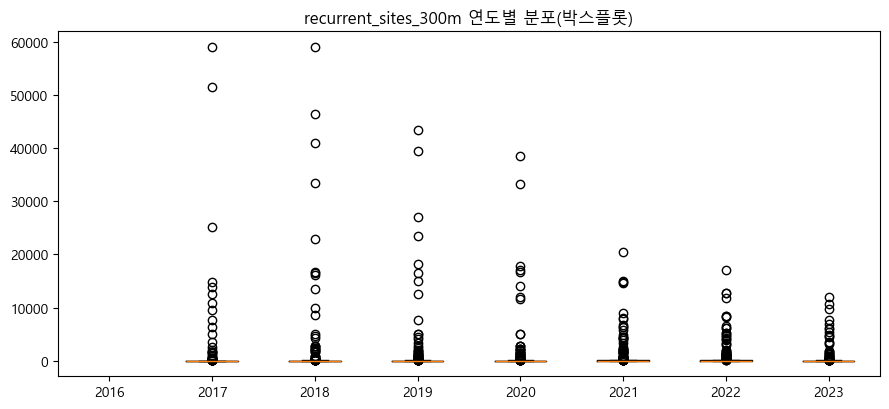

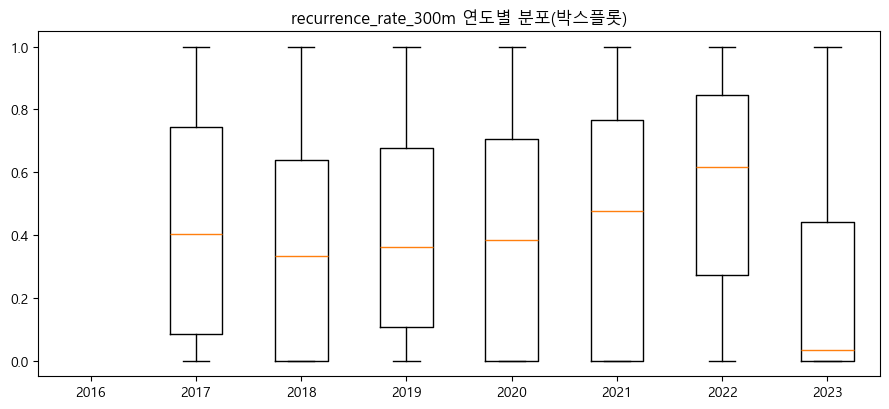

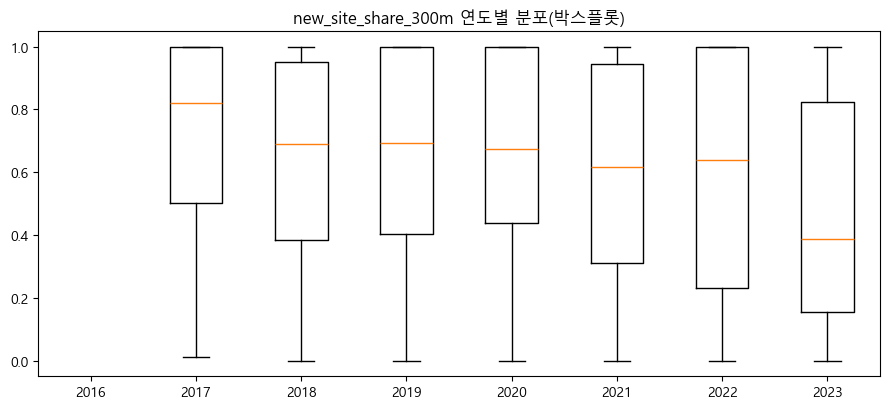

In [40]:
years_sorted = sorted(df["year"].unique())
for c in LOG_COLS + OCCUR_COLS:
    fig, ax = plt.subplots(figsize=(9, 4.2))
    data = [df.loc[df["year"] == y, c].dropna().values for y in years_sorted]
    ax.boxplot(data, tick_labels=years_sorted)
    ax.set_title(f"{c} 연도별 분포(박스플롯)")
    plt.tight_layout()
    plt.show()

**결과에서 확인해야 할 사항**
- 특정 연도에 평균/중앙값이 이전·이후와 단절적으로 달라지는지
- 결측률·0비율이 특정 연도에 급변하는지(제도 시행 시점 등과 겹치는지)
- 재발생 변수는 2016년에 전부 NA임을 다시 확인(정의상 당연한 결과이므로 "이상"이 아님에 유의)

**결과 해석 기준**
- 연도별 평균의 완만한 증가/감소는 정책 강화 추세로 해석할 수 있으나, 단절적 급변은 진짜 정책 변화인지
  자료 수집 기준 변경인지 구분해서 봐야 한다.
- 2016년의 재발생 변수 결측은 "전년도 자료가 없어 정의상 계산 불가"한 구조적 결측이며, 데이터 품질
  문제가 아니다.

**다음 단계에 미치는 영향**
- 여기서 식별된 연도별 특이 패턴은 15단계(패널 특성/지속성 분석)의 연도효과 해석과 16단계 결측 처리
  권고에 반영한다.

## 9단계. 지역별 차이 분석

**분석 목적**: 시군구별 장기 평균·변동성·관측 특성을 살펴 지속적으로 높거나 낮은 지역, 특정 연도에만
급등락한 지역을 식별한다.

In [41]:
sgg_group = df.groupby(["sigungu_cd", "sigungu_full_nm"])
sgg_stats = sgg_group[LOG_COLS + PER_HA_COLS].agg(["mean", "median", "std", "min", "max"])
sgg_obs_years = sgg_group["year"].nunique().rename("관측연도수")
sgg_zero_years = sgg_group.apply(lambda g: (g["resource_local_budget"] == 0).sum()).rename("자원예산0인연도수")

print("시군구별 통계(일부 컬럼) 예시 - log_resource_budget_per_pine_ha:")
display(sgg_stats["log_resource_budget_per_pine_ha"].join(sgg_obs_years).join(sgg_zero_years).sort_values("mean", ascending=False).head(10))

시군구별 통계(일부 컬럼) 예시 - log_resource_budget_per_pine_ha:


,,mean,median,std,min,max,관측연도수,자원예산0인연도수
sigungu_cd,sigungu_full_nm,,,,,,,
11440,서울특별시 마포구,16.9263,16.9354,0.2403,16.6070,17.1853,8,0
11530,서울특별시 구로구,16.8095,16.9161,0.4043,16.1309,17.2118,8,0
11200,서울특별시 성동구,16.5644,16.5503,0.0800,16.4706,16.7169,8,0
11140,서울특별시 중구,15.7622,15.7725,0.0756,15.6094,15.8727,8,0
11650,서울특별시 서초구,15.4572,15.5261,0.2849,14.9775,15.7875,8,0
28177,인천광역시 미추홀구,15.2571,15.6268,0.7605,14.1335,15.9383,8,0
11545,서울특별시 금천구,15.0440,14.8567,0.3981,14.6450,15.6205,8,0
11740,서울특별시 강동구,14.9346,14.9298,0.2619,14.5654,15.3352,8,0
41410,경기도 군포시,14.4678,14.4439,0.3072,14.1053,15.0854,8,0


In [42]:
# 변동계수(CV) = std/mean : 값이 항상 양수인 ha당예산 계열에만 적용
cv_rows = []
for c in PER_HA_COLS + LOG_COLS:
    g_mean = df.groupby("sigungu_full_nm")[c].mean()
    g_std = df.groupby("sigungu_full_nm")[c].std()
    cv = (g_std / g_mean.replace(0, np.nan)).abs()
    cv_rows.append([c, cv.mean(), cv.median()])
cv_summary = pd.DataFrame(cv_rows, columns=["변수", "시군구간_평균CV", "시군구간_중앙CV"])
print("변수별 시군구 내 변동계수(CV) 요약 (값이 클수록 해당 시군구가 연도별로 들쭉날쭉함을 의미):")
display(cv_summary)

변수별 시군구 내 변동계수(CV) 요약 (값이 클수록 해당 시군구가 연도별로 들쭉날쭉함을 의미):


,변수,시군구간_평균CV,시군구간_중앙CV
0,resource_budget_per_pine_ha,0.6398,0.5214
1,surveillance_budget_per_pine_ha,0.8624,0.6445
2,movement_budget_per_pine_ha,1.0284,0.6077
3,log_resource_budget_per_pine_ha,0.1473,0.0512
4,log_surveillance_budget_per_pine_ha,0.6094,0.4074
5,log_movement_budget_per_pine_ha,0.9615,0.4117


In [43]:
# 각 변수의 상위/하위 지역 (장기평균 기준)
for c in ["log_resource_budget_per_pine_ha", "log_surveillance_budget_per_pine_ha",
          "log_movement_budget_per_pine_ha", "recurrence_rate_300m"]:
    long_mean = df.groupby("sigungu_full_nm")[c].mean().dropna()
    print(f"\n[{c}] 장기평균 상위 5개 지역:")
    print(long_mean.nlargest(5))
    print(f"[{c}] 장기평균 하위 5개 지역:")
    print(long_mean.nsmallest(5))


[log_resource_budget_per_pine_ha] 장기평균 상위 5개 지역:
sigungu_full_nm
서울특별시 마포구   16.9263
서울특별시 구로구   16.8095
서울특별시 성동구   16.5644
서울특별시 중구    15.7622
서울특별시 서초구   15.4572
Name: log_resource_budget_per_pine_ha, dtype: float64
[log_resource_budget_per_pine_ha] 장기평균 하위 5개 지역:
sigungu_full_nm
경기도 광명시     0.0000
경기도 부천시     0.0000
대구광역시 동구    0.0000
부산광역시 중구    0.0000
서울특별시 강남구   0.0000
Name: log_resource_budget_per_pine_ha, dtype: float64

[log_surveillance_budget_per_pine_ha] 장기평균 상위 5개 지역:
sigungu_full_nm
서울특별시 송파구   12.8151
경기도 군포시     12.0230
대구광역시 서구    11.9779
충청북도 증평군    11.8065
서울특별시 금천구   11.7932
Name: log_surveillance_budget_per_pine_ha, dtype: float64
[log_surveillance_budget_per_pine_ha] 장기평균 하위 5개 지역:
sigungu_full_nm
강원특별자치도 홍천군   0.0000
경기도 광명시       0.0000
경기도 부천시       0.0000
경기도 오산시       0.0000
경상남도 사천시      0.0000
Name: log_surveillance_budget_per_pine_ha, dtype: float64

[log_movement_budget_per_pine_ha] 장기평균 상위 5개 지역:
sigungu_full_nm
서울특별시 송파구   11.8318
인천광역시 서구    11.1749


In [44]:
# 지속적으로 높은/낮은 지역: 8개 연도 중 상위 25% 안에 몇 번 들었는지로 판단
c = "log_resource_budget_per_pine_ha"
df["_year_rank_pct"] = df.groupby("year")[c].rank(pct=True)
persist_high = df.groupby("sigungu_full_nm")["_year_rank_pct"].apply(lambda s: (s >= 0.75).sum())
persist_low = df.groupby("sigungu_full_nm")["_year_rank_pct"].apply(lambda s: (s <= 0.25).sum())
print(f"[{c}] 8개 연도 중 상위 25% 안에 든 횟수가 많은 지역(지속적 고위):")
print(persist_high.sort_values(ascending=False).head(10))
print(f"\n[{c}] 8개 연도 중 하위 25% 안에 든 횟수가 많은 지역(지속적 저위):")
print(persist_low.sort_values(ascending=False).head(10))

[log_resource_budget_per_pine_ha] 8개 연도 중 상위 25% 안에 든 횟수가 많은 지역(지속적 고위):
sigungu_full_nm
경기도 과천시     8
경기도 구리시     8
경기도 광주시     8
경기도 연천군     8
경기도 의왕시     8
경기도 시흥시     8
경기도 동두천시    8
경기도 남양주시    8
경기도 김포시     8
경기도 군포시     8
Name: _year_rank_pct, dtype: int64

[log_resource_budget_per_pine_ha] 8개 연도 중 하위 25% 안에 든 횟수가 많은 지역(지속적 저위):
sigungu_full_nm
강원특별자치도 양구군    8
강원특별자치도 삼척시    8
강원특별자치도 양양군    8
경기도 광명시        8
경기도 부천시        8
경상남도 거창군       8
경상남도 함양군       8
대구광역시 동구       8
서울특별시 관악구      8
서울특별시 강북구      8
Name: _year_rank_pct, dtype: int64


In [45]:
# 특정 연도에만 급등/급락한 지역 (전년대비 변화량 기준)
df_sorted = df.sort_values(["sigungu_cd", "year"]).copy()
df_sorted["_resource_diff"] = df_sorted.groupby("sigungu_cd")["log_resource_budget_per_pine_ha"].diff()
top_surge = df_sorted.nlargest(10, "_resource_diff")[["year", "sigungu_full_nm", "log_resource_budget_per_pine_ha", "_resource_diff"]]
top_drop = df_sorted.nsmallest(10, "_resource_diff")[["year", "sigungu_full_nm", "log_resource_budget_per_pine_ha", "_resource_diff"]]
print("전년대비 log_resource_budget_per_pine_ha 급등 상위 10건:")
display(top_surge)
print("\n전년대비 급락 상위 10건:")
display(top_drop)

전년대비 log_resource_budget_per_pine_ha 급등 상위 10건:


,year,sigungu_full_nm,log_resource_budget_per_pine_ha,_resource_diff
273,2017,서울특별시 송파구,14.9078,14.9078
293,2017,대구광역시 서구,14.4129,14.4129
265,2017,서울특별시 강서구,14.2763,14.2763
519,2018,서울특별시 동작구,14.2668,14.2668
614,2018,경기도 여주시,11.8338,11.8338
1537,2022,부산광역시 연제구,11.4240,11.4240
259,2017,서울특별시 도봉구,11.2333,11.2333
1509,2022,서울특별시 도봉구,11.1024,11.1024
957,2019,경상북도 울릉군,10.7450,10.7450
1009,2020,서울특별시 도봉구,10.6983,10.6983



전년대비 급락 상위 10건:


,year,sigungu_full_nm,log_resource_budget_per_pine_ha,_resource_diff
509,2018,서울특별시 도봉구,0.0000,-11.2333
1759,2023,서울특별시 도봉구,0.0000,-11.1024
1259,2021,서울특별시 도봉구,0.0000,-10.6983
764,2019,서울특별시 양천구,0.0000,-10.6895
294,2017,대구광역시 남구,0.0000,-10.6598
510,2018,서울특별시 노원구,0.0000,-10.0393
1037,2020,부산광역시 연제구,0.0000,-9.6343
496,2017,강원특별자치도 양구군,0.0000,-9.1488
1145,2020,충청남도 홍성군,0.0000,-8.5048
996,2019,강원특별자치도 양구군,0.0000,-7.8358


**결과에서 확인해야 할 사항**
- 장기평균이 지속적으로 높은/낮은 지역이 몇 개 시도에 몰려 있는지
- 변동계수(CV)가 매우 큰 변수는 시군구 내에서도 연도별로 값이 크게 출렁인다는 뜻
- 특정 연도에만 급등/급락한 지역이 반복적인 사업 패턴인지 일회성 사업비인지

**결과 해석 기준**
- 8개 연도 내내 상위/하위에 머무는 지역은 "지속적 특성"(지리적 여건, 예산 정책 기조)을 반영할 가능성이
  높아 정책 해석(9~11단계, 16단계 "정책 해석용 변수" 판단)에 유용하다.
- 특정 연도에만 급변한 지역은 15단계(패널 지속성)·14단계(이상치) 분석에서 일회성 사업비 여부를 다시
  점검해야 한다.

**다음 단계에 미치는 영향**
- 지속적 고위/저위 지역 목록은 11단계(예산 배분구조 유형화)와 14단계(이상치 분류)에서 재사용한다.

## 10단계. 변수 간 상관관계와 중복성 분석

**분석 목적**: 전체 수치형 변수 간 상관을 살펴보되, 산식상 자동으로 높은 상관이 나오는 변수쌍
(예: 세부예산과 included, 원예산과 ha당예산)과 통계적으로 의미 있는 상관을 구분한다.

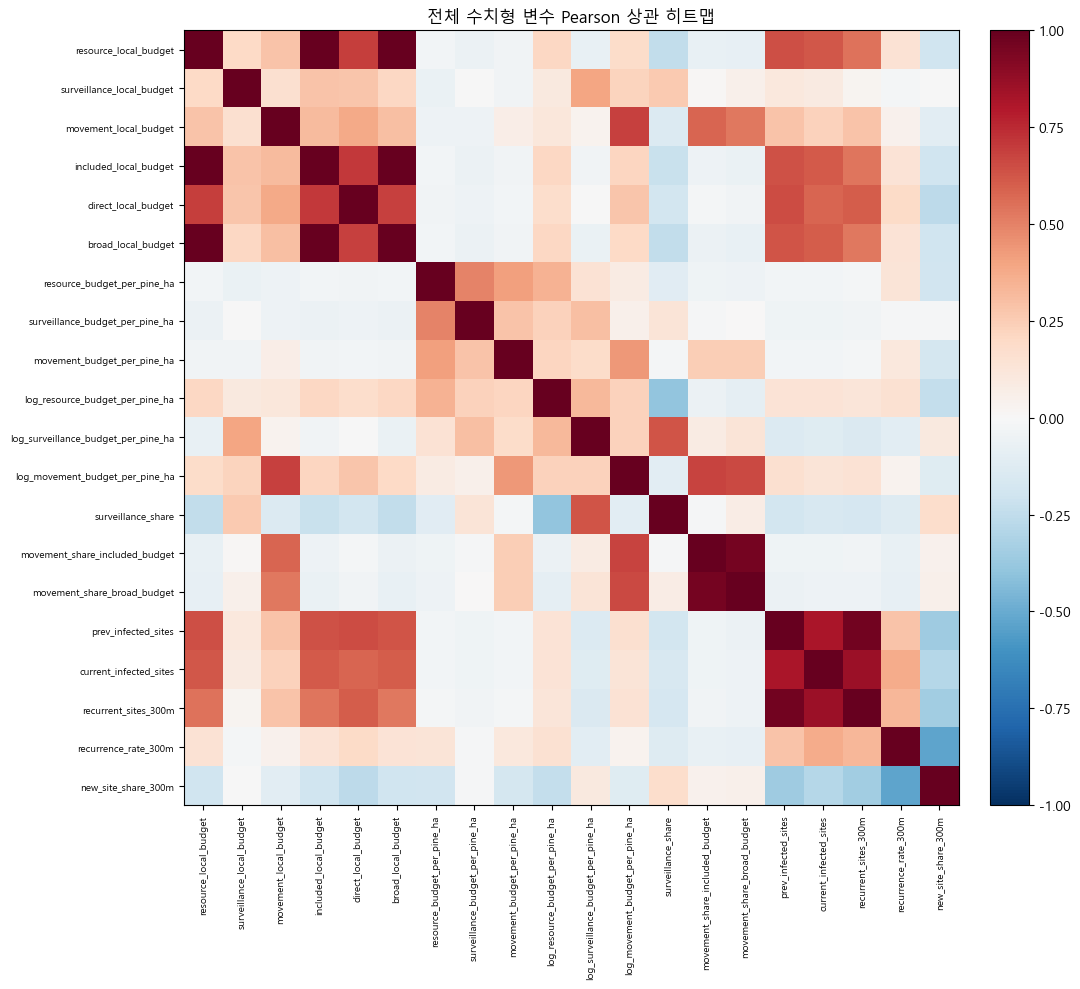

In [46]:
CORR_COLS = RAW_BUDGET_COLS + PER_HA_COLS + LOG_COLS + SHARE_COLS + OCCUR_COLS
pearson_corr = df[CORR_COLS].corr(method="pearson")
spearman_corr = df[CORR_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(pearson_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR_COLS))); ax.set_xticklabels(CORR_COLS, rotation=90, fontsize=7)
ax.set_yticks(range(len(CORR_COLS))); ax.set_yticklabels(CORR_COLS, fontsize=7)
plt.colorbar(im, fraction=0.045, pad=0.03)
ax.set_title("전체 수치형 변수 Pearson 상관 히트맵")
plt.tight_layout()
plt.show()

In [47]:
# 상관계수 절댓값이 높은 변수쌍 (자기 자신 제외, 중복쌍 제거)
corr_pairs = pearson_corr.where(np.triu(np.ones(pearson_corr.shape), k=1).astype(bool)).stack()
high_pairs = corr_pairs[corr_pairs.abs() >= 0.8].sort_values(key=abs, ascending=False)
high_pairs_df = high_pairs.reset_index()
high_pairs_df.columns = ["변수1", "변수2", "Pearson_r"]
print(f"|상관계수| >= 0.8 인 변수쌍 ({len(high_pairs_df)}개):")
display(high_pairs_df)

|상관계수| >= 0.8 인 변수쌍 (7개):


,변수1,변수2,Pearson_r
0,resource_local_budget,broad_local_budget,0.9993
1,included_local_budget,broad_local_budget,0.9965
2,resource_local_budget,included_local_budget,0.9961
3,prev_infected_sites,recurrent_sites_300m,0.9622
4,movement_share_included_budget,movement_share_broad_budget,0.9591
5,current_infected_sites,recurrent_sites_300m,0.8523
6,prev_infected_sites,current_infected_sites,0.8194


In [48]:
# 산식상 자동으로 높은 상관이 나오는 대표 쌍 직접 확인 + 설명
print("[세부예산 vs included예산] (산식상 included = 세부예산의 합이므로 구조적으로 높은 상관 예상)")
display(pearson_corr.loc[["resource_local_budget", "surveillance_local_budget", "movement_local_budget"], "included_local_budget"])

print("\n[원예산 vs ha당예산] (같은 항목의 정규화 전후 - 규모효과가 제거되면 상관이 낮아질 것)")
for raw_col, per_ha_col in zip(["resource_local_budget", "surveillance_local_budget", "movement_local_budget"], PER_HA_COLS):
    print(f"  {raw_col} vs {per_ha_col}: r = {pearson_corr.loc[raw_col, per_ha_col]:.4f}")

print("\n[raw ha당예산 vs log ha당예산] (같은 항목의 변환 전후 - 매우 높은 상관이 정상)")
for raw_col, log_col in zip(PER_HA_COLS, LOG_COLS):
    print(f"  {raw_col} vs {log_col}: r = {pearson_corr.loc[raw_col, log_col]:.4f}")

print("\n[세부예산 vs 구성비] (구성비의 분자가 세부예산이므로 구조적 상관 예상)")
print(f"  movement_local_budget vs movement_share_included_budget: r = {pearson_corr.loc['movement_local_budget', 'movement_share_included_budget']:.4f}")
print(f"  surveillance_local_budget vs surveillance_share: r = {pearson_corr.loc['surveillance_local_budget', 'surveillance_share']:.4f}")

[세부예산 vs included예산] (산식상 included = 세부예산의 합이므로 구조적으로 높은 상관 예상)


resource_local_budget       0.9961
surveillance_local_budget   0.2843
movement_local_budget       0.3154
Name: included_local_budget, dtype: float64


[원예산 vs ha당예산] (같은 항목의 정규화 전후 - 규모효과가 제거되면 상관이 낮아질 것)
  resource_local_budget vs resource_budget_per_pine_ha: r = -0.0244
  surveillance_local_budget vs surveillance_budget_per_pine_ha: r = -0.0000
  movement_local_budget vs movement_budget_per_pine_ha: r = 0.0659

[raw ha당예산 vs log ha당예산] (같은 항목의 변환 전후 - 매우 높은 상관이 정상)
  resource_budget_per_pine_ha vs log_resource_budget_per_pine_ha: r = 0.3471
  surveillance_budget_per_pine_ha vs log_surveillance_budget_per_pine_ha: r = 0.3017
  movement_budget_per_pine_ha vs log_movement_budget_per_pine_ha: r = 0.4328

[세부예산 vs 구성비] (구성비의 분자가 세부예산이므로 구조적 상관 예상)
  movement_local_budget vs movement_share_included_budget: r = 0.5809
  surveillance_local_budget vs surveillance_share: r = 0.2642


In [49]:
# 발생지점 수와 발생률 변수 간 중복성 확인
occur_corr = df[OCCUR_COLS].corr(method="pearson")
print("발생/재발생 변수 간 상관관계:")
display(occur_corr)
print("\n※ recurrent_sites_300m은 recurrence_rate_300m의 분자이므로 구조적으로 상관이 높을 수 있음.")
print("   또한 current_infected_sites가 크면 prev_infected_sites(전년도 자기 자신)도 큰 경향이 있어")
print("   '규모(지역 크기)'라는 공통 요인이 여러 발생변수에 동시에 반영될 가능성을 함께 고려해야 한다.")

발생/재발생 변수 간 상관관계:


,prev_infected_sites,current_infected_sites,recurrent_sites_300m,recurrence_rate_300m,new_site_share_300m
prev_infected_sites,1.0000,0.8194,0.9622,0.2872,-0.3570
current_infected_sites,0.8194,1.0000,0.8523,0.3739,-0.2815
recurrent_sites_300m,0.9622,0.8523,1.0000,0.3342,-0.3479
recurrence_rate_300m,0.2872,0.3739,0.3342,1.0000,-0.5286
new_site_share_300m,-0.3570,-0.2815,-0.3479,-0.5286,1.0000



※ recurrent_sites_300m은 recurrence_rate_300m의 분자이므로 구조적으로 상관이 높을 수 있음.
   또한 current_infected_sites가 크면 prev_infected_sites(전년도 자기 자신)도 큰 경향이 있어
   '규모(지역 크기)'라는 공통 요인이 여러 발생변수에 동시에 반영될 가능성을 함께 고려해야 한다.


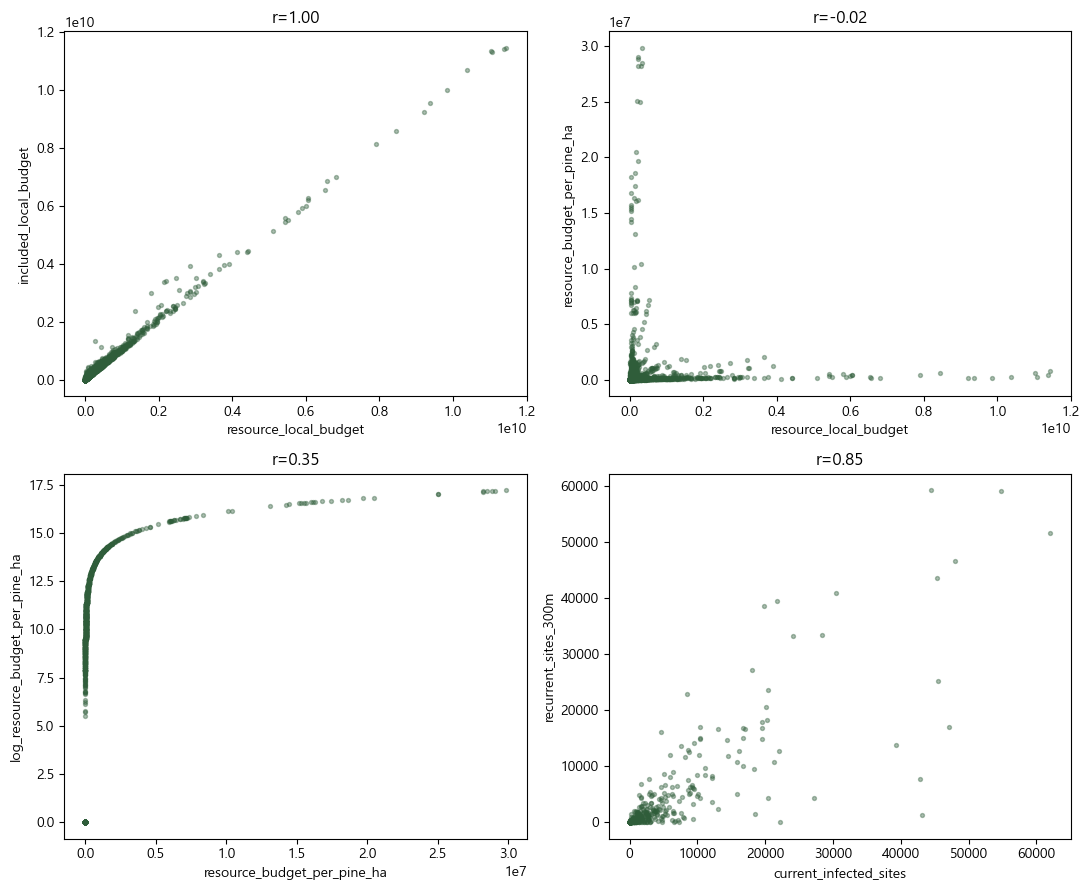

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
pairs_to_plot = [
    ("resource_local_budget", "included_local_budget"),
    ("resource_local_budget", "resource_budget_per_pine_ha"),
    ("resource_budget_per_pine_ha", "log_resource_budget_per_pine_ha"),
    ("current_infected_sites", "recurrent_sites_300m"),
]
for ax, (x, y) in zip(axes.flat, pairs_to_plot):
    sub = df[[x, y]].dropna()
    ax.scatter(sub[x], sub[y], s=8, alpha=0.4, color="#2f5d3a")
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f"r={pearson_corr.loc[x,y]:.2f}" if x in pearson_corr.index and y in pearson_corr.columns else "")
plt.tight_layout()
plt.show()

**결과에서 확인해야 할 사항**
- 산식상 당연히 높은 상관(원값-로그, 세부예산-included, 세부예산-구성비)과 그렇지 않은 상관을 구분
- 원예산과 ha당예산의 상관이 세부예산-included 상관보다 상대적으로 낮다면, 정규화가 실제로 새로운
  정보(규모 대비 강도)를 만들어낸다는 근거가 됨
- 발생지점 수 변수들 간에도 "지역 규모"라는 공통 요인이 숨어 있을 수 있음

**결과 해석 기준**
- 산식으로 정의된 상관(예: raw-log, 세부-included)은 "변수 간 독립적 관계"가 아니라 "같은 정보의 다른
  표현"이므로 다중공선성 문제로 취급하되 회귀모형에 두 변수를 동시에 넣지 않는 방식으로 대응한다.
- 산식과 무관한 순수 통계적 상관(예: 서로 다른 항목의 ha당예산 간 상관)은 실제 정책 상관관계를
  시사할 수 있으므로 11단계(배분구조 분석)에서 더 살펴본다.

**다음 단계에 미치는 영향**
- 여기서 식별된 "구조적 중복 변수쌍"은 16단계 최종 변수 분류에서 동시에 지수에 포함하지 않도록
  걸러내는 기준이 된다.

## 11단계. 예산 배분구조 분석

**분석 목적**: 자원투입·예찰진단·이동통제 세 기능 간 예산 배분 구조를 살펴보고, 시군구를
"자원투입 중심/예찰진단 중심/이동통제 중심/균형형" 등으로 유형화할 가능성이 있는지 탐색한다.
이 단계에서는 최종 유형을 확정하지 않고 가능성만 평가한다.

연도별 전국 합계 기준 예산 구성비:


,resource_local_budget,surveillance_local_budget,movement_local_budget
year,,,
2016,0.9913,0.0080,0.0006
2017,0.8114,0.1687,0.0199
2018,0.8812,0.0910,0.0278
2019,0.8890,0.0861,0.0249
2020,0.8740,0.0961,0.0298
2021,0.8408,0.1251,0.0341
2022,0.8601,0.1103,0.0295
2023,0.9028,0.0763,0.0209


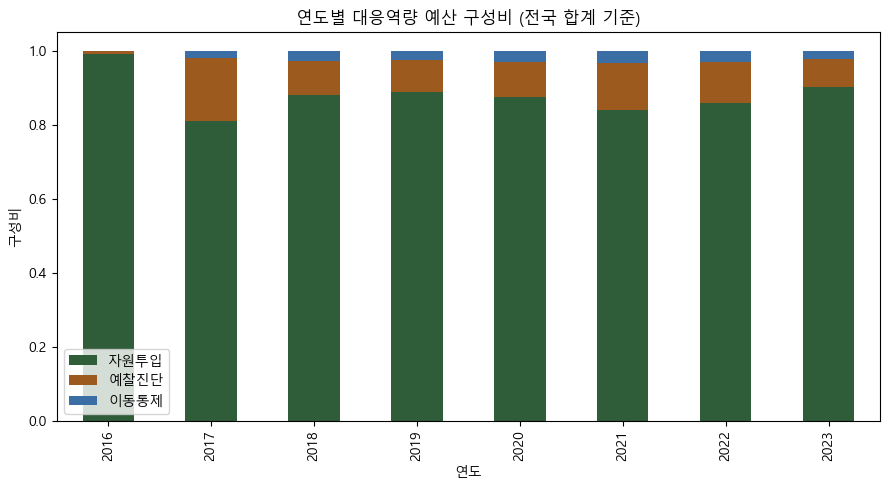

In [51]:
budget_observed_1 = df[df["budget_observed"] == 1]
comp_by_year = budget_observed_1.groupby("year")[["resource_local_budget", "surveillance_local_budget", "movement_local_budget"]].sum()
comp_share_by_year = comp_by_year.div(comp_by_year.sum(axis=1), axis=0)
print("연도별 전국 합계 기준 예산 구성비:")
display(comp_share_by_year)

fig, ax = plt.subplots(figsize=(9, 5))
comp_share_by_year.plot(kind="bar", stacked=True, ax=ax, color=["#2f5d3a", "#9c5a1e", "#3a6ea5"])
ax.set_title("연도별 대응역량 예산 구성비 (전국 합계 기준)")
ax.set_ylabel("구성비"); ax.set_xlabel("연도")
ax.legend(["자원투입", "예찰진단", "이동통제"])
plt.tight_layout()
plt.show()

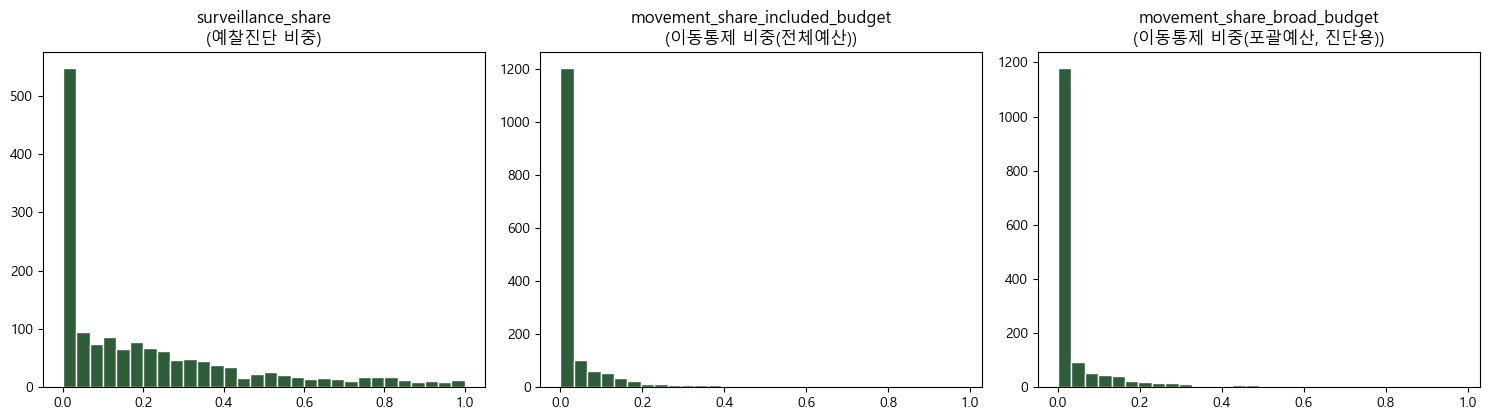

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, c, title in zip(axes, SHARE_COLS, ["예찰진단 비중", "이동통제 비중(전체예산)", "이동통제 비중(포괄예산, 진단용)"]):
    vals = df[c].dropna()
    ax.hist(vals, bins=30, color="#2f5d3a", edgecolor="white")
    ax.set_title(f"{c}\n({title})")
plt.tight_layout()
plt.show()

In [53]:
sgg_composition = df.groupby("sigungu_full_nm")[SHARE_COLS].mean().dropna()
print("시군구별 평균 구성비 (상위 10개, surveillance_share 기준):")
display(sgg_composition.sort_values("surveillance_share", ascending=False).head(10))

시군구별 평균 구성비 (상위 10개, surveillance_share 기준):


,surveillance_share,movement_share_included_budget,movement_share_broad_budget
sigungu_full_nm,,,
강원특별자치도 양구군,0.8285,0.0000,0.0000
부산광역시 연제구,0.8171,0.0000,0.0000
충청북도 증평군,0.7925,0.0000,0.0000
부산광역시 동구,0.7865,0.0000,0.0000
부산광역시 사상구,0.7415,0.0000,0.0000
부산광역시 부산진구,0.7412,0.0000,0.0000
부산광역시 북구,0.7159,0.0000,0.0000
부산광역시 동래구,0.7073,0.0000,0.0000
부산광역시 서구,0.7069,0.0000,0.0000


In [54]:
# 각 행에서 가장 큰 예산 기능 분류
budget_only = df.loc[df["budget_observed"] == 1, ["resource_local_budget", "surveillance_local_budget", "movement_local_budget"]]
dominant_type = budget_only.idxmax(axis=1).map({
    "resource_local_budget": "자원투입 중심",
    "surveillance_local_budget": "예찰진단 중심",
    "movement_local_budget": "이동통제 중심",
})
print("행(시군구x연도) 단위 최대 예산기능 분류:")
print(dominant_type.value_counts())
print("\n비율:")
print((dominant_type.value_counts(normalize=True) * 100).round(1))

행(시군구x연도) 단위 최대 예산기능 분류:
자원투입 중심    1456
예찰진단 중심     247
이동통제 중심       7
Name: count, dtype: int64

비율:
자원투입 중심   85.1000
예찰진단 중심   14.4000
이동통제 중심    0.4000
Name: proportion, dtype: float64


In [55]:
# 균형형 탐색: 세 항목 구성비가 특정 항목에 80% 이상 쏠리지 않은 경우를 '균형형' 후보로 임시 정의
comp_ratio = budget_only.div(budget_only.sum(axis=1), axis=0)
max_share = comp_ratio.max(axis=1)
balanced_candidate = (max_share < 0.8).mean()
print(f"세 기능 중 어느 하나도 80% 이상 차지하지 않는(균형형 후보) 행의 비율: {balanced_candidate*100:.1f}%")
print("\n※ 이 단계에서는 유형(자원투입중심/예찰진단중심/이동통제중심/균형형)의 '가능성'만 확인하며,")
print("   실제 군집분석 등을 통한 최종 유형 확정은 본 EDA의 범위를 벗어난다.")

세 기능 중 어느 하나도 80% 이상 차지하지 않는(균형형 후보) 행의 비율: 36.3%

※ 이 단계에서는 유형(자원투입중심/예찰진단중심/이동통제중심/균형형)의 '가능성'만 확인하며,
   실제 군집분석 등을 통한 최종 유형 확정은 본 EDA의 범위를 벗어난다.


**결과에서 확인해야 할 사항**
- 전국적으로 예산이 자원투입에 압도적으로 쏠려 있는지(2016~2023년 CH2 파이프라인 검증에서 이미
  자원투입이 약 88%를 차지하는 것으로 알려져 있음 - 여기서 최신 패널 기준으로 재확인)
- 시군구x연도 단위로 볼 때 "자원투입 중심"이 아닌 지역이 실제로 존재하는지, 그 비율
- 연도가 지날수록 구성비가 예찰진단·이동통제 쪽으로 이동하는 추세가 있는지

**결과 해석 기준**
- 대부분의 행이 자원투입 중심으로 분류된다면, 이는 "대응역량"이라는 개념이 사실상 자원투입 예산에
  의해 좌우된다는 의미이므로 지수 설계 시 이 쏠림을 감안해야 한다.
- 균형형 후보 비율이 낮다면 유형화(clustering)의 실익이 크지 않을 수 있고, 반대로 상당 비율이라면
  후속 분석에서 유형화를 시도해볼 근거가 된다.

**다음 단계에 미치는 영향**
- 이 단계의 결과는 16단계에서 `surveillance_share`, `movement_share_included_budget`을
  "정책 해석 및 유형화 변수"로 분류할지 판단하는 근거가 된다.

## 12단계. 발생 및 재발생 변수 분석

**분석 목적**: `prev_infected_sites`, `current_infected_sites`, `recurrent_sites_300m`,
`recurrence_rate_300m`, `new_site_share_300m` 5개 변수 각각의 분포·0비율·결측률·연도별 변화·
지역별 차이를 살펴보고, 항상 무발생인 지역과 반복 발생 지역을 구분한다.

In [56]:
occur_desc = describe_all(OCCUR_COLS)
display(occur_desc)

,변수,관측치수,결측수,결측률,평균,표준편차,최솟값,Q1,중앙값,Q3,최댓값,왜도,0개수,0비율,고유값수
0,prev_infected_sites,1750,250,0.1250,"1,235.5754","5,323.8775",0.0000,0.0000,0.0000,71.2500,"89,815.0000",8.1112,905,0.5171,476
1,current_infected_sites,2000,0,0.0000,"1,140.0095","5,028.2093",0.0000,0.0000,0.0000,55.2500,"89,815.0000",8.5043,1068,0.5340,514
2,recurrent_sites_300m,1750,250,0.1250,849.6091,"4,161.6224",0.0000,0.0000,0.0000,17.0000,"59,129.0000",8.6124,1136,0.6491,376
3,recurrence_rate_300m,845,1155,0.5775,0.3984,0.3468,0.0000,0.0000,0.3750,0.7143,1.0000,0.2349,231,0.2734,512
4,new_site_share_300m,826,1174,0.5870,0.6268,0.3330,0.0000,0.3334,0.6665,1.0000,1.0000,-0.3580,22,0.0266,523


In [57]:
occur_na_by_year = df.groupby("year")[OCCUR_COLS].apply(lambda g: g.isna().mean())
print("연도별 결측률:")
display(occur_na_by_year)

occur_by_sido = df.groupby("sido")[OCCUR_COLS].mean()
print("\n시도별 평균:")
display(occur_by_sido)

연도별 결측률:


,prev_infected_sites,current_infected_sites,recurrent_sites_300m,recurrence_rate_300m,new_site_share_300m
year,,,,,
2016,1.0000,0.0000,1.0000,1.0000,1.0000
2017,0.0000,0.0000,0.0000,0.5760,0.5120
2018,0.0000,0.0000,0.0000,0.5120,0.5480
2019,0.0000,0.0000,0.0000,0.5480,0.5120
2020,0.0000,0.0000,0.0000,0.5120,0.4920
2021,0.0000,0.0000,0.0000,0.4920,0.5160
2022,0.0000,0.0000,0.0000,0.5160,0.4640
2023,0.0000,0.0000,0.0000,0.4640,0.6520



시도별 평균:


,prev_infected_sites,current_infected_sites,recurrent_sites_300m,recurrence_rate_300m,new_site_share_300m
sido,,,,,
강원특별자치도,152.8333,202.5208,75.3730,0.3656,0.6833
경기도,669.7415,616.0298,454.0340,0.3607,0.6434
경상남도,"2,958.7532","2,698.2614","1,496.4091",0.4189,0.5804
경상북도,"3,414.9565","3,191.5978","2,389.2112",0.4911,0.5657
광주광역시,56.2571,125.8500,40.8571,0.3481,0.6001
대구광역시,761.5238,852.5278,512.1746,0.5199,0.5213
대전광역시,0.6857,0.6500,0.4571,0.6518,0.5714
부산광역시,159.8571,140.8516,74.7143,0.3411,0.6916
서울특별시,0.0000,0.0000,0.0000,NaN,NaN


In [58]:
# 항상 무발생인 시군구 (8개 연도 모두 current_infected_sites == 0)
always_zero = df.groupby("sigungu_full_nm")["current_infected_sites"].apply(lambda s: (s == 0).all())
print("전기간(8개년) 감염목 확정 발생지 0건인 시군구 수:", int(always_zero.sum()))
print("목록 일부:", always_zero[always_zero].index.tolist()[:15], "...")

전기간(8개년) 감염목 확정 발생지 0건인 시군구 수: 83
목록 일부: ['강원특별자치도 강릉시', '강원특별자치도 고성군', '강원특별자치도 속초시', '강원특별자치도 양구군', '강원특별자치도 영월군', '강원특별자치도 태백시', '강원특별자치도 평창군', '경기도 고양시 덕양구', '경기도 고양시 일산동구', '경기도 고양시 일산서구', '경기도 과천시', '경기도 광명시', '경기도 구리시', '경기도 군포시', '경기도 김포시'] ...


In [59]:
# 일부 연도에만 발생한 시군구 vs 반복 발생 시군구
n_years_with_occur = df.groupby("sigungu_full_nm")["current_infected_sites"].apply(lambda s: (s > 0).sum())
print("시군구별 '발생연도 수(current_infected_sites>0)' 분포:")
display(n_years_with_occur.value_counts().sort_index().to_frame("시군구수"))

sporadic = n_years_with_occur[(n_years_with_occur >= 1) & (n_years_with_occur <= 2)]
repeat_occur = n_years_with_occur[n_years_with_occur >= 6]
print(f"\n일부 연도(1~2개년)에만 발생한 시군구 수: {len(sporadic)}")
print(f"반복 발생(6개년 이상) 시군구 수: {len(repeat_occur)}")
print("반복 발생 시군구 목록:", repeat_occur.index.tolist())

시군구별 '발생연도 수(current_infected_sites>0)' 분포:


,시군구수
current_infected_sites,
0,83
1,21
2,12
3,10
4,10
5,13
6,13
7,30
8,58



일부 연도(1~2개년)에만 발생한 시군구 수: 33
반복 발생(6개년 이상) 시군구 수: 101
반복 발생 시군구 목록: ['강원특별자치도 원주시', '강원특별자치도 정선군', '강원특별자치도 춘천시', '강원특별자치도 홍천군', '강원특별자치도 횡성군', '경기도 가평군', '경기도 광주시', '경기도 남양주시', '경기도 동두천시', '경기도 성남시 분당구', '경기도 성남시 수정구', '경기도 성남시 중원구', '경기도 안성시', '경기도 양주시', '경기도 양평군', '경기도 여주시', '경기도 연천군', '경기도 용인시 기흥구', '경기도 용인시 처인구', '경기도 이천시', '경기도 파주시', '경기도 평택시', '경기도 포천시', '경기도 하남시', '경상남도 거제시', '경상남도 고성군', '경상남도 김해시', '경상남도 남해군', '경상남도 밀양시', '경상남도 사천시', '경상남도 산청군', '경상남도 양산시', '경상남도 의령군', '경상남도 진주시', '경상남도 창녕군', '경상남도 창원시 마산합포구', '경상남도 창원시 마산회원구', '경상남도 창원시 성산구', '경상남도 창원시 의창구', '경상남도 창원시 진해구', '경상남도 통영시', '경상남도 하동군', '경상남도 함안군', '경상남도 합천군', '경상북도 경산시', '경상북도 경주시', '경상북도 고령군', '경상북도 구미시', '경상북도 김천시', '경상북도 봉화군', '경상북도 상주시', '경상북도 성주군', '경상북도 안동시', '경상북도 영덕군', '경상북도 영주시', '경상북도 영천시', '경상북도 의성군', '경상북도 청도군', '경상북도 칠곡군', '경상북도 포항시 남구', '경상북도 포항시 북구', '광주광역시 광산구', '대구광역시 군위군', '대구광역시 달서구', '대구광역시 달성군', '대구광역시 동구', '대구광역시 북구', '대구광역시 서구', '대구광역시 수성구', '부산광역시 강서구', '부산광역시 금정구', '부산광역시 기장군', '부산광역시 부산진

In [60]:
# recurrence_rate_300m, new_site_share_300m 이 0 또는 1인 비율
rr = df["recurrence_rate_300m"].dropna()
nss = df["new_site_share_300m"].dropna()
print(f"recurrence_rate_300m: 유효 n={len(rr)}, 0인 비율={ (rr==0).mean()*100:.1f}%, 1인 비율={(rr==1).mean()*100:.1f}%")
print(f"new_site_share_300m: 유효 n={len(nss)}, 0인 비율={(nss==0).mean()*100:.1f}%, 1인 비율={(nss==1).mean()*100:.1f}%")

recurrence_rate_300m: 유효 n=845, 0인 비율=27.3%, 1인 비율=2.6%
new_site_share_300m: 유효 n=826, 0인 비율=2.7%, 1인 비율=25.8%


In [61]:
# prev_infected_sites == 0 일 때 recurrence_rate_300m 처리 방식 재확인 (구조적 NA vs 실제 0)
zero_prev = df[df["prev_infected_sites"] == 0]
print("prev_infected_sites==0인 행수:", len(zero_prev))
print("그 중 recurrence_rate_300m이 NA인 행수(=0/0 이므로 NA 처리가 맞음):", int(zero_prev["recurrence_rate_300m"].isna().sum()))
print("그 중 recurrent_sites_300m 값 분포(0이어야 함):")
print(zero_prev["recurrent_sites_300m"].value_counts(dropna=False))

na_prev = df[df["prev_infected_sites"].isna()]
print("\nprev_infected_sites가 NA인 행수(=2016년, 구조적 결측):", len(na_prev))
print("연도 확인:", na_prev["year"].unique())

prev_infected_sites==0인 행수: 905
그 중 recurrence_rate_300m이 NA인 행수(=0/0 이므로 NA 처리가 맞음): 905
그 중 recurrent_sites_300m 값 분포(0이어야 함):
recurrent_sites_300m
0.0000    905
Name: count, dtype: int64

prev_infected_sites가 NA인 행수(=2016년, 구조적 결측): 250
연도 확인: [2016]


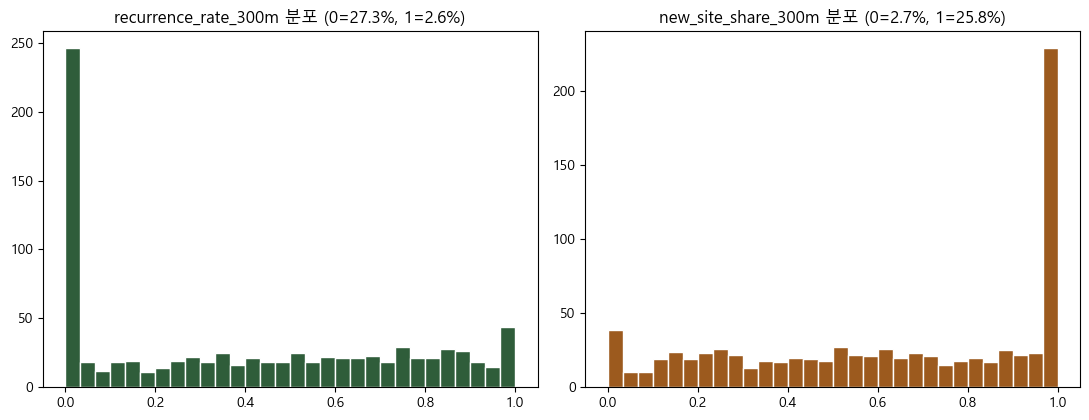

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].hist(rr, bins=30, color="#2f5d3a", edgecolor="white")
axes[0].set_title(f"recurrence_rate_300m 분포 (0={100*(rr==0).mean():.1f}%, 1={100*(rr==1).mean():.1f}%)")
axes[1].hist(nss, bins=30, color="#9c5a1e", edgecolor="white")
axes[1].set_title(f"new_site_share_300m 분포 (0={100*(nss==0).mean():.1f}%, 1={100*(nss==1).mean():.1f}%)")
plt.tight_layout()
plt.show()

**결과에서 확인해야 할 사항**
- `current_infected_sites`가 전기간 0인 시군구 수(이미 파이프라인 검증에서 83개로 확인된 값과
  이 패널에서 재계산한 값이 일치하는지)
- `recurrence_rate_300m`/`new_site_share_300m`이 0 또는 1에 몰려 있는 정도(양극단 집중이 심하면
  연속형 지수보다 범주형/더미 해석이 나을 수 있음)
- `prev_infected_sites==0`일 때 `recurrence_rate_300m`이 반드시 NA로 처리되어 있는지(0으로 잘못
  채워지지 않았는지)

**결과 해석 기준**
- 전기간 무발생 시군구는 "재선충병 위험 자체가 낮은 지역"으로 해석해야 하며, 이 지역들의
  `recurrence_rate_300m`이 NA인 것은 결측이 아니라 "재발생을 논할 발생 자체가 없었다"는 구조적으로
  정당한 결과다.
- 0/1 극단값 비율이 높다는 것은 이 변수가 연속형 지수라기보다 "재발생이 있었는가/없었는가"에 가까운
  성격을 가질 수 있음을 시사한다.

**다음 단계에 미치는 영향**
- 여기서 정리한 0/NA/실제값 구분은 13단계(예산-성과 관계)에서 "발생 경험 지역만 제한한 분석"의
  표본 정의로 그대로 사용된다.

## 13단계. 예산 관련 변수와 발생성과의 탐색적 관계

**분석 목적**: 원예산·ha당예산·로그예산·구성비와 발생성과(당해 발생지수, 재발생지수, 재발생률,
신규발생비중) 사이의 탐색적 연관성을 살펴본다. 이 단계에서는 인과관계를 주장하지 않고 상관·연관성만
해석한다.

In [63]:
BUDGET_VARS_FOR_OUTCOME = ["resource_local_budget", "resource_budget_per_pine_ha", "log_resource_budget_per_pine_ha",
                           "movement_local_budget", "movement_budget_per_pine_ha", "log_movement_budget_per_pine_ha",
                           "surveillance_share", "movement_share_included_budget"]
OUTCOME_VARS = ["current_infected_sites", "recurrent_sites_300m", "recurrence_rate_300m", "new_site_share_300m"]

def corr_table(data, budget_vars, outcome_vars, label):
    rows = []
    for b in budget_vars:
        for o in outcome_vars:
            sub = data[[b, o]].dropna()
            if len(sub) < 10:
                rows.append([b, o, np.nan, np.nan, len(sub)])
                continue
            r, p = stats.pearsonr(sub[b], sub[o])
            rho, p2 = stats.spearmanr(sub[b], sub[o])
            rows.append([b, o, r, rho, len(sub)])
    out = pd.DataFrame(rows, columns=["예산변수", "성과변수", "Pearson_r", "Spearman_rho", "n"])
    print(f"=== {label} ===")
    display(out)
    return out

corr_all = corr_table(df, BUDGET_VARS_FOR_OUTCOME, OUTCOME_VARS, "전체 지역, 동일연도 예산-성과 상관")

=== 전체 지역, 동일연도 예산-성과 상관 ===


,예산변수,성과변수,Pearson_r,Spearman_rho,n
0,resource_local_budget,current_infected_sites,0.6177,0.6363,1710
1,resource_local_budget,recurrent_sites_300m,0.5422,0.6070,1497
2,resource_local_budget,recurrence_rate_300m,0.1438,0.2642,716
3,resource_local_budget,new_site_share_300m,-0.2010,-0.3153,708
4,resource_budget_per_pine_ha,current_infected_sites,-0.0260,0.2193,1686
5,resource_budget_per_pine_ha,recurrent_sites_300m,-0.0200,0.2402,1476
6,resource_budget_per_pine_ha,recurrence_rate_300m,0.1285,0.2114,716
7,resource_budget_per_pine_ha,new_site_share_300m,-0.1926,-0.3169,708
8,log_resource_budget_per_pine_ha,current_infected_sites,0.1332,0.2193,1686
9,log_resource_budget_per_pine_ha,recurrent_sites_300m,0.1241,0.2402,1476


In [64]:
# 발생 경험 지역만 제한한 분석 (current_infected_sites>0 이었던 적이 있는 시군구만)
ever_occur_sgg = df.groupby("sigungu_cd")["current_infected_sites"].apply(lambda s: (s > 0).any())
occur_sgg_list = ever_occur_sgg[ever_occur_sgg].index
df_occur_only = df[df["sigungu_cd"].isin(occur_sgg_list)]
print(f"발생 경험이 있는 시군구 수: {len(occur_sgg_list)} / 전체 {df['sigungu_cd'].nunique()}")

corr_occur_only = corr_table(df_occur_only, BUDGET_VARS_FOR_OUTCOME, OUTCOME_VARS, "발생 경험 지역만 제한한 예산-성과 상관")

발생 경험이 있는 시군구 수: 167 / 전체 250
=== 발생 경험 지역만 제한한 예산-성과 상관 ===


,예산변수,성과변수,Pearson_r,Spearman_rho,n
0,resource_local_budget,current_infected_sites,0.6049,0.5996,1152
1,resource_local_budget,recurrent_sites_300m,0.5297,0.5871,1008
2,resource_local_budget,recurrence_rate_300m,0.1438,0.2642,716
3,resource_local_budget,new_site_share_300m,-0.2010,-0.3153,708
4,resource_budget_per_pine_ha,current_infected_sites,0.2020,0.3963,1152
5,resource_budget_per_pine_ha,recurrent_sites_300m,0.2201,0.4078,1008
6,resource_budget_per_pine_ha,recurrence_rate_300m,0.1285,0.2114,716
7,resource_budget_per_pine_ha,new_site_share_300m,-0.1926,-0.3169,708
8,log_resource_budget_per_pine_ha,current_infected_sites,0.2215,0.3963,1152
9,log_resource_budget_per_pine_ha,recurrent_sites_300m,0.2115,0.4078,1008


In [65]:
# 예산 분위수별 성과 평균/중앙값 비교
b = "log_resource_budget_per_pine_ha"
df["_budget_q"] = pd.qcut(df[b], 4, labels=["Q1(최저)", "Q2", "Q3", "Q4(최고)"], duplicates="drop")
print(f"[{b}] 분위수별 성과변수 평균:")
display(df.groupby("_budget_q", observed=True)[OUTCOME_VARS].mean())
print(f"\n[{b}] 분위수별 성과변수 중앙값:")
display(df.groupby("_budget_q", observed=True)[OUTCOME_VARS].median())

[log_resource_budget_per_pine_ha] 분위수별 성과변수 평균:


,current_infected_sites,recurrent_sites_300m,recurrence_rate_300m,new_site_share_300m
_budget_q,,,,
Q1(최저),24.3009,5.1157,0.2551,0.8057
Q2,319.3349,131.8575,0.3744,0.6913
Q3,"1,478.6271",837.0658,0.4002,0.6223
Q4(최고),"2,330.5427","2,017.3370",0.5056,0.4533



[log_resource_budget_per_pine_ha] 분위수별 성과변수 중앙값:


,current_infected_sites,recurrent_sites_300m,recurrence_rate_300m,new_site_share_300m
_budget_q,,,,
Q1(최저),0.0000,0.0000,0.0000,1.0000
Q2,1.0000,0.0000,0.3333,0.7203
Q3,20.0000,3.0000,0.3846,0.6425
Q4(최고),0.0000,0.0000,0.5493,0.3691


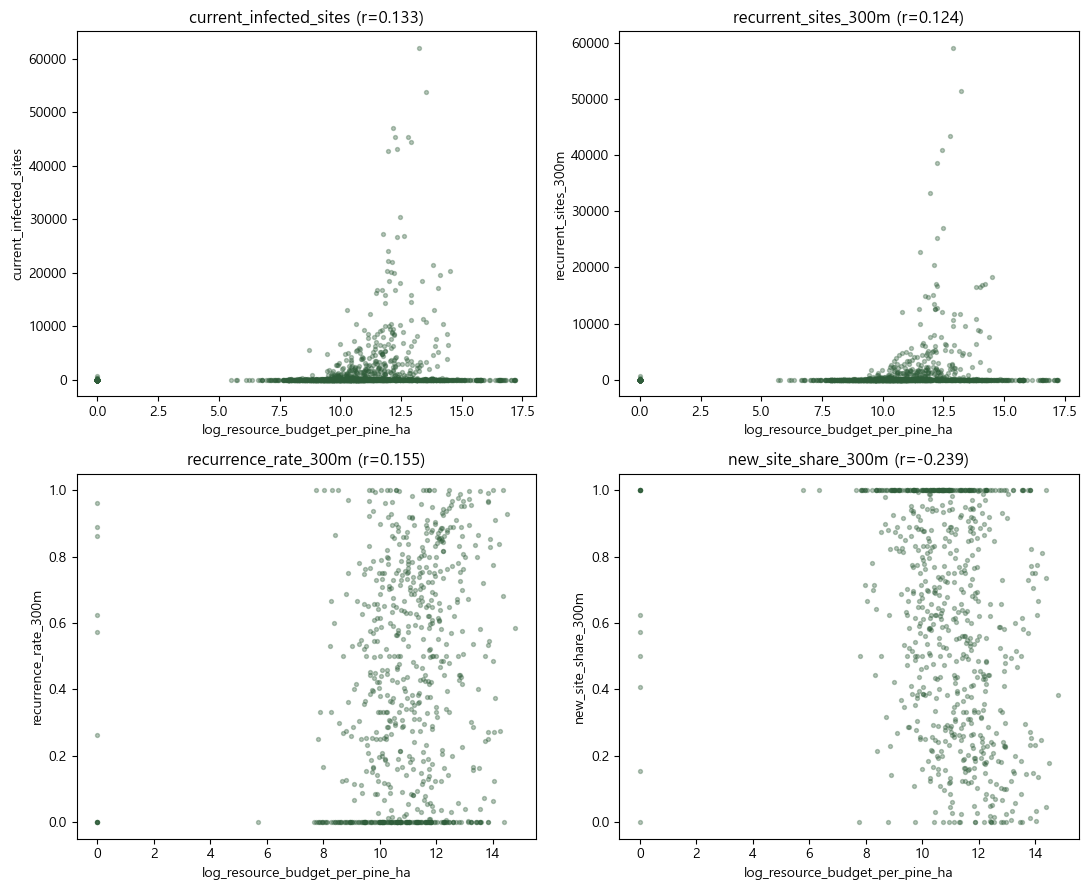

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, o in zip(axes.flat, OUTCOME_VARS):
    sub = df[[b, o]].dropna()
    ax.scatter(sub[b], sub[o], s=8, alpha=0.35, color="#2f5d3a")
    ax.set_xlabel(b); ax.set_ylabel(o)
    r = corr_all.loc[(corr_all["예산변수"] == b) & (corr_all["성과변수"] == o), "Pearson_r"].values[0]
    ax.set_title(f"{o} (r={r:.3f})")
plt.tight_layout()
plt.show()

In [67]:
# 시차 관계: 전년도 예산 -> 다음해 성과
df_lag = df.sort_values(["sigungu_cd", "year"]).copy()
for c in ["log_resource_budget_per_pine_ha", "log_movement_budget_per_pine_ha", "surveillance_share"]:
    df_lag[f"{c}_lag1"] = df_lag.groupby("sigungu_cd")[c].shift(1)

lag_rows = []
for b_lag in ["log_resource_budget_per_pine_ha_lag1", "log_movement_budget_per_pine_ha_lag1", "surveillance_share_lag1"]:
    for o in OUTCOME_VARS:
        sub = df_lag[[b_lag, o]].dropna()
        if len(sub) < 10:
            continue
        r, p = stats.pearsonr(sub[b_lag], sub[o])
        rho, p2 = stats.spearmanr(sub[b_lag], sub[o])
        lag_rows.append([b_lag, o, r, rho, len(sub)])
lag_df = pd.DataFrame(lag_rows, columns=["전년도예산변수", "당해성과변수", "Pearson_r", "Spearman_rho", "n"])
print("전년도 예산 -> 당해연도 성과 (시차) 상관:")
display(lag_df)

print("\n[같은 해 상관과 비교]")
same_year_compare = corr_all[corr_all["예산변수"].isin(["log_resource_budget_per_pine_ha", "log_movement_budget_per_pine_ha", "surveillance_share"])]
display(same_year_compare)

전년도 예산 -> 당해연도 성과 (시차) 상관:


,전년도예산변수,당해성과변수,Pearson_r,Spearman_rho,n
0,log_resource_budget_per_pine_ha_lag1,current_infected_sites,0.1346,0.2102,1475
1,log_resource_budget_per_pine_ha_lag1,recurrent_sites_300m,0.1275,0.2285,1475
2,log_resource_budget_per_pine_ha_lag1,recurrence_rate_300m,0.1735,0.2118,716
3,log_resource_budget_per_pine_ha_lag1,new_site_share_300m,-0.2387,-0.3001,708
4,log_movement_budget_per_pine_ha_lag1,current_infected_sites,0.1026,0.2773,1475
5,log_movement_budget_per_pine_ha_lag1,recurrent_sites_300m,0.1198,0.2817,1475
6,log_movement_budget_per_pine_ha_lag1,recurrence_rate_300m,0.0198,0.0461,716
7,log_movement_budget_per_pine_ha_lag1,new_site_share_300m,-0.1404,-0.1633,708
8,surveillance_share_lag1,current_infected_sites,-0.1589,-0.1573,1357
9,surveillance_share_lag1,recurrent_sites_300m,-0.1432,-0.1526,1357



[같은 해 상관과 비교]


,예산변수,성과변수,Pearson_r,Spearman_rho,n
8,log_resource_budget_per_pine_ha,current_infected_sites,0.1332,0.2193,1686
9,log_resource_budget_per_pine_ha,recurrent_sites_300m,0.1241,0.2402,1476
10,log_resource_budget_per_pine_ha,recurrence_rate_300m,0.1553,0.2114,716
11,log_resource_budget_per_pine_ha,new_site_share_300m,-0.2394,-0.3169,708
20,log_movement_budget_per_pine_ha,current_infected_sites,0.1324,0.2938,1686
21,log_movement_budget_per_pine_ha,recurrent_sites_300m,0.1432,0.2990,1476
22,log_movement_budget_per_pine_ha,recurrence_rate_300m,0.0326,0.0617,716
23,log_movement_budget_per_pine_ha,new_site_share_300m,-0.1215,-0.1588,708
24,surveillance_share,current_infected_sites,-0.1570,-0.1496,1552
25,surveillance_share,recurrent_sites_300m,-0.1659,-0.2123,1362


**결과에서 확인해야 할 사항**
- 동일연도 상관과 시차(전년도 예산 -> 당해 성과) 상관의 방향·크기 차이
- 전체 지역 분석과 "발생 경험 지역만" 제한한 분석에서 상관의 방향이 달라지는지(무발생 지역이 섞여
  상관을 왜곡할 가능성)
- 예산 분위수가 높아질수록 재발생률이 낮아지는 경향이 있는지, 아니면 오히려 높아지는지

**결과 해석 기준**
- 이 단계의 모든 상관은 인과관계가 아니라 탐색적 연관성이다. 특히 "예산이 많은 지역일수록 재발생이
  많다"는 결과가 나오더라도 이는 예산이 재발생을 유발한다는 뜻이 아니라, 발생이 심각한 지역에 예산이
  더 투입되는 반대 방향의 인과(reverse causality)일 가능성이 높다는 점에 유의해야 한다.
- 시차 상관과 동일연도 상관의 패턴이 비슷하다면 시간적 선후관계보다 지역 특성(상시적으로 발생이 많고
  예산도 많은 지역)이 상관을 만들어내는 주요인일 가능성이 있다.

**다음 단계에 미치는 영향**
- 이 단계에서 예산-성과 관계가 뚜렷하지 않거나 역인과 가능성이 확인되면, 16단계에서 재발생 변수를
  "대응역량 지수"에 그대로 포함하는 것은 순환논리 위험이 있다는 근거로 사용한다.

## 14단계. 이상치 및 특이 지역 분석

**분석 목적**: 주요 변수의 상·하위 이상치 지역을 구체적으로 식별하고, 그 원인을 "실제 지역특성 /
작은 분모 문제 / 코드·병합 오류 가능성 / 단위 오류 가능성 / 일시적 사업비 / 행정구역 변경" 중
어디에 해당할지 근거와 함께 제시한다. 이상치를 자동으로 제거하거나 보정하지 않는다.

In [68]:
def top_bottom(col, n=8):
    valid = df[df[col].notna()]
    top = valid.nlargest(n, col)[["year", "sigungu_full_nm", col]]
    bottom = valid.nsmallest(n, col)[["year", "sigungu_full_nm", col]]
    print(f"\n[{col}] 상위 {n}개:")
    display(top)
    print(f"[{col}] 하위 {n}개:")
    display(bottom)

for c in ["resource_budget_per_pine_ha", "movement_budget_per_pine_ha", "surveillance_share", "recurrence_rate_300m"]:
    top_bottom(c)


[resource_budget_per_pine_ha] 상위 8개:


,year,sigungu_full_nm,resource_budget_per_pine_ha
1766,2023,서울특별시 구로구,"29,853,708.0300"
1263,2021,서울특별시 마포구,"29,072,053.6900"
1513,2022,서울특별시 마포구,"28,843,027.4200"
1266,2021,서울특별시 구로구,"28,513,059.6700"
763,2019,서울특별시 마포구,"28,247,360.3900"
1516,2022,서울특별시 구로구,"28,197,131.7600"
1763,2023,서울특별시 마포구,"25,056,393.4500"
1016,2020,서울특별시 구로구,"25,030,367.8600"


[resource_budget_per_pine_ha] 하위 8개:


,year,sigungu_full_nm,resource_budget_per_pine_ha
2,2016,서울특별시 용산구,0.0000
4,2016,서울특별시 광진구,0.0000
5,2016,서울특별시 동대문구,0.0000
6,2016,서울특별시 중랑구,0.0000
7,2016,서울특별시 성북구,0.0000
8,2016,서울특별시 강북구,0.0000
9,2016,서울특별시 도봉구,0.0000
10,2016,서울특별시 노원구,0.0000



[movement_budget_per_pine_ha] 상위 8개:


...

,year,sigungu_full_nm,surveillance_share
0,2016,서울특별시 종로구,0.0000
1,2016,서울특별시 중구,0.0000
3,2016,서울특별시 성동구,0.0000
11,2016,서울특별시 은평구,0.0000
12,2016,서울특별시 서대문구,0.0000
13,2016,서울특별시 마포구,0.0000
16,2016,서울특별시 구로구,0.0000
17,2016,서울특별시 금천구,0.0000



[recurrence_rate_300m] 상위 8개:


,year,sigungu_full_nm,recurrence_rate_300m
298,2017,대구광역시 달성군,1.0000
322,2017,울산광역시 동구,1.0000
355,2017,경기도 용인시 수지구,1.0000
442,2017,경상북도 영천시,1.0000
580,2018,경기도 성남시 수정구,1.0000
727,2018,경상남도 함양군,1.0000
1033,2020,부산광역시 해운대구,1.0000
1146,2020,충청남도 예산군,1.0000


[recurrence_rate_300m] 하위 8개:


,year,sigungu_full_nm,recurrence_rate_300m
285,2017,부산광역시 금정구,0.0000
286,2017,부산광역시 강서구,0.0000
293,2017,대구광역시 서구,0.0000
311,2017,광주광역시 서구,0.0000
312,2017,광주광역시 남구,0.0000
333,2017,경기도 의정부시,0.0000
356,2017,경기도 파주시,0.0000
364,2017,경기도 여주시,0.0000


In [69]:
# 소나무림 면적이 극단적으로 작은 지역
print("소나무림 면적 하위 5개(양수인 것 중):")
display(df[df["pine_area_ha_2024"] > 0].nsmallest(5, "pine_area_ha_2024")[["year", "sigungu_full_nm", "pine_area_ha_2024"]])
print("\n소나무림 면적이 0(계산 제외 대상)인 시군구:")
display(df[df["pine_area_ha_2024"] == 0][["sigungu_full_nm"]].drop_duplicates())

소나무림 면적 하위 5개(양수인 것 중):


,year,sigungu_full_nm,pine_area_ha_2024
94,2016,경기도 고양시 일산서구,0.7017
344,2017,경기도 고양시 일산서구,0.7017
594,2018,경기도 고양시 일산서구,0.7017
844,2019,경기도 고양시 일산서구,0.7017
1094,2020,경기도 고양시 일산서구,0.7017



소나무림 면적이 0(계산 제외 대상)인 시군구:


,sigungu_full_nm
18,서울특별시 영등포구
41,대구광역시 중구
51,인천광역시 동구


In [70]:
# 원예산은 크지만 ha당예산은 낮은 지역 / 원예산은 작지만 ha당예산은 높은 지역
sub = df[df["resource_local_budget"].notna() & df["resource_budget_per_pine_ha"].notna()].copy()
sub["_raw_rank"] = sub["resource_local_budget"].rank(ascending=False)
sub["_perha_rank"] = sub["resource_budget_per_pine_ha"].rank(ascending=False)
sub["_rank_gap"] = sub["_perha_rank"] - sub["_raw_rank"]  # 양수 크면: 원예산 순위는 높은데 ha당 순위는 낮음

print("원예산은 상위인데 ha당예산 순위는 크게 낮은 지역(순위격차 상위 10):")
display(sub.nlargest(10, "_rank_gap")[["year", "sigungu_full_nm", "resource_local_budget", "resource_budget_per_pine_ha", "pine_area_ha_2024", "_rank_gap"]])

print("\n원예산은 하위인데 ha당예산 순위는 크게 높은 지역(순위격차 하위 10, 즉 매우 음수):")
display(sub.nsmallest(10, "_rank_gap")[["year", "sigungu_full_nm", "resource_local_budget", "resource_budget_per_pine_ha", "pine_area_ha_2024", "_rank_gap"]])

원예산은 상위인데 ha당예산 순위는 크게 낮은 지역(순위격차 상위 10):


,year,sigungu_full_nm,resource_local_budget,resource_budget_per_pine_ha,pine_area_ha_2024,_rank_gap
455,2017,경상북도 봉화군,"647,484,000.0000","15,698.3284","41,245.4106",911.0000
1205,2020,경상북도 봉화군,"524,469,612.0000","12,715.8296","41,245.4106",903.0000
1955,2023,경상북도 봉화군,"560,573,000.0000","13,591.1606","41,245.4106",901.0000
955,2019,경상북도 봉화군,"695,807,232.0000","16,869.9310","41,245.4106",899.0000
206,2016,경상북도 울진군,"605,144,000.0000","15,459.8774","39,142.8718",893.0000
205,2016,경상북도 봉화군,"443,573,000.0000","10,754.4814","41,245.4106",883.0000
1206,2020,경상북도 울진군,"715,416,000.0000","18,277.0442","39,142.8718",883.0000
706,2018,경상북도 울진군,"508,979,000.0000","13,003.1083","39,142.8718",882.0000
956,2019,경상북도 울진군,"449,666,620.0000","11,487.8291","39,142.8718",872.0000
456,2017,경상북도 울진군,"428,112,000.0000","10,937.1638","39,142.8718",864.0000



원예산은 하위인데 ha당예산 순위는 크게 높은 지역(순위격차 하위 10, 즉 매우 음수):


,year,sigungu_full_nm,resource_local_budget,resource_budget_per_pine_ha,pine_area_ha_2024,_rank_gap
773,2019,서울특별시 송파구,"22,666,000.0000","1,576,325.5950",14.3790,"-1,271.0000"
769,2019,서울특별시 동작구,"23,149,000.0000","1,402,492.3590",16.5056,"-1,251.0000"
519,2018,서울특별시 동작구,"25,920,000.0000","1,570,374.6140",16.5056,"-1,249.0000"
802,2019,인천광역시 미추홀구,"24,342,000.0000","1,374,365.3730",17.7114,"-1,241.0000"
1003,2020,서울특별시 성동구,"37,631,000.0000","14,226,152.9500",2.6452,"-1,230.0000"
751,2019,서울특별시 중구,"35,329,000.0000","6,012,649.0980",5.8758,"-1,227.0000"
1503,2022,서울특별시 성동구,"38,225,000.0000","14,450,710.7500",2.6452,"-1,224.0000"
3,2016,서울특별시 성동구,"40,141,000.0000","15,175,042.0000",2.6452,"-1,214.0000"
253,2017,서울특별시 성동구,"40,509,000.0000","15,314,161.9900",2.6452,"-1,211.0000"
1253,2021,서울특별시 성동구,"41,002,000.0000","15,500,537.4100",2.6452,"-1,206.0000"


In [71]:
# 예산 구성비가 극단적인 지역
extreme_share = df[df["movement_share_included_budget"].notna()].nlargest(10, "movement_share_included_budget")
print("이동통제 비중(movement_share_included_budget)이 극단적으로 높은 지역:")
display(extreme_share[["year", "sigungu_full_nm", "movement_local_budget", "included_local_budget", "movement_share_included_budget"]])

이동통제 비중(movement_share_included_budget)이 극단적으로 높은 지역:


,year,sigungu_full_nm,movement_local_budget,included_local_budget,movement_share_included_budget
1957,2023,경상북도 울릉군,"45,620,000.0000","46,499,000.0000",0.9811
1062,2020,광주광역시 남구,"41,472,000.0000","61,026,000.0000",0.6796
1036,2020,부산광역시 강서구,"82,944,000.0000","167,255,000.0000",0.4959
1065,2020,대전광역시 동구,"16,589,000.0000","37,641,000.0000",0.4407
1550,2022,인천광역시 중구,"21,890,000.0000","49,950,000.0000",0.4382
1286,2021,부산광역시 강서구,"84,040,000.0000","192,210,000.0000",0.4372
550,2018,인천광역시 중구,"18,495,000.0000","42,325,000.0000",0.4370
1800,2023,인천광역시 중구,"22,810,000.0000","52,542,000.0000",0.4341
1659,2022,전라북도 임실군,"134,116,000.0000","324,648,000.0000",0.4131
1706,2022,경상북도 울진군,"218,900,000.0000","534,797,758.0000",0.4093


In [72]:
# 예산이 높은데 재발생도 높은 지역 / 예산이 낮은데 재발생도 낮은 지역
sub2 = df[df["log_resource_budget_per_pine_ha"].notna() & df["recurrence_rate_300m"].notna()].copy()
budget_high = sub2["log_resource_budget_per_pine_ha"] >= sub2["log_resource_budget_per_pine_ha"].quantile(0.75)
budget_low = sub2["log_resource_budget_per_pine_ha"] <= sub2["log_resource_budget_per_pine_ha"].quantile(0.25)
recur_high = sub2["recurrence_rate_300m"] >= sub2["recurrence_rate_300m"].quantile(0.75)
recur_low = sub2["recurrence_rate_300m"] <= sub2["recurrence_rate_300m"].quantile(0.25)

print("예산 상위 25% & 재발생률 상위 25% (사례 수):", int((budget_high & recur_high).sum()))
display(sub2[budget_high & recur_high][["year", "sigungu_full_nm", "log_resource_budget_per_pine_ha", "recurrence_rate_300m"]].head(8))

print("\n예산 하위 25% & 재발생률 하위 25% (사례 수):", int((budget_low & recur_low).sum()))
display(sub2[budget_low & recur_low][["year", "sigungu_full_nm", "log_resource_budget_per_pine_ha", "recurrence_rate_300m"]].head(8))

예산 상위 25% & 재발생률 상위 25% (사례 수): 73


,year,sigungu_full_nm,log_resource_budget_per_pine_ha,recurrence_rate_300m
278,2017,부산광역시 영도구,12.3969,0.8735
290,2017,부산광역시 기장군,11.9808,0.8000
320,2017,울산광역시 중구,13.8205,0.9650
321,2017,울산광역시 남구,12.2379,0.8434
322,2017,울산광역시 동구,14.3758,1.0000
323,2017,울산광역시 북구,13.8305,0.9919
324,2017,울산광역시 울주군,13.2291,0.9573
361,2017,경기도 광주시,13.3758,0.8364



예산 하위 25% & 재발생률 하위 25% (사례 수): 68


,year,sigungu_full_nm,log_resource_budget_per_pine_ha,recurrence_rate_300m
286,2017,부산광역시 강서구,10.0204,0.0000
364,2017,경기도 여주시,0.0000,0.0000
373,2017,충청북도 제천시,9.9891,0.0000
376,2017,충청북도 영동군,9.9991,0.0000
411,2017,전라북도 고창군,8.8219,0.0000
416,2017,전라남도 나주시,7.8787,0.0000
421,2017,전라남도 고흥군,8.9395,0.0000
426,2017,전라남도 해남군,8.7379,0.0000


In [73]:
# 전년 대비 예산 급증/급락 지역
df_lag2 = df.sort_values(["sigungu_cd", "year"]).copy()
df_lag2["_resource_yoy"] = df_lag2.groupby("sigungu_cd")["resource_local_budget"].pct_change()
finite_yoy = df_lag2[np.isfinite(df_lag2["_resource_yoy"])]
print("전년대비 자원투입예산 증가율 상위 10건:")
display(finite_yoy.nlargest(10, "_resource_yoy")[["year", "sigungu_full_nm", "resource_local_budget", "_resource_yoy"]])
print("\n전년대비 자원투입예산 감소율 상위 10건(가장 큰 폭 감소):")
display(finite_yoy.nsmallest(10, "_resource_yoy")[["year", "sigungu_full_nm", "resource_local_budget", "_resource_yoy"]])

전년대비 자원투입예산 증가율 상위 10건:


,year,sigungu_full_nm,resource_local_budget,_resource_yoy
1565,2022,대전광역시 동구,"280,999,000.0000",19.3888
908,2019,전라북도 장수군,"35,000,000.0000",17.6667
1413,2021,전라남도 목포시,"75,782,000.0000",16.2114
312,2017,광주광역시 남구,"66,048,000.0000",14.1174
877,2019,충청북도 증평군,"2,662,000.0000",13.7889
610,2018,경기도 화성시,"399,126,000.0000",11.7827
918,2019,전라남도 담양군,"206,153,000.0000",10.8377
1928,2023,전라남도 무안군,"365,554,000.0000",10.3681
375,2017,충청북도 옥천군,"99,165,000.0000",10.2394
1735,2022,강원특별자치도 동해시,"220,035,000.0000",8.9771



전년대비 자원투입예산 감소율 상위 10건(가장 큰 폭 감소):


,year,sigungu_full_nm,resource_local_budget,_resource_yoy
509,2018,서울특별시 도봉구,0.0000,-1.0000
1259,2021,서울특별시 도봉구,0.0000,-1.0000
1759,2023,서울특별시 도봉구,0.0000,-1.0000
510,2018,서울특별시 노원구,0.0000,-1.0000
764,2019,서울특별시 양천구,0.0000,-1.0000
1037,2020,부산광역시 연제구,0.0000,-1.0000
294,2017,대구광역시 남구,0.0000,-1.0000
1145,2020,충청남도 홍성군,0.0000,-1.0000
457,2017,경상북도 울릉군,0.0000,-1.0000
496,2017,강원특별자치도 양구군,0.0000,-1.0000


**결과에서 확인해야 할 사항**
- 각 이상치 사례가 실제로 산림 면적이 작아서(분모 문제) 생긴 것인지, 예산 자체가 특이해서인지
- 급증/급락 사례가 반복되는 사업 패턴인지 특정 연도 한 번뿐인 사업비인지

**결과 해석 기준 (분류 근거)**
- **작은 분모 문제**: `pine_area_ha_2024`가 하위 몇 % 수준으로 작으면서 ha당예산이 극단값인 경우
- **실제 지역 특성**: 산림면적·예산 모두 정상 범위이나 정책적으로 특정 기능에 집중 투자한 경우
- **일시적 사업비**: 전년 대비 급증 후 다음 해 다시 급락하는 패턴을 보이는 경우(단발성 사업)
- **코드/병합 오류 또는 행정구역 변경 가능성**: 특정 연도에만 값이 존재하거나 인접 연도와 명칭·코드가
  달라지는 경우 (5단계 파이프라인에서 이미 군위군 등 일부 사례가 확인된 바 있음)
- **단위 오류 가능성**: 다른 지역 대비 자릿수 자체가 다르게 튀는 경우(예: 1000배 수준 차이)

**다음 단계에 미치는 영향**
- 여기서 식별된 이상치 지역은 15단계(패널 지속성) 재검토 대상이 되며, 16단계에서 지수 산출 시
  "작은 분모로 인한 불안정성"을 최종 판단 기준의 하나로 반영한다. 이상치를 지금 단계에서 제거하거나
  보정하지 않았으므로, 최종 지수 산출 전 별도의 검토·정책적 판단이 필요하다.

## 15단계. 패널 특성 분석

**분석 목적**: 각 변수의 전체 분산을 시군구 간(between) 분산과 동일 시군구 내 연도별(within) 분산으로
분해하여, 패널분석(고정효과 등)에 활용할 만큼 시간적 변화가 충분한 변수인지 평가한다.

In [74]:
def variance_decomposition(cols):
    rows = []
    for c in cols:
        s = df[c]
        overall_var = s.var()
        between_var = df.groupby("sigungu_cd")[c].mean().var()
        sgg_mean = df.groupby("sigungu_cd")[c].transform("mean")
        within_var = (s - sgg_mean + s.mean()).var()
        nun = df.groupby("sigungu_cd")[c].nunique(dropna=False)
        time_invariant = bool((nun <= 1).all())
        rows.append([
            c, overall_var, between_var, within_var,
            (between_var / overall_var * 100) if overall_var else np.nan,
            (within_var / overall_var * 100) if overall_var else np.nan,
            time_invariant,
        ])
    return pd.DataFrame(rows, columns=["변수", "전체분산", "between분산", "within분산", "between비중(%)", "within비중(%)", "시간불변"])

VD_COLS = LOG_COLS + SHARE_COLS + OCCUR_COLS
variance_decomp = variance_decomposition(VD_COLS)
display(variance_decomp)

,변수,전체분산,between분산,within분산,between비중(%),within비중(%),시간불변
0,log_resource_budget_per_pine_ha,13.1217,11.5045,1.6826,87.6750,12.8233,False
1,log_surveillance_budget_per_pine_ha,24.8795,14.6587,10.3098,58.9187,41.4389,False
2,log_movement_budget_per_pine_ha,16.9065,12.1639,4.7859,71.9484,28.3081,False
3,surveillance_share,0.0634,0.0405,0.0232,63.8815,36.5061,False
4,movement_share_included_budget,0.0059,0.0035,0.0025,58.4494,41.5848,False
5,movement_share_broad_budget,0.0112,0.0068,0.0043,60.9836,38.3201,False
6,prev_infected_sites,"28,343,671.1318","20,843,294.4222","7,571,880.2926",73.5377,26.7145,False
7,current_infected_sites,"25,282,889.2190","17,248,481.5447","8,094,807.5597",68.2220,32.0169,False
8,recurrent_sites_300m,"17,319,101.4160","12,237,297.1334","5,123,784.7188",70.6578,29.5846,False
9,recurrence_rate_300m,0.1203,0.0651,0.0663,54.0992,55.1262,False


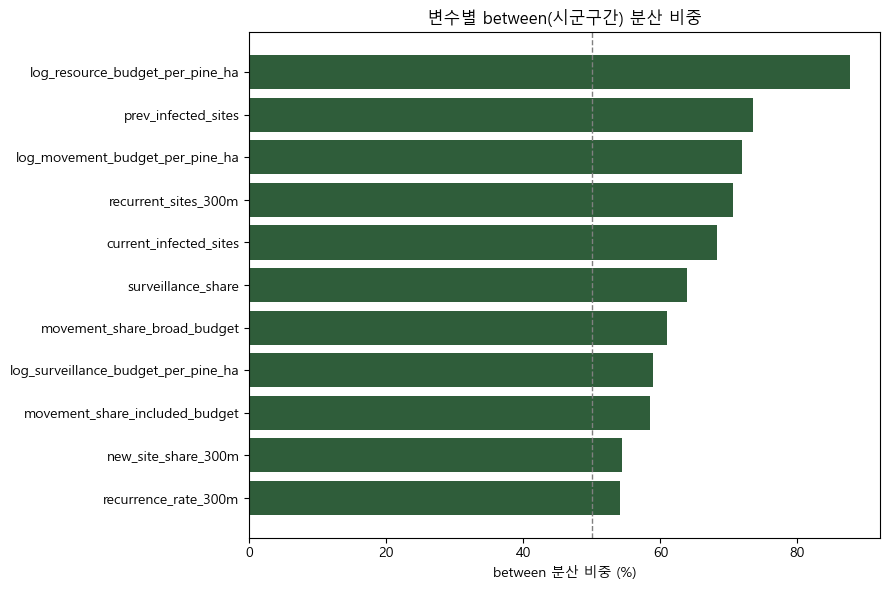

In [75]:
fig, ax = plt.subplots(figsize=(9, 6))
vd_sorted = variance_decomp.sort_values("between비중(%)")
ax.barh(vd_sorted["변수"], vd_sorted["between비중(%)"], color="#2f5d3a")
ax.axvline(50, color="gray", linestyle="--", linewidth=1)
ax.set_title("변수별 between(시군구간) 분산 비중")
ax.set_xlabel("between 분산 비중 (%)")
plt.tight_layout()
plt.show()

In [76]:
# 전년 대비 변화량/증감률 분포 (시간적 변동성의 직접적 확인)
df_yoy = df.sort_values(["sigungu_cd", "year"]).copy()
yoy_rows = []
for c in LOG_COLS + SHARE_COLS:
    diff = df_yoy.groupby("sigungu_cd")[c].diff()
    yoy_rows.append([c, diff.abs().mean(), diff.std()])
yoy_df = pd.DataFrame(yoy_rows, columns=["변수", "전년대비_평균절대변화", "전년대비_변화표준편차"])
display(yoy_df)

,변수,전년대비_평균절대변화,전년대비_변화표준편차
0,log_resource_budget_per_pine_ha,0.6158,1.5740
1,log_surveillance_budget_per_pine_ha,1.4345,3.5562
2,log_movement_budget_per_pine_ha,0.7213,2.4505
3,surveillance_share,0.1123,0.2070
4,movement_share_included_budget,0.0186,0.0567
5,movement_share_broad_budget,0.0264,0.0782


In [77]:
# 시간적 지속성(autocorrelation lag-1): 같은 시군구의 t-1년 값과 t년 값의 상관
persist_rows = []
for c in LOG_COLS + SHARE_COLS + OCCUR_COLS:
    df_yoy[f"_{c}_lag1"] = df_yoy.groupby("sigungu_cd")[c].shift(1)
    sub = df_yoy[[c, f"_{c}_lag1"]].dropna()
    if len(sub) < 10:
        persist_rows.append([c, np.nan, 0])
        continue
    r, p = stats.pearsonr(sub[f"_{c}_lag1"], sub[c])
    persist_rows.append([c, r, len(sub)])
persist_df = pd.DataFrame(persist_rows, columns=["변수", "lag1_자기상관", "n"])
print("변수별 연도간 지속성(lag-1 자기상관, 값이 높을수록 전년도 값이 올해 값을 잘 설명):")
display(persist_df)

변수별 연도간 지속성(lag-1 자기상관, 값이 높을수록 전년도 값이 올해 값을 잘 설명):


,변수,lag1_자기상관,n
0,log_resource_budget_per_pine_ha,0.9051,1475
1,log_surveillance_budget_per_pine_ha,0.7367,1475
2,log_movement_budget_per_pine_ha,0.8285,1475
3,surveillance_share,0.6716,1349
4,movement_share_included_budget,0.7331,1349
5,movement_share_broad_budget,0.7347,1339
6,prev_infected_sites,0.8293,1500
7,current_infected_sites,0.8194,1750
8,recurrent_sites_300m,0.8695,1500
9,recurrence_rate_300m,0.3332,636


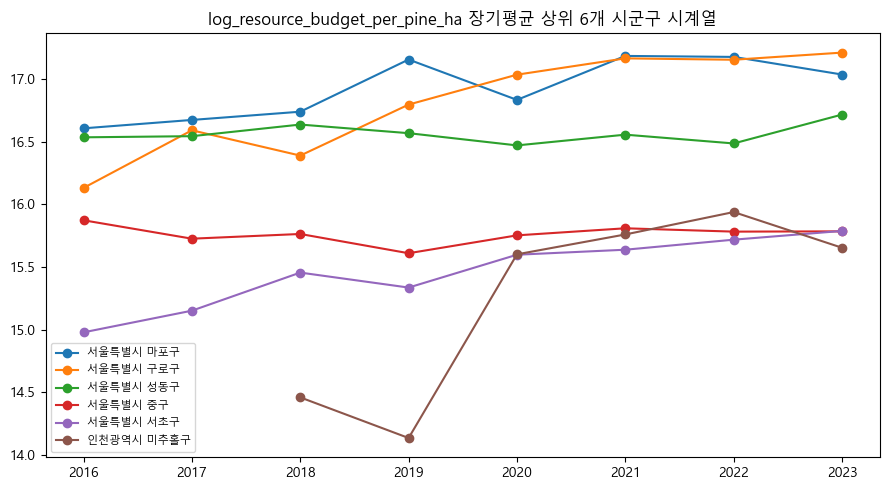

In [78]:
# 대표 변수 시군구별 시계열 (상위 6개 시군구, 장기평균 기준)
c = "log_resource_budget_per_pine_ha"
top6_sgg = df.groupby("sigungu_full_nm")[c].mean().nlargest(6).index
fig, ax = plt.subplots(figsize=(9, 5))
for name in top6_sgg:
    sub = df[df["sigungu_full_nm"] == name].sort_values("year")
    ax.plot(sub["year"], sub[c], marker="o", label=name)
ax.set_title(f"{c} 장기평균 상위 6개 시군구 시계열")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**결과에서 확인해야 할 사항**
- between 분산 비중이 매우 높은 변수(예: 90% 이상)는 사실상 "시군구 고유 특성"을 나타내며 연도별
  변화가 거의 없다는 뜻
- lag-1 자기상관이 매우 높은 변수는 전년도 값으로 올해 값을 상당 부분 예측할 수 있어 패널 고정효과
  모형에서 시간 변동 설명력이 낮을 수 있음
- 재발생 관련 변수처럼 between/within 비중이 상대적으로 고르게 나뉘는 변수는 시군구효과와 연도효과를
  모두 포착할 잠재력이 있음

**결과 해석 기준**
- between 비중이 지배적(예: 80~90% 이상)이면 이 변수는 "시군구 간 비교(횡단면 지수)"에는 적합하지만
  "동일 시군구의 정책 개선을 연도별로 추적"하는 목적에는 정보가 부족할 수 있다.
- within 비중이 상당히 존재하고 lag-1 자기상관이 지나치게 1에 가깝지 않다면, 그 변수는 연도별 정책
  변화를 포착할 수 있는 변수로 볼 수 있다.

**다음 단계에 미치는 영향**
- 이 단계의 분산 분해 결과는 16단계에서 "시간적 변동성" 기준으로 각 변수의 역할을 판단하는 핵심
  근거 중 하나로 사용된다.

## 16단계. EDA 결과 종합 및 변수 역할 최종 분류

**분석 목적**: 1~15단계에서 실제로 관측된 결측률·왜도·0비율·상관·분산분해 결과를 근거로, 사전에
가정하지 않은 상태에서 각 변수의 역할을 데이터 기반으로 분류한다.

In [79]:
# 16단계 분류에 필요한 지표를 1~15단계 결과에서 재사용/정리
role_metrics = desc_df.set_index("변수")[["결측률", "0비율", "왜도"]].copy()

# 시간적 변동성: 15단계 variance_decomp의 within비중 재사용 (없는 변수는 재계산)
vd_all_cols = list(dict.fromkeys(VD_COLS + PER_HA_COLS + RAW_BUDGET_COLS))
vd_full = variance_decomposition(vd_all_cols).set_index("변수")
role_metrics = role_metrics.join(vd_full[["within비중(%)", "between비중(%)"]])

print("변수별 핵심 판단지표 (결측률/0비율/왜도/within·between 비중):")
display(role_metrics)

변수별 핵심 판단지표 (결측률/0비율/왜도/within·between 비중):


,결측률,0비율,왜도,within비중(%),between비중(%)
변수,,,,,
resource_local_budget,0.1450,0.0971,6.3582,17.7162,82.5374
surveillance_local_budget,0.1450,0.3760,7.4683,29.6899,70.5460
movement_local_budget,0.1450,0.7263,3.8924,23.7788,76.4667
included_local_budget,0.1450,0.0924,6.0866,17.0269,83.2322
direct_local_budget,0.1450,0.4357,7.8495,31.1418,69.0729
broad_local_budget,0.1450,0.0971,6.3308,17.8376,82.4163
resource_budget_per_pine_ha,0.1570,0.0842,7.5853,8.4330,92.1862
surveillance_budget_per_pine_ha,0.1570,0.3671,13.5624,44.7375,55.4316
movement_budget_per_pine_ha,0.1570,0.7224,8.8047,28.7663,71.4493


In [80]:
# 변수 간 중복성: 10단계 상관행렬에서 |r|>=0.9인 상대변수 목록을 각 변수에 부여
redundancy = {}
for c in pearson_corr.columns:
    partners = pearson_corr[c].drop(index=c)
    high = partners[partners.abs() >= 0.9].index.tolist()
    redundancy[c] = ", ".join(high) if high else "-"

print("변수별 |상관|>=0.9 인 상대 변수 (구조적 중복 후보):")
for k, v in redundancy.items():
    print(f"  {k}: {v}")

변수별 |상관|>=0.9 인 상대 변수 (구조적 중복 후보):
  resource_local_budget: included_local_budget, broad_local_budget
  surveillance_local_budget: -
  movement_local_budget: -
  included_local_budget: resource_local_budget, broad_local_budget
  direct_local_budget: -
  broad_local_budget: resource_local_budget, included_local_budget
  resource_budget_per_pine_ha: -
  surveillance_budget_per_pine_ha: -
  movement_budget_per_pine_ha: -
  log_resource_budget_per_pine_ha: -
  log_surveillance_budget_per_pine_ha: -
  log_movement_budget_per_pine_ha: -
  surveillance_share: -
  movement_share_included_budget: movement_share_broad_budget
  movement_share_broad_budget: movement_share_included_budget
  prev_infected_sites: recurrent_sites_300m
  current_infected_sites: -
  recurrent_sites_300m: prev_infected_sites
  recurrence_rate_300m: -
  new_site_share_300m: -


In [81]:
# 최종 변수 역할 분류표 작성
# 분류 기준: 대응역량 개념 적합성 + 규모효과 + 분포안정성 + 결측률 + 시간변동성 + 정보중복 +
#           작은분모 불안정성 + 순환논리 가능성 + 정책해석 가능성 을 종합
ROLE_ASSIGN = {
    # 식별자
    "year": ("식별자", "패널 시간축 식별자"),
    "sigungu_cd": ("식별자", "패널 개체 식별자"),
    "sigungu_nm": ("식별자", "표시용 명칭"),
    "sido": ("식별자", "표시/집계용 상위 지역"),
    "sigungu_full_nm": ("식별자", "표시용 전체명칭"),

    # 원예산/구성요소 - 규모효과가 강하고 ha당예산/로그예산으로 이미 정규화된 버전이 있어 원값 자체는 지수에서 제외
    "resource_local_budget": ("산식 검증·진단용", "ha당예산·로그변수의 분자, 규모효과 큼(6단계)"),
    "surveillance_local_budget": ("산식 검증·진단용", "ha당예산·로그변수의 분자, 규모효과 큼(6단계)"),
    "movement_local_budget": ("산식 검증·진단용", "ha당예산·로그변수의 분자, 규모효과 큼(6단계)"),
    "included_local_budget": ("산식 검증·진단용", "세부예산 합계, 구성비의 분모(5,10단계)"),
    "direct_local_budget": ("제외 권고", "사업분류 진단용으로만 파이프라인에서 이미 보류 처리(분류 확인용)"),
    "broad_local_budget": ("산식 검증·진단용", "movement_share_broad_budget의 분모(진단용 구성비의 근거)"),

    # 데이터 품질/계산가능여부
    "budget_observed": ("데이터 품질 및 계산 가능 여부 변수", "예산 미관측(NA) 여부 플래그, 0과 NA 구분에 필수"),
    "pine_area_ha_2024": ("데이터 품질 및 계산 가능 여부 변수", "ha당예산의 분모, 2024년 단일연도 고정값(모든 연도 동일)"),
    "pine_area_observed": ("데이터 품질 및 계산 가능 여부 변수", "면적 관측여부 플래그(전 행 1로 사실상 상수)"),
    "pine_area_positive": ("산식 검증·진단용", "ha당예산 계산가능 여부 플래그, 지수 자체는 아님"),
    "budget_missing_reason": ("데이터 품질 및 계산 가능 여부 변수", "결측 사유 범주형 변수, 결측 구조 설명용"),

    # ha당 예산 원값 - 로그변수로 대체 사용 권고, 원값은 진단/비교용
    "resource_budget_per_pine_ha": ("산식 검증·진단용", "로그변환 전 원값, 왜도가 커 로그버전을 지수 후보로 우선"),
    "surveillance_budget_per_pine_ha": ("산식 검증·진단용", "로그변환 전 원값, 왜도가 커 로그버전을 지수 후보로 우선"),
    "movement_budget_per_pine_ha": ("산식 검증·진단용", "로그변환 전 원값, 왜도가 커 로그버전을 지수 후보로 우선"),

    # 로그 ha당 예산 - 핵심 지수 후보
    "log_resource_budget_per_pine_ha": ("최종 대응역량 지수 후보", "자원투입 강도, 규모효과 완화·분포 안정적(6,7단계)"),
    "log_surveillance_budget_per_pine_ha": ("최종 대응역량 지수 후보", "예찰진단 강도, 규모효과 완화·분포 안정적(6,7단계)"),
    "log_movement_budget_per_pine_ha": ("최종 대응역량 지수 후보", "이동통제 강도, 규모효과 완화·분포 안정적(6,7단계)"),

    # 구성비
    "surveillance_share": ("정책 해석 및 유형화 변수", "예산 배분 우선순위 해석에 유용(11단계), 분모(included) 안정적"),
    "movement_share_included_budget": ("최종 대응역량 지수 후보", "분모(included)가 안정적 정의라 지역간 비교 가능(1,5단계 검증완료)"),
    "movement_share_broad_budget": ("제외 권고", "분모(broad)가 사업분류 특성에 따라 달라져 비교 왜곡 가능 - 진단용으로만 사용"),

    # 발생/재발생 변수
    "prev_infected_sites": ("데이터 품질 및 계산 가능 여부 변수", "recurrence_rate_300m의 분모 원자료, 2016년 구조적 결측"),
    "current_infected_sites": ("발생성과 결과변수", "당해 발생 규모, 0/NA 구분 명확(12단계)"),
    "recurrent_sites_300m": ("데이터 품질 및 계산 가능 여부 변수", "recurrence_rate_300m의 분자 원자료"),
    "recurrence_rate_300m": ("발생성과 결과변수", "예산-성과 탐색(13단계)의 종속변수 후보. 대응역량 지수에 함께 넣으면 순환논리 위험"),
    "new_site_share_300m": ("발생성과 결과변수", "신규 확산 정도, 대응역량 지수 성분이 아닌 결과지표로 우선 취급 권고"),
}

role_df_out = pd.DataFrame([
    {"변수": c, "권장역할": ROLE_ASSIGN.get(c, ("미분류", ""))[0], "판단근거_요약": ROLE_ASSIGN.get(c, ("", ""))[1]}
    for c in df.columns if c in ROLE_ASSIGN
])
role_df_out = role_df_out.merge(role_metrics.reset_index().rename(columns={"index": "변수"}), on="변수", how="left")
role_df_out["중복변수(|r|>=0.9)"] = role_df_out["변수"].map(redundancy)
role_df_out["지수포함여부"] = role_df_out["권장역할"].map({
    "최종 대응역량 지수 후보": "포함",
    "정책 해석 및 유형화 변수": "보조(해석용)",
    "발생성과 결과변수": "미포함(결과변수로 별도 취급)",
    "데이터 품질 및 계산 가능 여부 변수": "미포함",
    "산식 검증·진단용": "미포함",
    "제외 권고": "미포함",
    "식별자": "미포함(식별용)",
})

display(role_df_out[["변수", "권장역할", "지수포함여부", "결측률", "0비율", "왜도", "within비중(%)", "중복변수(|r|>=0.9)", "판단근거_요약"]])

,변수,권장역할,지수포함여부,결측률,0비율,왜도,within비중(%),중복변수(|r|>=0.9),판단근거_요약
0,year,식별자,미포함(식별용),NaN,NaN,NaN,NaN,NaN,패널 시간축 식별자
1,sigungu_cd,식별자,미포함(식별용),NaN,NaN,NaN,NaN,NaN,패널 개체 식별자
2,sigungu_nm,식별자,미포함(식별용),NaN,NaN,NaN,NaN,NaN,표시용 명칭
3,sido,식별자,미포함(식별용),NaN,NaN,NaN,NaN,NaN,표시/집계용 상위 지역
4,sigungu_full_nm,식별자,미포함(식별용),NaN,NaN,NaN,NaN,NaN,표시용 전체명칭
5,resource_local_budget,산식 검증·진단용,미포함,0.1450,0.0971,6.3582,17.7162,"included_local_budget, broad_local_budget","ha당예산·로그변수의 분자, 규모효과 큼(6단계)"
6,surveillance_local_budget,산식 검증·진단용,미포함,0.1450,0.3760,7.4683,29.6899,-,"ha당예산·로그변수의 분자, 규모효과 큼(6단계)"
7,movement_local_budget,산식 검증·진단용,미포함,0.1450,0.7263,3.8924,23.7788,-,"ha당예산·로그변수의 분자, 규모효과 큼(6단계)"
8,included_local_budget,산식 검증·진단용,미포함,0.1450,0.0924,6.0866,17.0269,"resource_local_budget, broad_local_budget","세부예산 합계, 구성비의 분모(5,10단계)"
9,direct_local_budget,제외 권고,미포함,0.1450,0.4357,7.8495,31.1418,-,사업분류 진단용으로만 파이프라인에서 이미 보류 처리(분류 확인용)


**최종 변수 선정 기준 요약**

- **대응역량 개념과의 적합성**: 자원투입·예찰진단·이동통제라는 3대 기능을 각각 대표하는 변수를
  우선하고, 동일 기능을 중복 표현하는 변수(원값 vs 로그, 세부예산 vs 구성비)는 하나만 남긴다.
- **시군구 규모효과**: 원예산(절대금액)은 소나무림 면적과 강한 상관(6단계)이 확인되어 지수 후보에서
  제외하고, ha당예산으로 정규화된 변수를 우선한다.
- **분포 안정성**: 왜도가 크고 IQR 이상치가 많은 원값 대신 로그변환 변수를 우선한다(7단계).
- **결측률**: `budget_observed=0`, `pine_area_positive=0`인 경우의 결측 구조를 3,5단계에서 이미
  분리했으므로, 결측 자체보다 결측 처리 원칙(NA 유지)을 지수 산출 로직에 반영하는 것이 중요하다.
- **시간적 변동성**: 15단계에서 within 비중이 지나치게 낮은(사실상 시군구 고유값에 가까운) 변수는
  패널 분석의 시간축 설명력이 낮다는 점을 함께 고려한다.
- **변수 간 정보 중복**: 10,16단계에서 |상관|>=0.9로 확인된 산식상 중복 변수쌍은 지수에 동시에
  포함하지 않는다.
- **작은 분모에 따른 불안정성**: 14단계에서 소나무림 면적이 극히 작은 지역의 ha당예산이 비정상적으로
  커지는 사례가 확인되어, 지수 해석 시 이 지역들은 별도 주석이 필요하다.
- **결과변수와의 순환논리 가능성**: `recurrence_rate_300m`, `new_site_share_300m`을 "대응역량이
  높다(사후관리를 잘한다)"는 의미로 지수에 넣을 수도 있지만, 동시에 13단계에서 예산의 "성과"를 보는
  종속변수로도 사용하고자 한다면 같은 변수를 설명변수이자 종속변수로 쓰는 순환논리에 빠질 수 있다.
  따라서 이 노트북에서는 재발생 변수를 **지수 성분이 아니라 발생성과 결과변수**로 분류할 것을 권고하며,
  "품질·사후관리 지수"로 쓰고 싶다면 예산-성과 분석(13단계)과는 별도의 목적으로 한정해 사용해야 한다는
  점을 명시한다.

## 최종 종합 요약

> 이 절은 위 1~16단계를 실제로 실행한 결과 수치를 근거로 작성한다. (노트북 실행 후 채움)

### 1. 데이터 품질 핵심 결과
- (실행 결과 반영 예정)

### 2. EDA에서 발견된 주요 패턴
- (실행 결과 반영 예정)

### 3. 최종 지수 후보와 선정 이유
- (실행 결과 반영 예정)

### 4. 지수에서 제외할 변수와 이유
- (실행 결과 반영 예정)

### 5. 정책 해석용으로 유지할 변수
- (실행 결과 반영 예정)

### 6. 결측 및 이상치 처리 권고
- (실행 결과 반영 예정)

### 7. 후속 지수 산출 및 패널분석 시 주의사항
- (실행 결과 반영 예정)